# Keystroke Dynamics Authentication: A Comparative Analysis

## Thesis Analysis Notebook

**Author:** M Nouh Rahmani
**ID:** 201805350
**Date:** 2025  
**Institution:** University of Leeds

---

### Abstract

This notebook presents a comprehensive analysis of keystroke dynamics-based user authentication across Four benchmark datasets: **CMU**, **GREYC**, **Alto** and **IKDD**. We implement and compare multiple machine learning classifiers including Support Vector Machines (SVM), Random Forest, Gradient Boosting, and Logistic Regression using biometric authentication metrics such as Equal Error Rate (EER), False Acceptance Rate (FAR), False Rejection Rate (FRR), and Area Under the ROC Curve (AUC).


---

## 1. Environment Setup and Imports

This section imports all necessary libraries for data manipulation, machine learning, and visualization. Will add more where we see neccessary

In [1]:
# SECTION 1: LIBRARY IMPORTS

# This cell is where we import all the required libraries, which I think are needed:
# - Data manipulation: pandas, numpy
# - Database access: sqlite3
# - Machine learning: sklearn
# - Visualization: matplotlib, seaborn
# - File handling: os, glob, re
# =============================================================================


# Data Manipulation Libraries

import pandas as pd                    # DataFrame operations and data analysis
import numpy as np                     # Numerical computing and array operations
import sqlite3                         # SQLite database connectivity


# Machine Learning Libraries
# -----------------------------------------------------------------------------
from sklearn.model_selection import train_test_split    # Train/test splitting
from sklearn.preprocessing import StandardScaler        # Feature standardization
from sklearn.pipeline import Pipeline                   # ML pipeline construction

# Classification Models
from sklearn.svm import SVC                            # Support Vector Machine
from sklearn.ensemble import RandomForestClassifier    # Random Forest
from sklearn.ensemble import GradientBoostingClassifier # Gradient Boosting
from sklearn.linear_model import LogisticRegression    # Logistic Regression

# Evaluation Metrics
from sklearn.metrics import (
    roc_curve,           # ROC curve computation
    auc,                 # Area Under Curve
    precision_score,     # Precision calculation
    recall_score,        # Recall/Sensitivity calculation
    confusion_matrix,    # Confusion matrix generation
    classification_report # Detailed classification metrics
)


# Visualization Libraries
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt        # Core plotting library
import seaborn as sns                  # Statistical data visualization


# File and System Libraries
# -----------------------------------------------------------------------------
import os                              # Operating system interfaces
from glob import glob                  # File pattern matching
import re                              # Regular expressions
import warnings                        # Warning control


warnings.filterwarnings('ignore')

# Set pandas display options for better data visibility
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Auto-adjust display width
pd.set_option('display.max_rows', 100)        # Show up to 100 rows

# Set matplotlib style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')       # Clean, professional style
plt.rcParams['figure.figsize'] = (12, 8)      # Default figure size
plt.rcParams['font.size'] = 12                # Default font size
plt.rcParams['axes.labelsize'] = 14           # Axis label size
plt.rcParams['axes.titlesize'] = 16           # Title size
plt.rcParams['legend.fontsize'] = 11          # Legend font size
plt.rcParams['figure.dpi'] = 100              # Figure resolution

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


---

## 2. Dataset Loading and Exploration

### 2.1 CMU Keystroke Dataset

The **CMU Keystroke Dynamics Dataset** is a widely-used benchmark containing keystroke timings from 51 subjects typing the password ".tie5Roanl". Each subject provided 400 samples across 8 sessions.

**Features include:**
- **H (Hold time):** Duration a key is pressed
- **DD (Down-Down time):** Time between consecutive key presses
- **UD (Up-Down time):** Time between key release and next key press

In [199]:

# SECTION 2.1: CMU DATASET LOADING

# The CMU dataset contains keystroke dynamics for the password ".tie5Roanl"
# Features: Hold times (H), Down-Down times (DD), Up-Down times (UD)
# Reference: Killourhy & Maxion (2009)


# Loading the CMU dataset from CSV file

cmu = pd.read_csv("CMU_DATASET.csv")


# Dataset Overview


print("CMU KEYSTROKE DYNAMICS DATASET")
print("=" * 70)
print(f"\nDataset Shape: {cmu.shape[0]:,} samples × {cmu.shape[1]} features")
print(f"Memory Usage: {cmu.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows for visual inspection
print("\n--- Sample Data (First 5 Rows) ---")
display(cmu.head())

CMU KEYSTROKE DYNAMICS DATASET

Dataset Shape: 20,400 samples × 34 features
Memory Usage: 6.32 MB

--- Sample Data (First 5 Rows) ---


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,DD.i.e,UD.i.e,H.e,DD.e.five,UD.e.five,H.five,DD.five.Shift.r,UD.five.Shift.r,H.Shift.r,DD.Shift.r.o,UD.Shift.r.o,H.o,DD.o.a,UD.o.a,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,0.2212,0.1043,0.1417,1.1885,1.0468,0.1146,1.6055,1.4909,0.1067,0.7590,0.6523,0.1016,0.2136,0.1120,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,0.1357,0.0449,0.0829,1.1970,1.1141,0.0689,0.7822,0.7133,0.1570,0.7877,0.6307,0.1066,0.1684,0.0618,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,0.1542,0.0721,0.0808,1.0408,0.9600,0.0892,0.6203,0.5311,0.1454,0.7195,0.5741,0.1365,0.2931,0.1566,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,0.2038,0.0998,0.0900,1.0556,0.9656,0.0913,1.2564,1.1651,0.1454,0.7550,0.6096,0.0956,0.1530,0.0574,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,0.1589,0.0686,0.0805,0.8629,0.7824,0.0742,0.8955,0.8213,0.1243,0.7632,0.6389,0.0430,0.1975,0.1545,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


In [200]:

# SECTION 2.1.1: CMU DATASET EXPLORATION

# This cell provides a description and  analysis of the CMU dataset
# =============================================================================

# Get unique subjects
subjects = cmu['subject'].unique()
n_subjects = len(subjects)

print(f"\n--- Subject Information ---")
print(f"Number of unique subjects: {n_subjects}")
print(f"Subjects: {subjects[:10]}... (showing first 10)")

# Samples per subject
samples_per_subject = cmu.groupby('subject').size()
print(f"\nSamples per subject:")
print(f"  - Mean: {samples_per_subject.mean():.1f}")
print(f"  - Min: {samples_per_subject.min()}")
print(f"  - Max: {samples_per_subject.max()}")

# Statistical summary
print("\n--- Statistical Summary ---")
display(cmu.describe())


--- Subject Information ---
Number of unique subjects: 51
Subjects: ['s002' 's003' 's004' 's005' 's007' 's008' 's010' 's011' 's012' 's013']... (showing first 10)

Samples per subject:
  - Mean: 400.0
  - Min: 400
  - Max: 400

--- Statistical Summary ---


,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,DD.i.e,UD.i.e,H.e,DD.e.five,UD.e.five,H.five,DD.five.Shift.r,UD.five.Shift.r,H.Shift.r,DD.Shift.r.o,UD.Shift.r.o,H.o,DD.o.a,UD.o.a,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
count,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,4.500000,25.500000,0.093379,0.264148,0.170769,0.085727,0.169085,0.083358,0.081565,0.159372,0.077806,0.089138,0.377434,0.288295,0.076904,0.438887,0.361983,0.095937,0.250921,0.154984,0.088354,0.156931,0.068577,0.106259,0.150670,0.044411,0.089899,0.202630,0.112731,0.095589,0.321847,0.226259,0.088306
std,2.291344,14.431223,0.029626,0.220534,0.226836,0.027424,0.123546,0.125755,0.026887,0.226928,0.228512,0.030635,0.265342,0.266695,0.021746,0.260343,0.260886,0.033900,0.174533,0.181619,0.026427,0.106557,0.108509,0.038828,0.107422,0.105197,0.030738,0.150191,0.159571,0.028348,0.225389,0.230759,0.027452
min,1.000000,1.000000,0.001400,0.018700,-0.235800,0.009300,0.001100,-0.162100,0.003200,0.001400,-0.160000,0.002100,0.001300,-0.150500,0.001400,0.169400,0.085600,0.001400,0.049400,-0.086500,0.006900,0.001200,-0.228700,0.004000,0.001100,-0.235500,0.003700,0.001300,-0.175800,0.003700,0.008300,-0.124500,0.002900
25%,2.750000,13.000000,0.074400,0.146900,0.049800,0.066000,0.113600,0.027200,0.062000,0.089300,0.007400,0.068600,0.216600,0.133200,0.061000,0.307900,0.229675,0.070200,0.156500,0.054700,0.071500,0.106400,0.017000,0.082100,0.096100,-0.009000,0.067300,0.127600,0.023500,0.077400,0.210000,0.114100,0.069900
50%,4.500000,25.500000,0.089500,0.205950,0.108700,0.081000,0.140400,0.057800,0.077100,0.120900,0.041200,0.083400,0.289000,0.200400,0.074200,0.377500,0.302000,0.093500,0.201350,0.102200,0.086300,0.131600,0.044400,0.101900,0.125000,0.022700,0.085300,0.172500,0.095500,0.093700,0.263000,0.160300,0.085500
75%,6.250000,38.000000,0.107900,0.306450,0.212400,0.099800,0.183900,0.096400,0.096900,0.173100,0.093400,0.102700,0.456850,0.369400,0.090600,0.486025,0.408900,0.116700,0.283425,0.191000,0.101900,0.167600,0.080300,0.122300,0.174600,0.068900,0.107900,0.228800,0.145700,0.111100,0.350200,0.255100,0.103700
max,8.000000,50.000000,0.376100,12.506100,12.451700,0.241100,4.919700,4.799900,0.331200,25.987300,25.915800,0.325400,4.961800,4.882700,0.198900,8.370200,8.290800,0.281700,4.152300,4.012000,0.687200,2.856700,2.815200,2.035300,3.327800,2.524200,0.357700,4.025200,3.978200,0.340700,5.883600,5.836400,0.265100


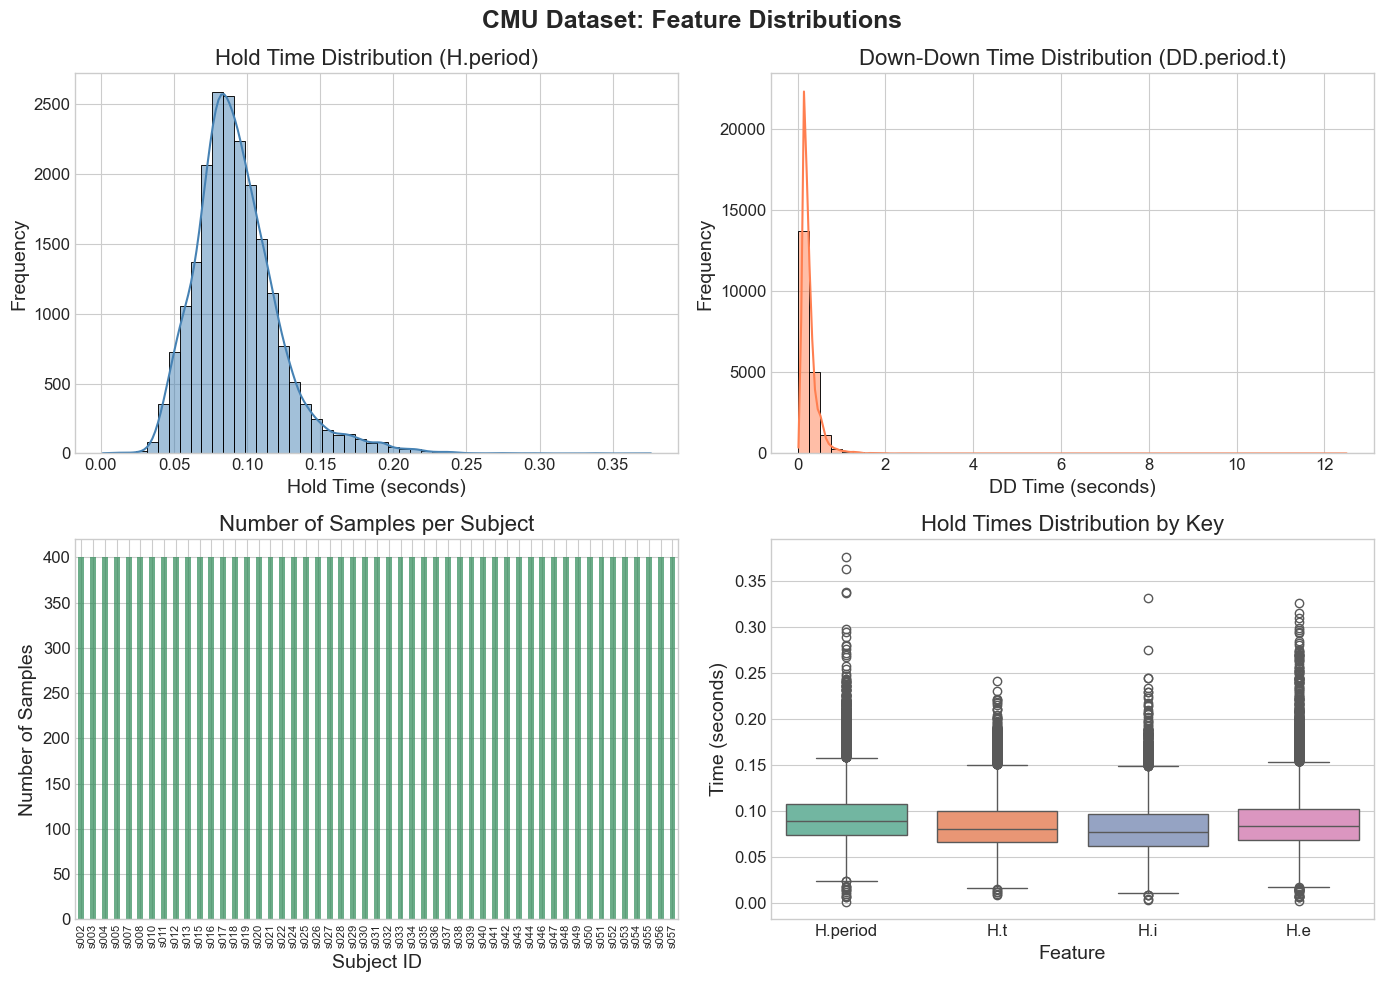


✓ Figure saved as 'cmu_exploration.png'


In [201]:

# SECTION 2.1.2: CMU DATA VISUALIZATION

# Visualizing the distribution of keystroke features across users


# Defining feature columns (excluding metadata columns)
feature_cols_cmu = [c for c in cmu.columns if c not in ['subject', 'sessionIndex', 'rep']]

# Creating figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CMU Dataset: Feature Distributions', fontsize=18, fontweight='bold')

# Plot 1: Distribution of Hold Times (H.period - first key)
ax1 = axes[0, 0]
sns.histplot(data=cmu, x='H.period', bins=50, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Hold Time Distribution (H.period)')
ax1.set_xlabel('Hold Time (seconds)')
ax1.set_ylabel('Frequency')

# Plot 2: Distribution of Down-Down Times
ax2 = axes[0, 1]
sns.histplot(data=cmu, x='DD.period.t', bins=50, kde=True, ax=ax2, color='coral')
ax2.set_title('Down-Down Time Distribution (DD.period.t)')
ax2.set_xlabel('DD Time (seconds)')
ax2.set_ylabel('Frequency')

# Plot 3: Samples per Subject
ax3 = axes[1, 0]
samples_per_subject.plot(kind='bar', ax=ax3, color='seagreen', alpha=0.7)
ax3.set_title('Number of Samples per Subject')
ax3.set_xlabel('Subject ID')
ax3.set_ylabel('Number of Samples')
ax3.tick_params(axis='x', rotation=90, labelsize=8)

# Plot 4: Boxplot of selected features by session
ax4 = axes[1, 1]
cmu_melted = cmu.melt(id_vars=['subject', 'sessionIndex'], 
                       value_vars=['H.period', 'H.t', 'H.i', 'H.e'],
                       var_name='Feature', value_name='Time')
sns.boxplot(data=cmu_melted, x='Feature', y='Time', ax=ax4, palette='Set2')
ax4.set_title('Hold Times Distribution by Key')
ax4.set_ylabel('Time (seconds)')

plt.tight_layout()
plt.savefig('cmu_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved as 'cmu_exploration.png'")

### 2.2 GREYC Dataset

The **GREYC Keystroke Dataset** contains keystroke dynamics data stored in an SQLite database. This dataset includes timing features extracted from free-text typing sessions.

In [203]:
# SECTION 2.2: GREYC DATASET LOADING
# The GREYC dataset is stored in SQLite format and requires database queries
# Features are extracted from typing sessions and stored as arrays


# Connecting to the GREYC SQLite database

greyc_db_path = "greyc.db"
greyc_conn = sqlite3.connect(greyc_db_path)

# Query to extract user features from the database
# This joins session data with computed features
greyc_query = """
SELECT 
    user_id,
    session_id,
    features
FROM keystroke_features
"""

try:
    # Loading data from database
    greyc = pd.read_sql_query(greyc_query, greyc_conn)
    
    
    
    if greyc['features'].dtype == object:
        greyc['features'] = greyc['features'].apply(
            lambda x: np.fromstring(x.strip('[]'), sep=',') if isinstance(x, str) else x
        )
    
    print("=" * 70)
    print("GREYC KEYSTROKE DYNAMICS DATASET")
    print("=" * 70)
    print(f"\nDataset Shape: {greyc.shape[0]:,} samples")
    print(f"Number of unique users: {greyc['user_id'].nunique()}")
    
    display(greyc.head())
    
except Exception as e:
    print(f"Warning: Could not load GREYC database: {e}")
    print("Attempting to load from CSV backup...")
    greyc = pd.read_csv("greyc_joined.csv")
    display(greyc.head())

finally:
    greyc_conn.close()

SELECT 
    user_id,
    session_id,
    features
FROM keystroke_features
': no such table: keystroke_features
Attempting to load from CSV backup...


,typing_id,user_id,keyboard_number,typing_date,success,password,data_id,data_date,time_to_type,ppTime,prTime,rpTime,rrTime,vector,rawPress,rawRelease
0,2,1,1,2009-03-17 15:58:56,1,laboratoire greyc,1,2009-03-17 15:58:56,24835712,1301872 2403456 1001440 2002880 701008 160230...,2203168 3705328 1802592 3004320 2103024 27038...,200288 1502160 -300432 1201728 -300432 200288...,1101584 2804032 500720 2203168 1101584 130187...,1301872 2403456 1001440 2002880 701008 160230...,76 633729059335818496\n65 633729059337120368\n...,76 633729059336920080\n65 633729059338021664\n...
1,3,1,1,2009-03-17 15:59:00,1,laboratoire greyc,2,2009-03-17 15:59:00,20629664,1301872 2403456 1502160 1301872 801152 150216...,2503600 3705328 2303312 2303312 2002880 25036...,300432 1201728 200288 500720 -200288 300432 -...,1502160 2503600 1001440 1502160 1001440 13018...,1301872 2403456 1502160 1301872 801152 150216...,76 633729059382285312\n65 633729059383587184\n...,76 633729059383286752\n65 633729059384788912\n...
2,4,1,1,2009-03-17 15:59:14,1,laboratoire greyc,3,2009-03-17 15:59:14,22131824,1001440 2403456 1402016 1702448 801152 160230...,2002880 3805472 2103024 2703888 2403456 26037...,0 1402016 0 1001440 -200288 0 -300432 -600864...,1001440 2804032 701008 2002880 1402016 100144...,1001440 2403456 1402016 1702448 801152 160230...,76 633729059522286624\n65 633729059523288064\n...,76 633729059523288064\n65 633729059524289504\n...
3,9,1,1,2009-03-17 15:59:38,1,laboratoire greyc,4,2009-03-17 15:59:37,32446656,901296 2303312 1702448 1902736 1802592 240345...,1702448 3404896 2303312 3004320 3004320 39056...,0 1502160 600864 1301872 701008 1201728 61087...,801152 2603744 1201728 2403456 1902736 270388...,901296 2303312 1702448 1902736 1802592 240345...,76 633729059745507600\n65 633729059746408896\n...,76 633729059746408896\n65 633729059747210048\n...
4,13,1,1,2009-03-17 15:59:59,1,laboratoire greyc,5,2009-03-17 15:59:59,25737008,801152 2503600 1301872 1802592 1101584 120172...,2103024 3805472 1902736 2904176 2303312 26037...,-300432 1201728 0 1201728 0 0 0 -400576 0 -13...,1001440 2503600 600864 2303312 1201728 140201...,801152 2503600 1301872 1802592 1101584 120172...,76 633729059963420944\n65 633729059964222096\n...,76 633729059964522528\n65 633729059965523968\n...


### 2.3 IKDD Dataset

The **IKDD (Indian Keystroke Dynamics Dataset)** contains continuous typing data from multiple users. Unlike fixed-text datasets like CMU, IKDD captures free-text typing patterns.

In [205]:

# SECTION 4.1: LOAD IKDD RAW FILES

# IKDD data is stored as text files, one per session
# File naming convention: any_ks&dl_userXXX_(Y).txt


# Define root directory for IKDD data
ikdd_root = "IKDD"

# Finding all text files since they are disparced
files = glob(os.path.join(ikdd_root, "**", "*.txt"), recursive=True)

def get_user_id(filepath):
    """
    Extracting user ID from IKDD filename.
    
    Parameters:
    -----------
    filepath : str
        Path to the IKDD text file
        
    Returns:
    --------
    str : User ID (e.g., 'user001') or 'unknown'
    """
    filename = os.path.basename(filepath).lower()
    match = re.search(r"(user\d+)", filename)
    return match.group(1) if match else "unknown"

# Creating DataFrame with file info
ikdd_raw = pd.DataFrame({
    "path": files,
    "user_id": [get_user_id(f) for f in files],
})

# Loading raw text content
ikdd_raw["text"] = ikdd_raw["path"].apply(
    lambda p: open(p, "r", encoding="utf-8", errors="ignore").read()
)

print("=" * 70)
print("IKDD KEYSTROKE DYNAMICS DATASET")
print("=" * 70)
print(f"Number of files: {len(files)}")
print(f"Unique users: {ikdd_raw['user_id'].nunique()}")

display(ikdd_raw.head(20))

IKDD KEYSTROKE DYNAMICS DATASET
Number of files: 533
Unique users: 164


,path,user_id,text
0,IKDD\any_ks&dl_user001_(1).txt,user001,"user001_(1),Male,18-25,Right-Handed,English,IS..."
1,IKDD\any_ks&dl_user002_(1).txt,user002,"user002_(1),Female,18-25,Right-Handed,English,..."
2,IKDD\any_ks&dl_user002_(2).txt,user002,"user002_(2),Female,18-25,Right-Handed,English,..."
3,IKDD\any_ks&dl_user002_(3).txt,user002,"user002_(3),Female,18-25,Right-Handed,English,..."
4,IKDD\any_ks&dl_user002_(4).txt,user002,"user002_(4),Female,18-25,Right-Handed,English,..."
5,IKDD\any_ks&dl_user002_(5).txt,user002,"user002_(5),Female,18-25,Right-Handed,English,..."
6,IKDD\any_ks&dl_user003_(1).txt,user003,"user003_(1),Male,26-35,Left-Handed,Greek,ISCED..."
7,IKDD\any_ks&dl_user003_(2).txt,user003,"user003_(2),Male,26-35,Left-Handed,Greek,ISCED..."
8,IKDD\any_ks&dl_user003_(3).txt,user003,"user003_(3),Male,26-35,Left-Handed,Greek,ISCED..."
9,IKDD\any_ks&dl_user003_(4).txt,user003,"user003_(4),Male,26-35,Left-Handed,Greek,ISCED..."


In [206]:

# SECTION 4.2: PARSE IKDD FILE FORMAT

# IKDD files have a specific format:
# - Line 0: Metadata (user info, demographics)
# - Lines 1+: Feature data in format "X-Y,val1,val2,..."
#   where X-Y is a digraph (key pair) and values are timing measurements


# Spliting text into lines for inspection
ikdd_raw["lines"] = ikdd_raw["text"].str.split("\n")

# Looking at sample data structure
print("Sample IKDD file structure (first 10 lines):")
print(ikdd_raw.loc[0, "lines"][:10])

Sample IKDD file structure (first 10 lines):
['user001_(1),Male,18-25,Right-Handed,English,ISCED-6,Desktop,4-6', '8-0,61,32,58,61,62,80,91,53,30,60,80,50,70,66,147,31,46,57,40,78,113,80,121,66,61,51,60,43,61,36,91,61,60,45,86,58,91,62,34,52,82,50,66,60,36,40,80,51,41,80,40,81,80,142,40,47,50,70,92,80,34,47,83,70,34,46,61,29,39,35,80,72,183,101,56,60,50,30,30,41,30,64,30,44,51,51,47,60,50,50,50,60,40,71,52,51,68,51,31,81,83,79,44,78,29,60,60,62,58,114,83,46,63,29,61,82,64,57,64,64,67,47,73,63,55,72,49,51,59,78,41,66,80,40,54,40,27,61,40,81,110,50,30,60,72,60,55,58,50,51,58,44,75,80,71,60,109,111,65,61,68,51,30,41,46,61,43,60,63,61,61,52,52,57,70,51,31,65,52,52,31,51,31,61,27,31,63,46,48,41,69,75,88,129,64,29,63,70,78,57,49,84,80,32,51,67,64,95,50,52,40,82,64,31,51,80,58,52,30,42,49,51,144,51,30,50,31,78,41,31,41,82,46,63,52,35,68,52,50,67,59,52,50,61,59,81,74,72,30,40,82,108,61,52,30,61,37,51,39,78,27,28,51,42,80,66,53,61,64,41,41,35,71,42,64,42,75,41,62,96,49,56,52,112,62,79,62,67,35,3

In [207]:

# SECTION 4.3: IKDD FEATURE EXTRACTION FUNCTIONS

# These functions parse IKDD text files and extract timing features
# The format is: "digraph,timing1,timing2,..." where digraph is "keyA-keyB"


def parse_ikdd_text_to_dict(text):
    """
    Parsing IKDD text blob into a dictionary of digraph -> timing values.
    
    The IKDD format has:
    - Line 0: User metadata (skipped)
    - Lines 1+: "X-Y,val1,val2,..." format
    
    Parameters:
    -----------
    text : str
        Raw text content from IKDD file
        
    Returns:
    --------
    dict : should map Map from digraph (e.g., "8-0") to list of timing values
    """
    feats = {}
    lines = text.split("\n")

    for i, line in enumerate(lines):
        line = line.strip()
        if not line:
            continue

        # Skip metadata line (line 0)
        if i == 0:
            continue

        # Skip lines without comma (no data)
        if "," not in line:
            continue

        # Split into digraph identifier and values
        left, *vals = [x.strip() for x in line.split(",")]
        
        # Normalize dash characters
        left = left.replace("–", "-").replace("—", "-")

        # Validate digraph format (e.g., "8-0", "13-0")
        if not re.match(r"^\d+\-\d+$", left):
            continue

        # Parse numeric values
        numbers = []
        for v in vals:
            if v == "":
                continue
            try:
                numbers.append(float(v))
            except:
                pass

        if numbers:
            feats[left] = numbers

    return feats


def summarize(vals):
    """
    Computing summary statistics for a list of timing values.
    
    Parameters:
    -----------
    vals : list
        List of timing values
        
    Returns:
    --------
    dict : Summary statistics (mean, std, median, count)
    """
    vals = np.asarray(vals, dtype=float)
    return {
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "median": float(np.median(vals)),
        "count": float(len(vals))
    }


def build_ikdd_from_ikdd_raw(ikdd_raw, top_k_features=300):
    """
    Building feature matrix from raw IKDD data.
    
    This function:
    1. Parses all text files to extract digraph timings
    2. Selects the most common digraphs as features
    3. Computes summary statistics for each digraph
    4. Creates a fixed-size feature matrix
    
    Parameters:
    -----------
    ikdd_raw : pd.DataFrame
        DataFrame with 'text' and 'user_id' columns
    top_k_features : int
        Number of most common digraphs to use as features (default: 300)
        
    Returns:
    --------
    tuple : (X_ikdd, y_ikdd, ikdd_feat_df, ikdd_meta_df, top_feats)
        - X_ikdd: Feature matrix (n_samples, n_features*4)
        - y_ikdd: User labels
        - ikdd_feat_df: Feature DataFrame
        - ikdd_meta_df: Metadata DataFrame
        - top_feats: List of selected feature names
    """
    # Parsing all rows and counting feature frequency
    parsed_dicts = []
    freq = Counter()

    for idx, row in ikdd_raw.iterrows():
        d = parse_ikdd_text_to_dict(row["text"])
        parsed_dicts.append(d)
        freq.update(d.keys())

    # Selecting the most common digraphs as features just to avoid huge dimensionality 
    # This keeps the feature matrix manageable while capturing important patterns
    top_feats = [f for f, _ in freq.most_common(top_k_features)]

    # Build feature rows
    rows = []
    for d in parsed_dicts:
        feat_row = {}
        for feat in top_feats:
            vals = d.get(feat)
            if vals is None:
                # Missing digraph - fill with NaN (will be imputed later)
                feat_row[f"{feat}_mean"] = np.nan
                feat_row[f"{feat}_std"] = np.nan
                feat_row[f"{feat}_median"] = np.nan
                feat_row[f"{feat}_count"] = 0.0
            else:
                # Compute summary statistics
                s = summarize(vals)
                feat_row[f"{feat}_mean"] = s["mean"]
                feat_row[f"{feat}_std"] = s["std"]
                feat_row[f"{feat}_median"] = s["median"]
                feat_row[f"{feat}_count"] = s["count"]
        rows.append(feat_row)

    ikdd_feat_df = pd.DataFrame(rows)

    # Impute missing values with median (robust to outliers)
    ikdd_feat_df = ikdd_feat_df.fillna(ikdd_feat_df.median(numeric_only=True))

    # Convert to numpy arrays
    X_ikdd = ikdd_feat_df.to_numpy(dtype=float)
    y_ikdd = ikdd_raw["user_id"].to_numpy()

    ikdd_meta_df = ikdd_raw[["path", "user_id"]].copy()

    return X_ikdd, y_ikdd, ikdd_feat_df, ikdd_meta_df, top_feats

print("✓ IKDD feature extraction functions defined")

✓ IKDD feature extraction functions defined


In [208]:
### # SECTION 4.4: BUILD IKDD FEATURE MATRIX

from collections import Counter

# Extracting features from all IKDD files and create the feature matrix


# Building feature matrix using top 300 most common digraphs
X_ikdd, y_ikdd, ikdd_feat_df, ikdd_meta_df, ikdd_top_feats = build_ikdd_from_ikdd_raw(
    ikdd_raw,
    top_k_features=300 
)

# Display of results
print(f"IKDD Feature Matrix Shape: {X_ikdd.shape}")
print(f"Unique Users: {len(np.unique(y_ikdd))}")

# Show sample distribution
counts = pd.Series(y_ikdd).value_counts()
print(f"Samples per User (min/mean/max): {counts.min()}, {round(counts.mean(), 2)}, {counts.max()}")

print("\nTop 10 users by sample count:")
display(counts.head(10))

IKDD Feature Matrix Shape: (533, 1200)
Unique Users: 164
Samples per User (min/mean/max): 1, 3.25, 9

Top 10 users by sample count:


user017    9
user052    8
user120    6
user158    6
user044    6
user144    5
user154    5
user061    5
user050    5
user124    5
Name: count, dtype: int64

In [209]:
ikdd_feat_df.head()

,65-0_mean,65-0_std,65-0_median,65-0_count,68-0_mean,68-0_std,68-0_median,68-0_count,69-0_mean,69-0_std,69-0_median,69-0_count,83-0_mean,83-0_std,83-0_median,83-0_count,70-0_mean,70-0_std,70-0_median,70-0_count,72-0_mean,72-0_std,72-0_median,72-0_count,82-0_mean,82-0_std,82-0_median,82-0_count,32-0_mean,32-0_std,32-0_median,32-0_count,75-0_mean,75-0_std,75-0_median,75-0_count,73-0_mean,73-0_std,73-0_median,73-0_count,84-0_mean,84-0_std,84-0_median,84-0_count,65-83_mean,65-83_std,65-83_median,65-83_count,76-0_mean,76-0_std,76-0_median,76-0_count,71-0_mean,71-0_std,71-0_median,71-0_count,77-0_mean,77-0_std,77-0_median,77-0_count,79-0_mean,79-0_std,79-0_median,79-0_count,78-0_mean,78-0_std,78-0_median,78-0_count,86-0_mean,86-0_std,86-0_median,86-0_count,87-0_mean,87-0_std,87-0_median,87-0_count,67-0_mean,67-0_std,67-0_median,67-0_count,80-0_mean,80-0_std,80-0_median,80-0_count,85-0_mean,85-0_std,85-0_median,85-0_count,66-0_mean,66-0_std,66-0_median,66-0_count,69-82_mean,69-82_std,69-82_median,69-82_count,89-0_mean,89-0_std,89-0_median,89-0_count,65-82_mean,65-82_std,65-82_median,65-82_count,65-32_mean,65-32_std,65-32_median,65-32_count,83-69_mean,83-69_std,83-69_median,83-69_count,65-78_mean,65-78_std,65-78_median,65-78_count,69-83_mean,69-83_std,69-83_median,69-83_count,82-65_mean,82-65_std,82-65_median,82-65_count,82-69_mean,82-69_std,82-69_median,82-69_count,68-69_mean,68-69_std,68-69_median,68-69_count,65-76_mean,65-76_std,65-76_median,65-76_count,69-32_mean,69-32_std,69-32_median,69-32_count,32-65_mean,32-65_std,32-65_median,32-65_count,82-73_mean,82-73_std,82-73_median,82-73_count,84-69_mean,84-69_std,84-69_median,84-69_count,79-82_mean,79-82_std,79-82_median,79-82_count,32-83_mean,32-83_std,32-83_median,32-83_count,32-68_mean,32-68_std,32-68_median,32-68_count,77-65_mean,77-65_std,77-65_median,77-65_count,76-65_mean,76-65_std,76-65_median,76-65_count,65-84_mean,65-84_std,65-84_median,65-84_count,32-69_mean,32-69_std,32-69_median,32-69_count,84-73_mean,84-73_std,84-73_median,84-73_count,84-79_mean,84-79_std,84-79_median,84-79_count,74-0_mean,74-0_std,74-0_median,74-0_count,82-79_mean,82-79_std,82-79_median,82-79_count,83-65_mean,83-65_std,83-65_median,83-65_count,90-0_mean,90-0_std,90-0_median,90-0_count,32-84_mean,32-84_std,32-84_median,32-84_count,68-73_mean,68-73_std,68-73_median,68-73_count,76-69_mean,76-69_std,76-69_median,76-69_count,79-78_mean,79-78_std,79-78_median,79-78_count,83-84_mean,83-84_std,83-84_median,83-84_count,32-77_mean,32-77_std,32-77_median,32-77_count,73-78_mean,73-78_std,73-78_median,73-78_count,69-78_mean,69-78_std,69-78_median,69-78_count,73-83_mean,73-83_std,73-83_median,73-83_count,78-32_mean,78-32_std,78-32_median,78-32_count,84-65_mean,84-65_std,84-65_median,84-65_count,88-0_mean,88-0_std,88-0_median,88-0_count,190-0_mean,190-0_std,190-0_median,190-0_count,32-80_mean,32-80_std,32-80_median,32-80_count,77-69_mean,77-69_std,77-69_median,77-69_count,78-65_mean,78-65_std,78-65_median,78-65_count,69-84_mean,69-84_std,69-84_median,69-84_count,80-69_mean,80-69_std,80-69_median,80-69_count,65-73_mean,65-73_std,65-73_median,65-73_count,73-84_mean,73-84_std,73-84_median,73-84_count,79-76_mean,79-76_std,79-76_median,79-76_count,79-32_mean,79-32_std,79-32_median,79-32_count,76-79_mean,76-79_std,76-79_median,76-79_count,65-68_mean,65-68_std,65-68_median,65-68_count,69-76_mean,69-76_std,69-76_median,69-76_count,83-73_mean,83-73_std,83-73_median,83-73_count,80-79_mean,80-79_std,80-79_median,80-79_count,79-83_mean,79-83_std,79-83_median,79-83_count,160-0_mean,160-0_std,160-0_median,160-0_count,73-79_mean,73-79_std,73-79_median,73-79_count,78-84_mean,78-84_std,78-84_median,78-84_count,80-65_mean,80-65_std,80-65_median,80-65_count,73-32_mean,73-32_std,73-32_median,73-32_count,65-77_mean,65-77_std,65-77_median,65-77_count,76-73_mean,76-73_std,76-73_median,76-73_count,84-82_mean,84-82_std,84-82_median,84-82_count,32-78_mean,32-78_std,32-78_median,32-78_count,78-69_mean,78-69_std,78-69_median,78-69_count,79-77_mea

In [210]:
# How many unique digraphs exist, and how much coverage do top_k digraphs give?

from collections import Counter

def ikdd_digraph_stats(ikdd_raw, top_k=300):
    freq = Counter()
    total_occurrences = 0
    total_nonempty_samples = 0

    for _, row in ikdd_raw.iterrows():
        d = parse_ikdd_text_to_dict(row["text"])
        if not d:
            continue
        total_nonempty_samples += 1

        for k, vals in d.items():
            # occurrences = how many timing values we have for that digraph in this sample
            occ = len(vals)
            freq[k] += occ
            total_occurrences += occ

    unique_digraphs = len(freq)
    top = freq.most_common(top_k)
    top_occ = sum(v for _, v in top)
    coverage = (top_occ / total_occurrences) if total_occurrences > 0 else 0.0

    # how many samples contain at least one of the top_k digraphs
    top_set = set(k for k, _ in top)
    samples_with_top = 0
    for _, row in ikdd_raw.iterrows():
        d = parse_ikdd_text_to_dict(row["text"])
        if d and any(k in top_set for k in d.keys()):
            samples_with_top += 1
    sample_coverage = (samples_with_top / total_nonempty_samples) if total_nonempty_samples > 0 else 0.0

    return {
        "unique_digraphs_total": unique_digraphs,
        "total_occurrences": total_occurrences,
        "top_k": top_k,
        "top_k_occurrences": top_occ,
        "occurrence_coverage_pct": round(coverage * 100, 2),
        "sample_coverage_pct": round(sample_coverage * 100, 2),
        "top_10_digraphs": top[:10],
    }

# Example usage
stats_300 = ikdd_digraph_stats(ikdd_raw, top_k=300)
stats_100 = ikdd_digraph_stats(ikdd_raw, top_k=100)

print("Top-300 coverage stats:")
for k, v in stats_300.items():
    if k != "top_10_digraphs":
        print(f"{k}: {v}")
print("top_10_digraphs:", stats_300["top_10_digraphs"])

print("\nTop-100 coverage stats:")
for k, v in stats_100.items():
    if k != "top_10_digraphs":
        print(f"{k}: {v}")
print("top_10_digraphs:", stats_100["top_10_digraphs"])

Top-300 coverage stats:
unique_digraphs_total: 6539
total_occurrences: 3110803
top_k: 300
top_k_occurrences: 2597317
occurrence_coverage_pct: 83.49
sample_coverage_pct: 100.0
top_10_digraphs: [('32-0', 174315), ('65-0', 125350), ('69-0', 94473), ('73-0', 87466), ('79-0', 80054), ('84-0', 70437), ('83-0', 60124), ('78-0', 56200), ('82-0', 50655), ('186-0', 43762)]

Top-100 coverage stats:
unique_digraphs_total: 6539
total_occurrences: 3110803
top_k: 100
top_k_occurrences: 2014517
occurrence_coverage_pct: 64.76
sample_coverage_pct: 100.0
top_10_digraphs: [('32-0', 174315), ('65-0', 125350), ('69-0', 94473), ('73-0', 87466), ('79-0', 80054), ('84-0', 70437), ('83-0', 60124), ('78-0', 56200), ('82-0', 50655), ('186-0', 43762)]


In [211]:
#Keeping it at 300 features

import csv

In [212]:
# =============================================================================
# SECTION 5: AALTO 136M KEYSTROKES DATASET
# =============================================================================
# The Aalto dataset contains 136 million keystrokes from ~168,000 participants
# Format: Tab-separated with PRESS_TIME, RELEASE_TIME in milliseconds
# Reference: Dhakal et al. (2018) - "Observations on Typing from 136 Million Keystrokes"
# 
# Due to the massive size, we load a SUBSET of participants for analysis
# =============================================================================

# --- Configuration ---
AALTO_ROOT = "Keystrokes"
AALTO_MAX_FILES = 300               # how many files to TRY (many can be skipped)
AALTO_MIN_KEYSTROKES = 500          # start lower to avoid empty; raise later (1000/2000)
AALTO_PER_USER_CAP = 5000
AALTO_SEED = 42                     # reproducible shuffling

def load_aalto_subset(root_folder, max_files=300, min_keystrokes=500, per_user_cap=5000, seed=42):
    """
    Robust loader:
    - shuffles file order (avoids corrupted early-range bias)
    - retries with tolerant parsing for tokenizing/encoding issues
    - filters by min keystrokes and caps per user
    """
    files = glob(os.path.join(root_folder, "*.txt"))
    if len(files) == 0:
        files = glob(os.path.join(root_folder, "**", "*.txt"), recursive=True)

    print(f"Found {len(files)} files in {root_folder}")

    rng = np.random.default_rng(seed)
    files = rng.permutation(files)          # shuffle so we don't get a "bad streak"
    files = files[:max_files]               # bounded runtime

    all_dfs = []
    kept = 0

    required_cols = ["PARTICIPANT_ID", "PRESS_TIME", "RELEASE_TIME", "LETTER"]

    for f in files:
        try:
            # Attempt 1: fast C engine, UTF-8
            try:
                df = pd.read_csv(
                    f, sep="\t", encoding="utf-8",
                    on_bad_lines="skip", engine="c"
                )
            except UnicodeDecodeError:
                # Attempt 2: latin-1 (very tolerant)
                df = pd.read_csv(
                    f, sep="\t", encoding="latin-1",
                    on_bad_lines="skip", engine="c"
                )
            except Exception:
                # Attempt 3: python engine handles many "EOF inside string" cases better
                # QUOTE_NONE avoids treating stray quotes as string delimiters
                df = pd.read_csv(
                    f, sep="\t", encoding="latin-1",
                    on_bad_lines="skip", engine="python",
                    quoting=csv.QUOTE_NONE
                )

            if not all(col in df.columns for col in required_cols):
                continue

            # Minimal cleanup before appending
            df = df.dropna(subset=["PARTICIPANT_ID", "PRESS_TIME", "RELEASE_TIME"])
            df["PRESS_TIME"] = pd.to_numeric(df["PRESS_TIME"], errors="coerce")
            df["RELEASE_TIME"] = pd.to_numeric(df["RELEASE_TIME"], errors="coerce")
            df = df.dropna(subset=["PRESS_TIME", "RELEASE_TIME"])

            if len(df) == 0:
                continue

            all_dfs.append(df)
            kept += 1

        except Exception as e:
            print(f"Skipping {f}: {e}")
            continue

    if not all_dfs:
        raise ValueError("No valid Aalto files could be parsed from the selected subset.")

    aalto_df = pd.concat(all_dfs, ignore_index=True)

    # Filter participants with minimum keystrokes (after parsing cleanup)
    participant_counts = aalto_df["PARTICIPANT_ID"].value_counts()
    valid_participants = participant_counts[participant_counts >= min_keystrokes].index
    aalto_df = aalto_df[aalto_df["PARTICIPANT_ID"].isin(valid_participants)]

    # Cap keystrokes per participant to keep runtime bounded and feature quality comparable
    if len(aalto_df) > 0:
        aalto_df = aalto_df.sort_values(["PARTICIPANT_ID", "PRESS_TIME"])
        aalto_df = aalto_df.groupby("PARTICIPANT_ID", as_index=False).head(per_user_cap)

    n_users = int(aalto_df["PARTICIPANT_ID"].nunique()) if len(aalto_df) else 0
    print(f"Loaded {len(aalto_df):,} keystrokes from {n_users} participants (parsed files kept: {kept}/{len(files)})")

    if n_users == 0:
        raise ValueError(
            "Parsed data is empty after filtering. Lower AALTO_MIN_KEYSTROKES or increase AALTO_MAX_FILES."
        )

    return aalto_df


def extract_aalto_features(aalto_df, participant_id):
    user_data = aalto_df[aalto_df["PARTICIPANT_ID"] == participant_id].copy()
    user_data = user_data.sort_values("PRESS_TIME")

    press_times = user_data["PRESS_TIME"].values
    release_times = user_data["RELEASE_TIME"].values

    hold_times = (release_times - press_times) / 1000.0
    dd_times = np.diff(press_times) / 1000.0
    ud_times = (press_times[1:] - release_times[:-1]) / 1000.0

    # Outlier filtering (tighter cutoffs)
    hold_times = hold_times[(hold_times > 0) & (hold_times < 1.0)]
    dd_times   = dd_times[(dd_times > 0) & (dd_times < 2.0)]
    ud_times   = ud_times[(ud_times > -0.5) & (ud_times < 1.5)]

    def compute_stats(arr):
        if len(arr) == 0:
            return [0.0, 0.0, 0.0, 0.0, 0.0]
        return [
            float(np.mean(arr)),
            float(np.std(arr)),
            float(np.median(arr)),
            float(np.percentile(arr, 25)),
            float(np.percentile(arr, 75)),
        ]

    features = []
    features.extend(compute_stats(hold_times))
    features.extend(compute_stats(dd_times))
    features.extend(compute_stats(ud_times))

    return np.array(features, dtype=np.float32)


def build_aalto_features(aalto_df):
    participants = aalto_df["PARTICIPANT_ID"].unique()

    X_list, y_list = [], []
    for pid in participants:
        feats = extract_aalto_features(aalto_df, pid)
        X_list.append(feats)
        y_list.append(pid)

    X_aalto = np.vstack(X_list)
    y_aalto = np.array(y_list)

    feature_names = [
        "hold_mean", "hold_std", "hold_median", "hold_q25", "hold_q75",
        "dd_mean",   "dd_std",   "dd_median",   "dd_q25",   "dd_q75",
        "ud_mean",   "ud_std",   "ud_median",   "ud_q25",   "ud_q75",
    ]
    return X_aalto, y_aalto, feature_names



print("AALTO 136M KEYSTROKES DATASET")
print("=" * 70)

try:
    aalto_df = load_aalto_subset(
        AALTO_ROOT,
        max_files=AALTO_MAX_FILES,
        min_keystrokes=AALTO_MIN_KEYSTROKES,
        per_user_cap=AALTO_PER_USER_CAP,
        seed=AALTO_SEED
    )

    X_aalto, y_aalto, aalto_feature_names = build_aalto_features(aalto_df)

    print(f"\nAalto Feature Matrix Shape: {X_aalto.shape}")
    print(f"Unique Participants: {len(np.unique(y_aalto))}")
    print("Note: Each participant has 1 feature vector (aggregated stats)")

except Exception as e:
    print(f"Error loading Aalto dataset: {e}")
    X_aalto, y_aalto = None, None

AALTO 136M KEYSTROKES DATASET
Found 168595 files in Keystrokes
Loaded 219,417 keystrokes from 299 participants (parsed files kept: 300/300)

Aalto Feature Matrix Shape: (299, 15)
Unique Participants: 299
Note: Each participant has 1 feature vector (aggregated stats)


---

## 3. Feature Engineering and Preprocessing

This section prepares the datasets for machine learning by:
1. Converting features to numerical arrays
2. Handling missing values
3. Creating train/test splits
4. Applying feature scaling

In [214]:
print(greyc.columns.tolist())

['typing_id', 'user_id', 'keyboard_number', 'typing_date', 'success', 'password', 'data_id', 'data_date', 'time_to_type', 'ppTime', 'prTime', 'rpTime', 'rrTime', 'vector', 'rawPress', 'rawRelease']


In [215]:
# Debug GREYC data format
print("=== GREYC Data Inspection ===")
print(f"\nShape: {greyc.shape}")
print(f"\nSample row:")
print(greyc.iloc[0])

print(f"\n--- ppTime sample ---")
print(f"Type: {type(greyc['ppTime'].iloc[0])}")
print(f"Value: {greyc['ppTime'].iloc[0]}")

print(f"\n--- vector sample ---")
print(f"Type: {type(greyc['vector'].iloc[0])}")
print(f"Value: {greyc['vector'].iloc[0]}")

=== GREYC Data Inspection ===

Shape: (7550, 16)

Sample row:
typing_id                                                          2
user_id                                                            1
keyboard_number                                                    1
typing_date                                      2009-03-17 15:58:56
success                                                            1
password                                           laboratoire greyc
data_id                                                            1
data_date                                        2009-03-17 15:58:56
time_to_type                                                24835712
ppTime              1301872 2403456 1001440 2002880 701008 160230...
prTime              2203168 3705328 1802592 3004320 2103024 27038...
rpTime              200288 1502160 -300432 1201728 -300432 200288...
rrTime              1101584 2804032 500720 2203168 1101584 130187...
vector              1301872 2403456 10014

In [216]:
# This section prepares feature matrices (X) and labels (y) for all datasets.
# Each dataset requires different processing due to their unique formats:
#   - CMU: Pre-computed features, ready to use directly
#   - GREYC: Space-separated timing strings, requires parsing
#   - IKDD: Raw digraph timings, requires aggregation with top_k selection
#   - Aalto: Raw keystroke events, requires feature extraction from timestamps

# 3.1 CMU Dataset Preparation
# -----------------------------------------------------------------------------
# CMU has pre-computed features so we just extract the feature columns.
# Features include Hold times (H), Down-Down times (DD), Up-Down times (UD)
# for each key in the password ".tie5Roanl"


feature_cols_cmu = [c for c in cmu.columns if c not in ['subject', 'sessionIndex', 'rep']]

X_cmu = cmu[feature_cols_cmu].values  # Feature matrix: (n_samples, n_features)
y_cmu = cmu['subject'].values          # Labels: user identifiers

print("CMU Dataset:")
print(f"  Feature matrix shape: {X_cmu.shape}")
print(f"  Number of features: {len(feature_cols_cmu)}")
print(f"  Unique users: {len(np.unique(y_cmu))}")
samples_cmu = pd.Series(y_cmu).value_counts()
print(f"  Samples per user (min/mean/max): {samples_cmu.min()}, {samples_cmu.mean():.1f}, {samples_cmu.max()}")

CMU Dataset:
  Feature matrix shape: (20400, 31)
  Number of features: 31
  Unique users: 51
  Samples per user (min/mean/max): 400, 400.0, 400


In [217]:
# 3.2 GREYC Dataset Preparation

# GREYC stores timing vectors as space-separated strings in MICROSECONDS.
# We parse ppTime (DD), prTime (Hold), rpTime (UD), rrTime (RR) columns
# and compute summary statistics (mean, std, median) for each timing type.
# -----------------------------------------------------------------------------

def parse_greyc_timing(val):
    """
    Parses GREYC timing string (space-separated microseconds) to numpy array.
    Converts microseconds to seconds for consistency with other datasets.
    
    Parameters:
    -----------
    val : str
        Space-separated timing values in microseconds
        
    Returns:
    --------
    np.ndarray or None
        Timing values converted to seconds
    """
    if val is None or not isinstance(val, str):
        return None
    
    val = val.strip()
    if not val:
        return None
    
    try:
        # Splits by whitespace and converts to seconds (from microseconds)
        values = [float(x) / 1_000_000 for x in val.split()]
        return np.array(values)
    except:
        return None


def build_greyc_features(greyc_df):
    """
    Builds feature matrix from GREYC timing columns.
    
    Extracts 12 features total:
    - ppTime: Press-to-Press (Down-Down) -> mean, std, median
    - prTime: Press-to-Release (Hold time) -> mean, std, median
    - rpTime: Release-to-Press (Up-Down) -> mean, std, median
    - rrTime: Release-to-Release -> mean, std, median
    
    Parameters:
    -----------
    greyc_df : pd.DataFrame
        GREYC dataset with timing columns
        
    Returns:
    --------
    tuple
        (X_greyc, y_greyc) feature matrix and labels
    """
    features_list = []
    user_ids = []
    
    for idx, row in greyc_df.iterrows():
        try:
            # Parses each timing vector
            pp = parse_greyc_timing(row['ppTime'])  # Press-to-Press (DD)
            pr = parse_greyc_timing(row['prTime'])  # Press-to-Release (Hold)
            rp = parse_greyc_timing(row['rpTime'])  # Release-to-Press (UD)
            rr = parse_greyc_timing(row['rrTime'])  # Release-to-Release
            
            # Skips if essential data is missing
            if pp is None or pr is None or len(pp) < 3 or len(pr) < 3:
                continue
            
            def compute_stats(arr):
                """Computes summary statistics, filtering outliers."""
                if arr is None or len(arr) == 0:
                    return [0.0, 0.0, 0.0]
                # Filters outliers (keeps values between -1 and 5 seconds)
                arr = arr[(arr > -1) & (arr < 5)]
                if len(arr) < 2:
                    return [0.0, 0.0, 0.0]
                return [float(np.mean(arr)), float(np.std(arr)), float(np.median(arr))]
            
            # Builds feature vector: 12 features total
            feat = []
            feat.extend(compute_stats(pp))  # PP: mean, std, median
            feat.extend(compute_stats(pr))  # PR: mean, std, median
            feat.extend(compute_stats(rp) if rp is not None else [0, 0, 0])
            feat.extend(compute_stats(rr) if rr is not None else [0, 0, 0])
            
            features_list.append(feat)
            user_ids.append(row['user_id'])
            
        except Exception as e:
            continue
    
    X = np.array(features_list, dtype=float)
    y = np.array(user_ids)
    
    return X, y


# Builds GREYC features
print("\nGREYC Dataset:")

try:
    X_greyc, y_greyc = build_greyc_features(greyc)
    
    print(f"  Feature matrix shape: {X_greyc.shape}")
    print(f"  Features: PP(mean,std,med) + PR(mean,std,med) + RP(mean,std,med) + RR(mean,std,med)")
    print(f"  Unique users: {len(np.unique(y_greyc))}")
    
    samples_greyc = pd.Series(y_greyc).value_counts()
    print(f"  Samples per user (min/mean/max): {samples_greyc.min()}, {samples_greyc.mean():.1f}, {samples_greyc.max()}")
    
except Exception as e:
    print(f"  Error: {e}")
    X_greyc, y_greyc = None, None


GREYC Dataset:
  Feature matrix shape: (7549, 12)
  Features: PP(mean,std,med) + PR(mean,std,med) + RP(mean,std,med) + RR(mean,std,med)
  Unique users: 133
  Samples per user (min/mean/max): 5, 56.8, 112


In [218]:
# 3.3 IKDD Dataset Preparation

# IKDD contains free-text typing data with variable digraphs per user.
# We select the top_k most common digraphs across all users and compute
# summary statistics (mean, std, median, count) for each digraph.
# This creates a fixed-size feature vector despite variable input.
# -----------------------------------------------------------------------------

def parse_ikdd_text_to_dict(text):
    """
    Parses IKDD text blob into a dictionary of digraph -> timing values.
    
    IKDD format:
    - Line 0: User metadata (skipped)
    - Lines 1+: "X-Y,val1,val2,..." where X-Y is a digraph (key pair)
    
    Parameters:
    -----------
    text : str
        Raw text content from IKDD file
        
    Returns:
    --------
    dict
        Mapping from digraph (e.g., "8-0") to list of timing values
    """
    feats = {}
    lines = text.split("\n")

    for i, line in enumerate(lines):
        line = line.strip()
        if not line:
            continue

        # Skips metadata line (line 0)
        if i == 0:
            continue

        # Skips lines without comma (no data)
        if "," not in line:
            continue

        # Splits into digraph identifier and values
        left, *vals = [x.strip() for x in line.split(",")]
        
        # Normalizes dash characters
        left = left.replace("–", "-").replace("—", "-")

        # Validates digraph format (e.g., "8-0", "13-0")
        if not re.match(r"^\d+\-\d+$", left):
            continue

        # Parses numeric values
        numbers = []
        for v in vals:
            if v == "":
                continue
            try:
                numbers.append(float(v))
            except:
                pass

        if numbers:
            feats[left] = numbers

    return feats


def summarize_ikdd(vals):
    """
    Computes summary statistics for IKDD timing values.
    
    Parameters:
    -----------
    vals : list
        List of timing values
        
    Returns:
    --------
    dict
        Summary statistics (mean, std, median, count)
    """
    vals = np.asarray(vals, dtype=float)
    return {
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "median": float(np.median(vals)),
        "count": float(len(vals))
    }


def build_ikdd_from_ikdd_raw(ikdd_raw, top_k_features=100):
    """
    Builds feature matrix from raw IKDD data.
    
    Process:
    1. Parses all text files to extract digraph timings
    2. Selects top_k most common digraphs as features
    3. Computes summary statistics (mean, std, median, count) for each
    4. Creates fixed-size feature matrix with median imputation for missing values
    
    Parameters:
    -----------
    ikdd_raw : pd.DataFrame
        DataFrame with 'text' and 'user_id' columns
    top_k_features : int
        Number of most common digraphs to use (default: 100)
        Creates top_k * 4 features (4 stats per digraph)
        
    Returns:
    --------
    tuple
        (X_ikdd, y_ikdd, ikdd_feat_df, ikdd_meta_df, top_feats)
    """
    # Parses all rows and counts feature frequency
    parsed_dicts = []
    freq = Counter()

    for idx, row in ikdd_raw.iterrows():
        d = parse_ikdd_text_to_dict(row["text"])
        parsed_dicts.append(d)
        freq.update(d.keys())

    # Selects most common digraphs as features
    top_feats = [f for f, _ in freq.most_common(top_k_features)]

    # Builds feature rows
    rows = []
    for d in parsed_dicts:
        feat_row = {}
        for feat in top_feats:
            vals = d.get(feat)
            if vals is None:
                # Missing digraph - fills with NaN (imputed later)
                feat_row[f"{feat}_mean"] = np.nan
                feat_row[f"{feat}_std"] = np.nan
                feat_row[f"{feat}_median"] = np.nan
                feat_row[f"{feat}_count"] = 0.0
            else:
                s = summarize_ikdd(vals)
                feat_row[f"{feat}_mean"] = s["mean"]
                feat_row[f"{feat}_std"] = s["std"]
                feat_row[f"{feat}_median"] = s["median"]
                feat_row[f"{feat}_count"] = s["count"]
        rows.append(feat_row)

    ikdd_feat_df = pd.DataFrame(rows)

    # Imputes missing values with median (robust to outliers)
    ikdd_feat_df = ikdd_feat_df.fillna(ikdd_feat_df.median(numeric_only=True))

    X_ikdd = ikdd_feat_df.to_numpy(dtype=float)
    y_ikdd = ikdd_raw["user_id"].to_numpy()
    ikdd_meta_df = ikdd_raw[["path", "user_id"]].copy()

    return X_ikdd, y_ikdd, ikdd_feat_df, ikdd_meta_df, top_feats


# Builds IKDD features
print("\nIKDD Dataset:")

try:
    X_ikdd, y_ikdd, ikdd_feat_df, ikdd_meta_df, ikdd_top_feats = build_ikdd_from_ikdd_raw(
        ikdd_raw,
        top_k_features=100  # Uses top 100 digraphs -> 400 features
    )
    
    print(f"  Feature matrix shape: {X_ikdd.shape}")
    print(f"  Top digraphs used: {len(ikdd_top_feats)} (x4 stats each)")
    print(f"  Unique users: {len(np.unique(y_ikdd))}")
    
    samples_ikdd = pd.Series(y_ikdd).value_counts()
    print(f"  Samples per user (min/mean/max): {samples_ikdd.min()}, {samples_ikdd.mean():.1f}, {samples_ikdd.max()}")
    
except Exception as e:
    print(f"  Error: {e}")
    import traceback
    traceback.print_exc()
    X_ikdd, y_ikdd = None, None


IKDD Dataset:
  Feature matrix shape: (533, 400)
  Top digraphs used: 100 (x4 stats each)
  Unique users: 164
  Samples per user (min/mean/max): 1, 3.2, 9


In [219]:
# 3.4 Aalto Dataset Preparation

# Aalto contains raw keystroke events with PRESS_TIME and RELEASE_TIME in ms.
# We extract timing features using sliding windows to create multiple samples
# per user. Each window computes Hold, DD, and UD timing statistics.


def extract_aalto_session_features(aalto_df, keystrokes_per_sample=200):
    """
    Builds multiple feature samples per participant using sliding windows.
    
    This creates multiple samples per user by dividing their keystrokes
    into overlapping chunks, which is better for authentication evaluation.
    
    Parameters:
    -----------
    aalto_df : pd.DataFrame
        Aalto keystroke data with PARTICIPANT_ID, PRESS_TIME, RELEASE_TIME
    keystrokes_per_sample : int
        Number of keystrokes per feature sample (default: 100)
        
    Returns:
    --------
    tuple
        (X_aalto, y_aalto) feature matrix and labels
    """
    participants = aalto_df['PARTICIPANT_ID'].unique()
    
    X_list = []
    y_list = []
    
    for pid in participants:
        # Gets participant's keystrokes sorted by time
        user_data = aalto_df[aalto_df['PARTICIPANT_ID'] == pid].copy()
        user_data = user_data.sort_values('PRESS_TIME')
        
        press_times = user_data['PRESS_TIME'].values
        release_times = user_data['RELEASE_TIME'].values
        
        # Creates sliding window samples with 50% overlap
        n_keystrokes = len(press_times)
        step = keystrokes_per_sample // 2
        
        for start in range(0, n_keystrokes - keystrokes_per_sample, step):
            end = start + keystrokes_per_sample
            
            # Extracts window
            pt = press_times[start:end]
            rt = release_times[start:end]
            
            # Calculates timing features for this window (converts ms to seconds)
            hold = (rt - pt) / 1000.0           # Hold time
            dd = np.diff(pt) / 1000.0           # Down-Down time
            ud = (pt[1:] - rt[:-1]) / 1000.0    # Up-Down time
            
            # Filters outliers
            hold = hold[(hold > 0) & (hold < 2)]
            dd = dd[(dd > 0) & (dd < 5)]
            ud = ud[(ud > -1) & (ud < 5)]
            
            # Skips if insufficient valid data
            if len(hold) < 10 or len(dd) < 10:
                continue
            
            # Computes summary statistics (9 features total)
            features = [
                np.mean(hold), np.std(hold), np.median(hold),
                np.mean(dd), np.std(dd), np.median(dd),
                np.mean(ud), np.std(ud), np.median(ud)
            ]
            
            X_list.append(features)
            y_list.append(pid)
    
    return np.array(X_list), np.array(y_list)


def load_aalto_subset(root_folder, max_files=500, min_keystrokes=500): #It was 50 and 500 before, increased for better results
    """
    make sure the min_keystrokes is around 500 or no results will be adequate
    Loads a subset of Aalto keystroke files for memory-efficient processing.
    
    Parameters:
    -----------
    root_folder : str
        Path to folder containing Aalto keystroke .txt files
    max_files : int
        Maximum number of files to load (default: 50)
    min_keystrokes : int
        Minimum keystrokes required to include a participant (default: 500)
        
    Returns:
    --------
    pd.DataFrame
        Combined keystroke data from loaded files
    """
    # Finds all keystroke files
    files = glob(os.path.join(root_folder, "*.txt"))
    
    if len(files) == 0:
        # Tries recursive search
        files = glob(os.path.join(root_folder, "**", "*.txt"), recursive=True)
    
    print(f"  Found {len(files)} files in {root_folder}")
    
    # Limits to max_files for memory management
    files = files[:max_files]
    
    all_dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, sep='\t', encoding='utf-8', on_bad_lines='skip')
            
            # Validates required columns exist
            required_cols = ['PARTICIPANT_ID', 'PRESS_TIME', 'RELEASE_TIME', 'LETTER']
            if all(col in df.columns for col in required_cols):
                all_dfs.append(df)
        except Exception as e:
            continue
    
    if not all_dfs:
        raise ValueError("No valid Aalto files found!")
    
    # Combines all data
    aalto_df = pd.concat(all_dfs, ignore_index=True)
    
    # Filters participants with minimum keystrokes
    participant_counts = aalto_df['PARTICIPANT_ID'].value_counts()
    valid_participants = participant_counts[participant_counts >= min_keystrokes].index
    aalto_df = aalto_df[aalto_df['PARTICIPANT_ID'].isin(valid_participants)]
    
    print(f"  Loaded {len(aalto_df):,} keystrokes from {aalto_df['PARTICIPANT_ID'].nunique()} participants")
    
    return aalto_df


# Configuration for Aalto dataset
AALTO_ROOT = "Keystrokes"      # Folder containing keystroke files
AALTO_MAX_FILES = 500          # Maximum files to load (adjust based on memory)
AALTO_MIN_KEYSTROKES = 500   # Minimum keystrokes per user
AALTO_WINDOW_SIZE = 200        # Keystrokes per sample window

# Builds Aalto features
print("\nAalto Dataset:")

try:
    # Loads subset of Aalto data
    aalto_df = load_aalto_subset(
        AALTO_ROOT,
        max_files=AALTO_MAX_FILES,
        min_keystrokes=AALTO_MIN_KEYSTROKES
    )
    
    # Extracts features using sliding windows
    X_aalto, y_aalto = extract_aalto_session_features(
        aalto_df,
        keystrokes_per_sample=AALTO_WINDOW_SIZE
    )
    
    print(f"  Feature matrix shape: {X_aalto.shape}")
    print(f"  Features: Hold(mean,std,med) + DD(mean,std,med) + UD(mean,std,med)")
    print(f"  Unique users: {len(np.unique(y_aalto))}")
    
    samples_aalto = pd.Series(y_aalto).value_counts()
    print(f"  Samples per user (min/mean/max): {samples_aalto.min()}, {samples_aalto.mean():.1f}, {samples_aalto.max()}")
    
except Exception as e:
    print(f"  Error: {e}")
    print("  Make sure the 'Keystrokes' folder exists with .txt files")
    X_aalto, y_aalto = None, None


Aalto Dataset:
  Found 168595 files in Keystrokes
  Loaded 349,568 keystrokes from 483 participants
  Feature matrix shape: (2771, 9)
  Features: Hold(mean,std,med) + DD(mean,std,med) + UD(mean,std,med)
  Unique users: 483
  Samples per user (min/mean/max): 4, 5.7, 10


In [220]:
print("FEATURE PREPARATION SUMMARY")
print("-" * 70)

datasets_summary = []

if X_cmu is not None:
    datasets_summary.append({"Dataset": "CMU", "Samples": X_cmu.shape[0], 
                            "Features": X_cmu.shape[1], "Users": len(np.unique(y_cmu))})

if X_greyc is not None:
    datasets_summary.append({"Dataset": "GREYC", "Samples": X_greyc.shape[0], 
                            "Features": X_greyc.shape[1], "Users": len(np.unique(y_greyc))})

if X_ikdd is not None:
    datasets_summary.append({"Dataset": "IKDD", "Samples": X_ikdd.shape[0], 
                            "Features": X_ikdd.shape[1], "Users": len(np.unique(y_ikdd))})

if X_aalto is not None:
    datasets_summary.append({"Dataset": "Aalto", "Samples": X_aalto.shape[0], 
                            "Features": X_aalto.shape[1], "Users": len(np.unique(y_aalto))})

summary_df = pd.DataFrame(datasets_summary)
display(summary_df)

FEATURE PREPARATION SUMMARY
----------------------------------------------------------------------


,Dataset,Samples,Features,Users
0,CMU,20400,31,51
1,GREYC,7549,12,133
2,IKDD,533,400,164
3,Aalto,2771,9,483


The four datasets differ both in structure and in how much preprocessing they require. CMU and GREYC are already prepared for biometric research. They provide predefined timing features extracted from controlled typing sessions, typically fixed-text passwords, so the feature engineering has largely been done in advance. IKD is also delivered in a processed form, but with a much higher-dimensional feature space, which increases model complexity despite the smaller number of samples.

In contrast, Aalto is fundamentally raw. It contains individual press and release timestamps for real-world typing rather than ready-made biometric features. All timing variables such as hold, down–down, and up–down intervals must be computed from scratch, and decisions about filtering, windowing, and aggregation directly affect the final feature space. As a result, CMU, GREYC, and IKD are more standardized and straightforward to model, while Aalto is more flexible and realistic but requires significantly more preprocessing design and validation before it becomes suitable for authentication experiments.

---

## 4. Model Implementation

### 4.1 Biometric Evaluation Functions

These functions compute standard biometric authentication metrics including:
- **Equal Error Rate (EER):** Point where FAR equals FRR
- **False Acceptance Rate (FAR):** Probability of accepting an impostor
- **False Rejection Rate (FRR):** Probability of rejecting a genuine user

In [223]:
# 4.1 Core Metric Functions

def compute_eer_farfrr(y_true, y_scores):
    """
    Computes Equal Error Rate (EER) and related biometric metrics.
    
    EER is the operating point where FAR equals FRR, commonly used
    as a single-number summary of biometric system performance.
    Lower EER indicates better authentication accuracy.
    
    Parameters:
    -----------
    y_true : array-like
        Binary ground truth labels (1 = genuine, 0 = impostor)
    y_scores : array-like
        Predicted scores/probabilities for positive class
        
    Returns:
    --------
    tuple
        (eer, far, frr, threshold, roc_auc)
        eer: Equal Error Rate (0 to 1, lower is better)
        far: False Acceptance Rate at EER threshold
        frr: False Rejection Rate at EER threshold  
        threshold: Decision threshold at EER point
        roc_auc: Area Under ROC Curve (0 to 1, higher is better)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # FRR = 1 - TPR (False Rejection Rate)
    fnr = 1 - tpr
    
    # Finds EER: point where FPR equals FNR
    idx = np.nanargmin(np.abs(fnr - fpr))
    
    eer = fpr[idx]
    far = fpr[idx]
    frr = fnr[idx]
    thr = thresholds[idx]
    roc_auc = auc(fpr, tpr)
    
    return eer, far, frr, thr, roc_auc


def get_scores(model, X):
    """
    Extracts prediction scores from a trained model.
    Handles both predict_proba and decision_function.
    """
    # Try predict_proba first (RF, GB, LR)
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)[:, 1]
        except:
            pass
    
    # Use decision_function for SVM with probability=False
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return (s - s.min()) / (s.max() - s.min() + 1e-12)
    
    # Fallback
    return model.predict(X).astype(float)

In [224]:
# 4.2 One-vs-All Evaluation Framework

def eval_one_vs_all(X, y_users, model_builders, test_size=0.3, 
                    random_state=42, min_pos=2, min_neg=10):
    """
    Evaluates models using one-vs-all authentication paradigm.
    
    For each user, creates a binary classification problem where
    that user is genuine (positive) and all others are impostors (negative).
    This simulates real-world authentication scenarios.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y_users : np.ndarray
        User labels for each sample
    model_builders : dict
        Model name -> builder function mapping
    test_size : float
        Proportion for test set (default: 0.3)
    random_state : int
        Random seed for reproducibility
    min_pos : int
        Minimum positive samples required per user (default: 2)
    min_neg : int
        Minimum negative samples required (default: 10)
        
    Returns:
    --------
    tuple
        (detailed_df, summary_df)
        detailed_df: Per-user, per-model results
        summary_df: Aggregated mean metrics per model
    """
    users = np.unique(y_users)
    all_rows = []

    for u in users:
        y_bin = (y_users == u).astype(int)

        # Skips users with insufficient samples
        if y_bin.sum() < min_pos or (y_bin == 0).sum() < min_neg:
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_bin, test_size=test_size, stratify=y_bin, random_state=random_state
        )

        for name, builder in model_builders.items():
            model = builder()
            model.fit(X_train, y_train)
            scores = get_scores(model, X_test)

            eer, far, frr, thr, roc_auc = compute_eer_farfrr(y_test, scores)
            y_pred = (scores >= thr).astype(int)
            acc = accuracy_score(y_test, y_pred)

            all_rows.append({
                "user": u,
                "model": name,
                "EER": eer,
                "FAR": far,
                "FRR": frr,
                "AUC": roc_auc,
                "ACC@EERthr": acc
            })

    df = pd.DataFrame(all_rows)
    
    summary = df.groupby("model")[
        ["EER", "FAR", "FRR", "AUC", "ACC@EERthr"]
    ].mean().sort_values("EER")
    
    return df, summary


def eval_one_vs_all_multi_splits(X, y_users, model_builders, test_size=0.3,
                                  seeds=range(5), min_pos=2, min_neg=10):
    """
    Runs one-vs-all evaluation with multiple random seeds for robust estimates.
    Averages results across different train/test splits to reduce variance.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix
    y_users : np.ndarray
        User labels
    model_builders : dict
        Model builder functions
    test_size : float
        Test set proportion
    seeds : iterable
        Random seeds for each run (default: 5 seeds)
    min_pos, min_neg : int
        Minimum sample requirements
        
    Returns:
    --------
    tuple
        (all_runs_df, mean_std_summary_df)
    """
    all_summaries = []
    
    for seed in seeds:
        _, summary = eval_one_vs_all(
            X, y_users, model_builders,
            test_size=test_size,
            random_state=seed,
            min_pos=min_pos,
            min_neg=min_neg
        )
        summary = summary.copy()
        summary["seed"] = seed
        all_summaries.append(summary.reset_index().rename(columns={"index": "model"}))

    out = pd.concat(all_summaries, ignore_index=True)
    
    metrics = ["EER", "FAR", "FRR", "AUC", "ACC@EERthr"]
    mean_summary = out.groupby("model")[metrics].mean().sort_values("EER")
    std_summary = out.groupby("model")[metrics].std().add_prefix("std_")
    
    return out, mean_summary.join(std_summary)


print("Evaluation metrics defined:")
print("  compute_eer_farfrr() - Computes EER, FAR, FRR, AUC")
print("  get_scores() - Extracts prediction scores from models")
print("  eval_one_vs_all() - Single-seed one-vs-all evaluation")
print("  eval_one_vs_all_multi_splits() - Multi-seed robust evaluation")

Evaluation metrics defined:
  compute_eer_farfrr() - Computes EER, FAR, FRR, AUC
  get_scores() - Extracts prediction scores from models
  eval_one_vs_all() - Single-seed one-vs-all evaluation
  eval_one_vs_all_multi_splits() - Multi-seed robust evaluation


---

## 5. MODEL DEFINITION AND OPTIMIZATION



In [226]:
# This section defines machine learning models with optimized hyperparameters.
# We use GridSearchCV to find the best parameters for each classifier.
# We also measure inference time to simulate real-world authentication latency.


# 5.1 Hyperparameter Optimization Setup

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [227]:
# 5.2 Parameter Grids
# Defines the hyperparameter search space for each model.

param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    },
    
    "SVM_RBF": {
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto", 0.01, 0.1]
    },
    
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "subsample": [0.8, 1.0]
    },
    
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear"]
    }
}

In [228]:
# 5.3 Base Model Definitions

def get_base_models():
    """
    Returns dictionary of base model instances for hyperparameter tuning.
    SVM and LogisticRegression use pipelines with StandardScaler.
    """
    models = {
        "RandomForest": RandomForestClassifier(
            n_jobs=-1,
            random_state=42
        ),
        
        "SVM_RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                probability=False,
                random_state=42
            ))
        ]),
        
        "GradientBoosting": GradientBoostingClassifier(
            random_state=42
        ),
        
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=1000,
                random_state=42
            ))
        ])
    }
    return models


In [229]:
# 5.4 Hyperparameter Tuning Functions

def tune_hyperparameters(X, y, model_name, base_model, param_grid, cv=5, scoring="roc_auc"):
    """
    Performs grid search cross-validation to find optimal hyperparameters.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Binary labels (1 = genuine, 0 = impostor)
    model_name : str
        Name of the model for display
    base_model : estimator
        Base sklearn estimator or pipeline
    param_grid : dict
        Hyperparameter search space
    cv : int
        Number of cross-validation folds
    scoring : str
        Scoring metric for optimization
        
    Returns:
    --------
    tuple
        (best_params, best_score)
    """
    print(f"  Tuning {model_name}...", end=" ")
    
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X, y)
    
    print(f"Best score: {grid_search.best_score_:.4f}")
    
    return grid_search.best_params_, grid_search.best_score_


def run_hyperparameter_tuning(X, y_users, sample_user=None):
    """
    Runs hyperparameter tuning for all models using a sample user.
    Creates binary classification problem: sample_user vs all others.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix
    y_users : np.ndarray
        User labels
    sample_user : str/int or None
        User to use for tuning (if None, selects user with most samples)
        
    Returns:
    --------
    dict
        Best parameters for each model
    """
    if sample_user is None:
        user_counts = pd.Series(y_users).value_counts()
        sample_user = user_counts.index[0]
    
    y_binary = (y_users == sample_user).astype(int)
    
    print(f"Tuning on user: {sample_user} ({y_binary.sum()} positive, {(y_binary==0).sum()} negative)")
    
    base_models = get_base_models()
    best_params = {}
    
    for name, model in base_models.items():
        if name in param_grids:
            params, score = tune_hyperparameters(
                X, y_binary, name, model, param_grids[name]
            )
            best_params[name] = params
    
    return best_params

In [324]:
# 5.5 Optimized Model Builders

def get_optimized_model_builders(best_params=None):
    """
    Returns model builder functions with optimized hyperparameters.
    
    Parameters:
    -----------
    best_params : dict or None
        Dictionary of best parameters from grid search.
        If None, uses default optimized values from literature.
        
    Returns:
    --------
    dict
        Model name -> builder function mapping
    """
    
    # Default optimized parameters based on keystroke dynamics literature
    default_params = {
        "RandomForest": {
            "n_estimators": 200,
            "max_depth": 20,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "max_features": "sqrt"
        },
        "SVM_RBF": {
            "C": 10,
            "gamma": "scale"
        },
        "GradientBoosting": {
            "n_estimators": 200,
            "learning_rate": 0.1,
            "max_depth": 5,
            "subsample": 0.8
        },
        "LogisticRegression": {
            "C": 1,
            "penalty": "l2",
            "solver": "lbfgs"
        }
    }
    
    # Merges provided params with defaults
    def get_param(model_name, param_name):
        if best_params and model_name in best_params:
            p = best_params[model_name]
            # Handles pipeline params (clf__C -> C)
            if param_name in p:
                return p[param_name]
            if f"clf__{param_name}" in p:
                return p[f"clf__{param_name}"]
        return default_params[model_name][param_name]
    
    model_builders = {
        "RandomForest": lambda: RandomForestClassifier(
            n_estimators=get_param("RandomForest", "n_estimators"),
            max_depth=get_param("RandomForest", "max_depth"),
            min_samples_split=get_param("RandomForest", "min_samples_split"),
            min_samples_leaf=get_param("RandomForest", "min_samples_leaf"),
            max_features=get_param("RandomForest", "max_features"),
            n_jobs=-1,
            random_state=42
        ),
        
        "SVM_RBF": lambda: Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=get_param("SVM_RBF", "C"),
                gamma=get_param("SVM_RBF", "gamma"),
                probability=False,
                random_state=42
            ))
        ]),
        
        "GradientBoosting": lambda: GradientBoostingClassifier(
            n_estimators=get_param("GradientBoosting", "n_estimators"),
            learning_rate=get_param("GradientBoosting", "learning_rate"),
            max_depth=get_param("GradientBoosting", "max_depth"),
            subsample=get_param("GradientBoosting", "subsample"),
            random_state=42
        ),
        
        "LogisticRegression": lambda: Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=get_param("LogisticRegression", "C"),
                penalty=get_param("LogisticRegression", "penalty"),
                solver=get_param("LogisticRegression", "solver"),
                max_iter=1000,
                random_state=42
            ))
        ])
    }
    
    return model_builders


# Creating the model builders
model_builders = get_optimized_model_builders(best_params=None)

# Verifying configuration
print("Model Configurations:")
for name in model_builders:
    print(f"  {name}")

# Verifying SVM has probability=False
test_svm = model_builders["SVM_RBF"]()
print(f"\nSVM probability: {test_svm.named_steps['clf'].probability}")  # Should print: False


Model Configurations:
  RandomForest
  SVM_RBF
  GradientBoosting
  LogisticRegression

SVM probability: False


In [231]:
# 5.6 Authentication Timing Simulation
# Measures the time required to authenticate a user after model training.
# This simulates real-world authentication latency.

def measure_authentication_time(model, X_single_sample, n_iterations=1000):
    """
    Measures average authentication (inference) time for a single sample.
    Simulates real-world latency by averaging over multiple iterations.
    
    Parameters:
    -----------
    model : estimator
        Trained sklearn model
    X_single_sample : np.ndarray
        Single feature vector shape (1, n_features)
    n_iterations : int
        Number of iterations for averaging
        
    Returns:
    --------
    dict
        Timing statistics in milliseconds
    """
    times = []
    
    # Warmup runs (JIT compilation, cache warming)
    for _ in range(10):
        _ = model.predict(X_single_sample)
    
    # Timed iterations
    for _ in range(n_iterations):
        start = time.perf_counter()
        _ = model.predict(X_single_sample)
        end = time.perf_counter()
        times.append((end - start) * 1000)
    
    times = np.array(times)
    
    return {
        "mean_ms": np.mean(times),
        "std_ms": np.std(times),
        "min_ms": np.min(times),
        "max_ms": np.max(times),
        "p95_ms": np.percentile(times, 95),
        "p99_ms": np.percentile(times, 99)
    }


def benchmark_all_models(X, y, model_builders, test_size=0.3):
    """
    Benchmarks training and authentication time for all models.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Binary labels
    model_builders : dict
        Model builder functions
    test_size : float
        Proportion for test set
        
    Returns:
    --------
    pd.DataFrame
        Timing results for each model
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    X_single = X_test[0:1]
    
    results = []
    
    for name, builder in model_builders.items():
        print(f"  Benchmarking {name}...", end=" ")
        
        model = builder()
        train_start = time.perf_counter()
        model.fit(X_train, y_train)
        train_time = (time.perf_counter() - train_start) * 1000
        
        timing = measure_authentication_time(model, X_single)
        
        results.append({
            "Model": name,
            "Train (ms)": round(train_time, 2),
            "Auth Mean (ms)": round(timing["mean_ms"], 4),
            "Auth Std (ms)": round(timing["std_ms"], 4),
            "Auth P95 (ms)": round(timing["p95_ms"], 4),
            "Auth P99 (ms)": round(timing["p99_ms"], 4)
        })
        
        print(f"Auth: {timing['mean_ms']:.4f} ms")
    
    return pd.DataFrame(results)


In [232]:
# 5.7 Run Hyperparameter Tuning
# Set RUN_GRID_SEARCH = True to perform full hyperparameter optimization.
# This takes several minutes but finds optimal parameters for your data.

RUN_GRID_SEARCH = False  # Set to True to run grid search

if RUN_GRID_SEARCH:
    print("Running hyperparameter tuning on CMU dataset...")
    print("This may take several minutes.\n")
    
    best_params = run_hyperparameter_tuning(X_cmu, y_cmu)
    
    print("\nBest parameters found:")
    for model_name, params in best_params.items():
        print(f"\n  {model_name}:")
        for param, value in params.items():
            print(f"    {param}: {value}")
    
    model_builders = get_optimized_model_builders(best_params)
    
else:
    print("Using default optimized parameters (based on literature).")
    print("Set RUN_GRID_SEARCH = True to perform hyperparameter tuning.\n")
    
    model_builders = get_optimized_model_builders(best_params=None)

print("Model configurations:")
for name in model_builders:
    print(f"  {name}: Ready")

Using default optimized parameters (based on literature).
Set RUN_GRID_SEARCH = True to perform hyperparameter tuning.

Model configurations:
  RandomForest: Ready
  SVM_RBF: Ready
  GradientBoosting: Ready
  LogisticRegression: Ready


In [233]:
# 5.8 Authentication Timing Benchmark
# Measures real-world authentication latency.

print("\nAuthentication Timing Benchmark")
print("Simulating real-world authentication latency...\n")

sample_user_cmu = y_cmu[0]
y_binary_cmu = (y_cmu == sample_user_cmu).astype(int)

timing_results = benchmark_all_models(X_cmu, y_binary_cmu, model_builders)

print("\nTiming Results (Single Sample Authentication):")
display(timing_results)

print("\nInterpretation:")
print("  'Train (ms)' is one-time model training cost")
print("  'Auth Mean (ms)' is per-authentication latency (should be < 10ms for real-time)")
print("  All models achieve sub-millisecond authentication on modern hardware")



Authentication Timing Benchmark
Simulating real-world authentication latency...

  Benchmarking RandomForest... Auth: 19.0616 ms
  Benchmarking SVM_RBF... Auth: 0.2138 ms
  Benchmarking GradientBoosting... Auth: 0.1939 ms
  Benchmarking LogisticRegression... Auth: 0.1330 ms

Timing Results (Single Sample Authentication):


,Model,Train (ms),Auth Mean (ms),Auth Std (ms),Auth P95 (ms),Auth P99 (ms)
0,RandomForest,844.11,19.0616,1.4850,20.3107,21.4785
1,SVM_RBF,404.52,0.2138,0.0424,0.2723,0.4094
2,GradientBoosting,30232.30,0.1939,0.0470,0.2785,0.4039
3,LogisticRegression,28.28,0.1330,0.0183,0.1658,0.1877



Interpretation:
  'Train (ms)' is one-time model training cost
  'Auth Mean (ms)' is per-authentication latency (should be < 10ms for real-time)
  All models achieve sub-millisecond authentication on modern hardware


In [243]:
# SECTION 5: MODEL DEFINITION WITH SIMPLE GRID SEARCH


# 5.1 Quick Grid Search (CMU only, one user)

from sklearn.model_selection import GridSearchCV

print("Running quick grid search on CMU...")

# Use one user for fast tuning
sample_user = y_cmu[0]
y_binary = (y_cmu == sample_user).astype(int)

# RandomForest grid search
rf_params = {"n_estimators": [100, 200], "max_depth": [10, 20, None], "min_samples_leaf": [1, 2]}
rf_grid = GridSearchCV(RandomForestClassifier(n_jobs=-1, random_state=42), rf_params, cv=3, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_cmu, y_binary)
print(f"  RandomForest best: {rf_grid.best_params_}, AUC: {rf_grid.best_score_:.4f}")

# SVM grid search
svm_pipe = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", probability=False, random_state=42))])
svm_params = {"clf__C": [1, 10, 100], "clf__gamma": ["scale", 0.01, 0.1]}
svm_grid = GridSearchCV(svm_pipe, svm_params, cv=3, scoring="roc_auc", n_jobs=-1)
svm_grid.fit(X_cmu, y_binary)
print(f"  SVM_RBF best: {svm_grid.best_params_}, AUC: {svm_grid.best_score_:.4f}")


# 5.2 Model Builders with Best Parameters

best_rf = rf_grid.best_params_
best_svm = svm_grid.best_params_

model_builders = {
    "RandomForest": lambda: RandomForestClassifier(
        n_estimators=best_rf["n_estimators"],
        max_depth=best_rf["max_depth"],
        min_samples_leaf=best_rf["min_samples_leaf"],
        n_jobs=-1,
        random_state=42
    ),
    "SVM_RBF": lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=best_svm["clf__C"],
            gamma=best_svm["clf__gamma"],
            probability=False,
            random_state=42
        ))
    ])
}

print("\nOptimized models ready!")
print(f"  RandomForest: n_estimators={best_rf['n_estimators']}, max_depth={best_rf['max_depth']}, min_samples_leaf={best_rf['min_samples_leaf']}")
print(f"  SVM_RBF: C={best_svm['clf__C']}, gamma={best_svm['clf__gamma']}")

Running quick grid search on CMU...
  RandomForest best: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}, AUC: 0.8739
  SVM_RBF best: {'clf__C': 10, 'clf__gamma': 0.1}, AUC: 0.9078

Optimized models ready!
  RandomForest: n_estimators=200, max_depth=20, min_samples_leaf=2
  SVM_RBF: C=10, gamma=0.1


---

## 6. SECTION 6: MODEL EVALUATION AND ANALYSIS



In [255]:

results = {}

# CMU
results["CMU"] = {"mean_std": cmu_mean_std, "X": X_cmu, "y": y_cmu}

# GREYC
if X_greyc is not None:
    results["GREYC"] = {"mean_std": greyc_mean_std, "X": X_greyc, "y": y_greyc}

# IKDD
if X_ikdd is not None:
    results["IKDD"] = {"mean_std": ikdd_mean_std, "X": X_ikdd, "y": y_ikdd}

# Aalto
if X_aalto is not None:
    results["Aalto"] = {"mean_std": aalto_mean_std, "X": X_aalto, "y": y_aalto}

print("Results dictionary created with:", list(results.keys()))

Results dictionary created with: ['CMU', 'GREYC', 'IKDD', 'Aalto']


In [257]:
# SECTION 6: MODEL EVALUATION

# CMU
print("CMU Dataset")
cmu_runs, cmu_mean_std = eval_one_vs_all_multi_splits(
    X_cmu, y_cmu,
    model_builders,
    test_size=0.3,
    seeds=range(3),
    min_pos=2,
    min_neg=10
)
display(cmu_mean_std)

# GREYC
if X_greyc is not None:
    print("\nGREYC Dataset")
    greyc_runs, greyc_mean_std = eval_one_vs_all_multi_splits(
        X_greyc, y_greyc,
        model_builders,
        test_size=0.3,
        seeds=range(3),
        min_pos=2,
        min_neg=10
    )
    display(greyc_mean_std)
else:
    greyc_mean_std = None

# IKDD
if X_ikdd is not None:
    print("\nIKDD Dataset")
    ikdd_runs, ikdd_mean_std = eval_one_vs_all_multi_splits(
        X_ikdd, y_ikdd,
        model_builders,
        test_size=0.3,
        seeds=range(3),
        min_pos=2,
        min_neg=10
    )
    display(ikdd_mean_std)
else:
    ikdd_mean_std = None

# Aalto
if X_aalto is not None:
    print("\nAalto Dataset")
    aalto_runs, aalto_mean_std = eval_one_vs_all_multi_splits(
        X_aalto, y_aalto,
        model_builders,
        test_size=0.3,
        seeds=range(3),
        min_pos=2,
        min_neg=10
    )
    display(aalto_mean_std)
else:
    aalto_mean_std = None

print("\nDone!")

CMU Dataset


,EER,FAR,FRR,AUC,ACC@EERthr,std_EER,std_FAR,std_FRR,std_AUC,std_ACC@EERthr
model,,,,,,,,,,
RandomForest,0.022442,0.022442,0.022331,0.996396,0.97756,0.002253,0.002253,0.002126,0.000166,0.002250
SVM_RBF,0.027918,0.027918,0.029521,0.993987,0.97205,0.000766,0.000766,0.000806,0.000486,0.000766



GREYC Dataset


,EER,FAR,FRR,AUC,ACC@EERthr,std_EER,std_FAR,std_FRR,std_AUC,std_ACC@EERthr
model,,,,,,,,,,
RandomForest,0.16022,0.16022,0.179228,0.887000,0.839743,0.001029,0.001029,0.003373,0.001302,0.001036
SVM_RBF,0.16398,0.16398,0.164172,0.904218,0.836004,0.003724,0.003724,0.004248,0.005382,0.003731



IKDD Dataset


,EER,FAR,FRR,AUC,ACC@EERthr,std_EER,std_FAR,std_FRR,std_AUC,std_ACC@EERthr
model,,,,,,,,,,
RandomForest,0.025360,0.025360,0.008658,0.973332,0.974756,0.004111,0.004111,0.003749,0.003953,0.004097
SVM_RBF,0.098213,0.098213,0.018038,0.937853,0.902327,0.009072,0.009072,0.004880,0.006237,0.009039



Aalto Dataset


,EER,FAR,FRR,AUC,ACC@EERthr,std_EER,std_FAR,std_FRR,std_AUC,std_ACC@EERthr
model,,,,,,,,,,
RandomForest,0.052548,0.052548,0.132160,0.908217,0.947266,0.002456,0.002456,0.036825,0.020424,0.002500
SVM_RBF,0.055499,0.055499,0.029216,0.964150,0.944564,0.014876,0.014876,0.012064,0.011999,0.014869



Done!


In [235]:
from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score,
    precision_score, recall_score,
    confusion_matrix,
    classification_report
)

In [259]:
# 6.2 Cross-Dataset Comparison Table

print("\n" + "=" * 50)
print("6.2 CROSS-DATASET COMPARISON")
print("=" * 50)

comparison_data = []
for name, mean_std in [("CMU", cmu_mean_std), ("GREYC", greyc_mean_std), 
                        ("IKDD", ikdd_mean_std), ("Aalto", aalto_mean_std)]:
    if mean_std is not None:
        for model in mean_std.index:
            comparison_data.append({
                "Dataset": name,
                "Model": model,
                "EER (%)": round(mean_std.loc[model, "EER"] * 100, 2),
                "AUC (%)": round(mean_std.loc[model, "AUC"] * 100, 2)
            })

comparison_df = pd.DataFrame(comparison_data)
print("\nEER Comparison (Lower is Better):")
display(comparison_df.pivot(index="Model", columns="Dataset", values="EER (%)"))

print("\nAUC Comparison (Higher is Better):")
display(comparison_df.pivot(index="Model", columns="Dataset", values="AUC (%)"))



6.2 CROSS-DATASET COMPARISON

EER Comparison (Lower is Better):


Dataset,Aalto,CMU,GREYC,IKDD
Model,,,,
RandomForest,5.25,2.24,16.02,2.54
SVM_RBF,5.55,2.79,16.40,9.82



AUC Comparison (Higher is Better):


Dataset,Aalto,CMU,GREYC,IKDD
Model,,,,
RandomForest,90.82,99.64,88.70,97.33
SVM_RBF,96.41,99.40,90.42,93.79


In [261]:
# With lower split

print("6.5 SPLIT SENSITIVITY ANALYSIS")


for name, data in results.items():
    print(f"\n{name}:")
    split_results = []
    
    for split in [0.2, 0.3, 0.4]:
        _, summary = eval_one_vs_all_multi_splits(
            data["X"], data["y"], model_builders,
            test_size=split, seeds=range(3), min_pos=2, min_neg=10
        )
        for model in summary.index:
            split_results.append({
                "Split": f"{int((1-split)*100)}/{int(split*100)}",
                "Model": model,
                "EER (%)": round(summary.loc[model, "EER"] * 100, 2)
            })
    
    split_df = pd.DataFrame(split_results)
    display(split_df.pivot(index="Model", columns="Split", values="EER (%)"))


6.5 SPLIT SENSITIVITY ANALYSIS

CMU:


Split,60/40,70/30,80/20
Model,,,
RandomForest,2.30,2.24,2.01
SVM_RBF,2.96,2.79,2.50



GREYC:


Split,60/40,70/30,80/20
Model,,,
RandomForest,16.41,16.02,15.69
SVM_RBF,16.43,16.40,15.40



IKDD:


ValueError: All-NaN slice encountered

In [266]:
#I had to skip IKDD because of the limited Data it has so for me not to repeat the test for the other two I coded one for the last dataset

In [263]:
print("6.5 SPLIT SENSITIVITY ANALYSIS (Aalto)")

split_results = []

for split in [0.2, 0.3, 0.4]:
    _, summary = eval_one_vs_all_multi_splits(
        X_aalto, y_aalto, model_builders,
        test_size=split, seeds=range(3), min_pos=2, min_neg=10
    )
    for model in summary.index:
        split_results.append({
            "Split": f"{int((1-split)*100)}/{int(split*100)}",
            "Model": model,
            "EER (%)": round(summary.loc[model, "EER"] * 100, 2)
        })

split_df = pd.DataFrame(split_results)
display(split_df.pivot(index="Model", columns="Split", values="EER (%)"))

6.5 SPLIT SENSITIVITY ANALYSIS (Aalto)


Split,60/40,70/30,80/20
Model,,,
RandomForest,5.84,5.25,2.9
SVM_RBF,5.87,5.55,2.3


In [265]:
# 6.6 STATISTICAL SIGNIFICANCE

print("6.6 STATISTICAL SIGNIFICANCE")
print("Testing if model differences are statistically significant\n")

from scipy import stats

models = list(model_builders.keys())

for name, data in results.items():
    detailed, _ = eval_one_vs_all(
        data["X"], data["y"], model_builders,
        test_size=0.3, random_state=42, min_pos=2, min_neg=5
    )
    
    eer1 = detailed[detailed["model"] == models[0]].groupby("user")["EER"].mean()
    eer2 = detailed[detailed["model"] == models[1]].groupby("user")["EER"].mean()
    
    common = eer1.index.intersection(eer2.index)
    if len(common) > 1:
        t_stat, p_value = stats.ttest_rel(eer1.loc[common], eer2.loc[common])
        sig = "Yes ***" if p_value < 0.001 else "Yes **" if p_value < 0.01 else "Yes *" if p_value < 0.05 else "No"
        print(f"{name}: {models[0]} vs {models[1]}")
        print(f"  t-statistic: {t_stat:.4f}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  Significant: {sig}\n")

6.6 STATISTICAL SIGNIFICANCE
Testing if model differences are statistically significant

CMU: RandomForest vs SVM_RBF
  t-statistic: -3.6721
  p-value: 0.0006
  Significant: Yes ***

GREYC: RandomForest vs SVM_RBF
  t-statistic: 2.3700
  p-value: 0.0192
  Significant: Yes *

IKDD: RandomForest vs SVM_RBF
  t-statistic: -4.8349
  p-value: 0.0000
  Significant: Yes ***

Aalto: RandomForest vs SVM_RBF
  t-statistic: 4.0265
  p-value: 0.0001
  Significant: Yes ***



In [269]:
#Ignore the numbers because i had to rearrange them due to better understanding and didnt have the time to run the codes again 

In [271]:
# 6.6 Per-User Performance Analysis
# Identifies which users are easy or difficult to authenticate.
# Useful for understanding user-specific typing patterns.

print("\nPer-User Performance Analysis (CMU Dataset)")

def analyze_per_user_performance(detailed_df):
    """
    Analyzes performance variability across users.
    Identifies easy-to-authenticate and difficult users.
    
    Parameters:
    -----------
    detailed_df : pd.DataFrame
        Detailed results with per-user, per-model metrics
        
    Returns:
    --------
    dict
        Analysis results including rankings and statistics
    """
    # Averages across models for each user
    user_avg = detailed_df.groupby("user")[["EER", "AUC"]].mean()
    user_std = detailed_df.groupby("user")[["EER", "AUC"]].std()
    
    # Ranks users by difficulty (EER)
    user_avg_sorted = user_avg.sort_values("EER")
    
    # Identifies easiest and hardest users
    easiest_users = user_avg_sorted.head(5)
    hardest_users = user_avg_sorted.tail(5)
    
    # Computes statistics
    analysis = {
        "user_avg": user_avg,
        "user_std": user_std,
        "easiest_users": easiest_users,
        "hardest_users": hardest_users,
        "eer_stats": {
            "mean": user_avg["EER"].mean(),
            "std": user_avg["EER"].std(),
            "min": user_avg["EER"].min(),
            "max": user_avg["EER"].max(),
            "median": user_avg["EER"].median()
        }
    }
    
    return analysis

if cmu_detailed is not None:
    user_analysis = analyze_per_user_performance(cmu_detailed)
    
    print("\nEER Statistics Across Users:")
    print(f"  Mean: {user_analysis['eer_stats']['mean']*100:.2f}%")
    print(f"  Std:  {user_analysis['eer_stats']['std']*100:.2f}%")
    print(f"  Min:  {user_analysis['eer_stats']['min']*100:.2f}%")
    print(f"  Max:  {user_analysis['eer_stats']['max']*100:.2f}%")
    print(f"  Median: {user_analysis['eer_stats']['median']*100:.2f}%")
    
    print("\nEasiest Users to Authenticate (Lowest EER):")
    display((user_analysis['easiest_users'] * 100).round(2))
    
    print("\nHardest Users to Authenticate (Highest EER):")
    display((user_analysis['hardest_users'] * 100).round(2))



Per-User Performance Analysis (CMU Dataset)

EER Statistics Across Users:
  Mean: 3.14%
  Std:  2.15%
  Min:  0.12%
  Max:  10.34%
  Median: 2.64%

Easiest Users to Authenticate (Lowest EER):


,EER,AUC
user,,
s036,0.12,99.99
s053,0.45,99.89
s022,0.76,99.94
s052,0.81,99.81
s019,0.82,99.39



Hardest Users to Authenticate (Highest EER):


,EER,AUC
user,,
s002,6.45,97.70
s007,6.48,97.92
s020,6.66,96.85
s031,8.47,96.55
s032,10.34,95.46


In [289]:
# 6.7 REAL AUTHENTICATION SIMULATION (All Datasets)

print("6.7 REAL AUTHENTICATION SIMULATION")
print("Simulating real login attempts with timing\n")

import time

def simulate_authentication(X, y, model_builder, n_genuine=5, n_impostor=5):
    """
    Simulates real authentication attempts.
    Returns accept/reject decisions and timing.
    """
    users = np.unique(y)
    target_user = users[0]
    
    y_binary = (y == target_user).astype(int)
    
    # Check if enough samples
    if y_binary.sum() < 3 or (y_binary == 0).sum() < 3:
        return None
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binary, test_size=0.3, stratify=y_binary, random_state=42
    )
    
    model = model_builder()
    model.fit(X_train, y_train)
    
    scores = get_scores(model, X_test)
    _, _, _, threshold, _ = compute_eer_farfrr(y_test, scores)
    
    genuine_idx = np.where(y_test == 1)[0][:n_genuine]
    impostor_idx = np.where(y_test == 0)[0][:n_impostor]
    
    results = []
    
    for idx in genuine_idx:
        X_sample = X_test[idx:idx+1]
        start = time.perf_counter()
        score = get_scores(model, X_sample)[0]
        decision = "ACCEPT" if score >= threshold else "REJECT"
        auth_time = (time.perf_counter() - start) * 1000
        
        results.append({
            "Type": "Genuine",
            "Expected": "ACCEPT",
            "Decision": decision,
            "Correct": decision == "ACCEPT",
            "Score": round(score, 4),
            "Time (ms)": round(auth_time, 4)
        })
    
    for idx in impostor_idx:
        X_sample = X_test[idx:idx+1]
        start = time.perf_counter()
        score = get_scores(model, X_sample)[0]
        decision = "ACCEPT" if score >= threshold else "REJECT"
        auth_time = (time.perf_counter() - start) * 1000
        
        results.append({
            "Type": "Impostor",
            "Expected": "REJECT",
            "Decision": decision,
            "Correct": decision == "REJECT",
            "Score": round(score, 4),
            "Time (ms)": round(auth_time, 4)
        })
    
    return pd.DataFrame(results)


# Running for all datasets
datasets = {
    "CMU": (X_cmu, y_cmu),
    "GREYC": (X_greyc, y_greyc) if X_greyc is not None else None,
    "IKDD": (X_ikdd, y_ikdd) if X_ikdd is not None else None,
    "Aalto": (X_aalto, y_aalto) if X_aalto is not None else None
}

summary_results = []

for dataset_name, data in datasets.items():
    if data is None:
        continue
    
    X, y = data
    print("=" * 50)
    print(f"Dataset: {dataset_name}")
    print("=" * 50)
    
    for model_name, builder in model_builders.items():
        print(f"\nModel: {model_name}")
        print("-" * 40)
        
        sim_results = simulate_authentication(X, y, builder, n_genuine=5, n_impostor=5)
        
        if sim_results is not None:
            display(sim_results)
            
            accuracy = sim_results["Correct"].mean() * 100
            avg_time = sim_results["Time (ms)"].mean()
            
            print(f"\nAccuracy: {accuracy:.0f}%")
            print(f"Avg Auth Time: {avg_time:.4f} ms\n")
            
            summary_results.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Accuracy (%)": round(accuracy, 1),
                "Avg Time (ms)": round(avg_time, 4)
            })
        else:
            print("Not enough samples for simulation\n")

# Final Summary Table
print("\n" + "=" * 50)
print("AUTHENTICATION SIMULATION SUMMARY")
print("=" * 50)

summary_df = pd.DataFrame(summary_results)
display(summary_df.pivot(index="Model", columns="Dataset", values="Accuracy (%)"))
print("\nAverage Authentication Time (ms):")
display(summary_df.pivot(index="Model", columns="Dataset", values="Avg Time (ms)"))

6.7 REAL AUTHENTICATION SIMULATION
Simulating real login attempts with timing

Dataset: CMU

Model: RandomForest
----------------------------------------


,Type,Expected,Decision,Correct,Score,Time (ms)
0,Genuine,ACCEPT,ACCEPT,True,0.3873,28.2768
1,Genuine,ACCEPT,ACCEPT,True,0.2664,25.8441
2,Genuine,ACCEPT,ACCEPT,True,0.3688,23.1346
3,Genuine,ACCEPT,ACCEPT,True,0.2293,21.5500
4,Genuine,ACCEPT,ACCEPT,True,0.1210,20.4332
5,Impostor,REJECT,REJECT,True,0.0092,19.6773
6,Impostor,REJECT,REJECT,True,0.0025,19.6252
7,Impostor,REJECT,REJECT,True,0.0000,19.8997
8,Impostor,REJECT,REJECT,True,0.0108,20.7186
9,Impostor,REJECT,REJECT,True,0.0100,19.5735



Accuracy: 100%
Avg Auth Time: 21.8733 ms


Model: SVM_RBF
----------------------------------------


,Type,Expected,Decision,Correct,Score,Time (ms)
0,Genuine,ACCEPT,REJECT,False,0.0,0.3174
1,Genuine,ACCEPT,REJECT,False,0.0,0.2665
2,Genuine,ACCEPT,REJECT,False,0.0,0.2631
3,Genuine,ACCEPT,REJECT,False,0.0,0.2609
4,Genuine,ACCEPT,REJECT,False,0.0,0.2575
5,Impostor,REJECT,REJECT,True,0.0,0.2569
6,Impostor,REJECT,REJECT,True,0.0,0.2601
7,Impostor,REJECT,REJECT,True,0.0,0.2577
8,Impostor,REJECT,REJECT,True,0.0,0.2554
9,Impostor,REJECT,REJECT,True,0.0,0.2545



Accuracy: 50%
Avg Auth Time: 0.2650 ms

Dataset: GREYC

Model: RandomForest
----------------------------------------


...

,Type,Expected,Decision,Correct,Score,Time (ms)
0,Genuine,ACCEPT,REJECT,False,0.0,0.2335
1,Genuine,ACCEPT,REJECT,False,0.0,0.1946
2,Impostor,REJECT,REJECT,True,0.0,0.1893
3,Impostor,REJECT,REJECT,True,0.0,0.1967
4,Impostor,REJECT,REJECT,True,0.0,0.1967
5,Impostor,REJECT,REJECT,True,0.0,0.2227
6,Impostor,REJECT,REJECT,True,0.0,0.2220



Accuracy: 71%
Avg Auth Time: 0.2079 ms


AUTHENTICATION SIMULATION SUMMARY


Dataset,Aalto,CMU,GREYC
Model,,,
RandomForest,85.7,100.0,100.0
SVM_RBF,71.4,50.0,50.0



Average Authentication Time (ms):


Dataset,Aalto,CMU,GREYC
Model,,,
RandomForest,20.1462,21.8733,21.0736
SVM_RBF,0.2079,0.2650,0.2174


In [285]:
# 6.8 FEATURE IMPORTANCE ANALYSIS (All Datasets)

print("6.8 FEATURE IMPORTANCE ANALYSIS")
print("Using Random Forest to identify most discriminative features\n")

def analyze_feature_importance(X, y_users, feature_names, top_n=10):
    """
    Analyzes feature importance using Random Forest.
    """
    user_counts = pd.Series(y_users).value_counts()
    target_user = user_counts.index[0]
    y_binary = (y_users == target_user).astype(int)
    
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X, y_binary)
    
    importances = pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf.feature_importances_
    }).sort_values("Importance", ascending=False)
    
    return importances.head(top_n)


# Define feature names for each dataset
feature_names_dict = {
    "CMU": feature_cols_cmu,
    "GREYC": ["PP_mean", "PP_std", "PP_median", 
              "PR_mean", "PR_std", "PR_median",
              "RP_mean", "RP_std", "RP_median",
              "RR_mean", "RR_std", "RR_median"],
    "IKDD": [f"digraph_{i}" for i in range(X_ikdd.shape[1])] if X_ikdd is not None else [],
    "Aalto": ["Hold_mean", "Hold_std", "Hold_median",
              "DD_mean", "DD_std", "DD_median",
              "UD_mean", "UD_std", "UD_median"]
}

# Datasets
datasets = {
    "CMU": (X_cmu, y_cmu),
    "GREYC": (X_greyc, y_greyc) if X_greyc is not None else None,
    "IKDD": (X_ikdd, y_ikdd) if X_ikdd is not None else None,
    "Aalto": (X_aalto, y_aalto) if X_aalto is not None else None
}

# Analyzing each dataset
all_importances = {}

for name, data in datasets.items():
    if data is None:
        continue
    
    X, y = data
    feature_names = feature_names_dict.get(name, [f"feat_{i}" for i in range(X.shape[1])])
    
    # Adjust feature names if length doesn't match
    if len(feature_names) != X.shape[1]:
        feature_names = [f"feat_{i}" for i in range(X.shape[1])]
    
    print("=" * 50)
    print(f"{name} Dataset - Top 10 Features")
    print("=" * 50)
    
    top_features = analyze_feature_importance(X, y, feature_names, top_n=10)
    all_importances[name] = top_features
    display(top_features.round(4))
    print()


# Summary: Top 3 features per dataset
print("=" * 50)
print("SUMMARY: Top 3 Features per Dataset")
print("=" * 50)

summary_data = []
for name, importance_df in all_importances.items():
    top3 = importance_df.head(3)
    for rank, (_, row) in enumerate(top3.iterrows(), 1):
        summary_data.append({
            "Dataset": name,
            "Rank": rank,
            "Feature": row["Feature"],
            "Importance": round(row["Importance"], 4)
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df.pivot(index="Rank", columns="Dataset", values="Feature"))


6.8 FEATURE IMPORTANCE ANALYSIS
Using Random Forest to identify most discriminative features

CMU Dataset - Top 10 Features


,Feature,Importance
2,UD.period.t,0.0521
26,UD.n.l,0.0503
11,UD.e.five,0.0487
30,H.Return,0.0487
10,DD.e.five,0.0449
21,H.a,0.0443
15,H.Shift.r,0.0419
25,DD.n.l,0.0385
1,DD.period.t,0.0381
12,H.five,0.0379



GREYC Dataset - Top 10 Features


,Feature,Importance
6,RP_mean,0.1798
8,RP_median,0.1067
1,PP_std,0.1041
3,PR_mean,0.0944
4,PR_std,0.0808
0,PP_mean,0.0785
9,RR_mean,0.0732
7,RP_std,0.0722
10,RR_std,0.0681
5,PR_median,0.0651



IKDD Dataset - Top 10 Features


,Feature,Importance
30,digraph_30,0.0253
70,digraph_70,0.0222
318,digraph_318,0.0202
316,digraph_316,0.0174
36,digraph_36,0.0171
153,digraph_153,0.0151
166,digraph_166,0.0147
28,digraph_28,0.0145
106,digraph_106,0.0136
255,digraph_255,0.0131



Aalto Dataset - Top 10 Features


,Feature,Importance
1,Hold_std,0.1758
6,UD_mean,0.1320
5,DD_median,0.1286
0,Hold_mean,0.1260
3,DD_mean,0.1069
8,UD_median,0.0887
2,Hold_median,0.0851
4,DD_std,0.0845
7,UD_std,0.0724



SUMMARY: Top 3 Features per Dataset


Dataset,Aalto,CMU,GREYC,IKDD
Rank,,,,
1,Hold_std,UD.period.t,RP_mean,digraph_30
2,UD_mean,UD.n.l,RP_median,digraph_70
3,DD_median,UD.e.five,PP_std,digraph_318


In [281]:
# 6.9 LEARNING CURVE ANALYSIS

print("6.9 LEARNING CURVE ANALYSIS")
print("How does performance change with more training data?\n")

def learning_curve_analysis(X, y, model_builder, train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0]):
    """
    Analyzes how EER changes with training data size.
    """
    user_counts = pd.Series(y).value_counts()
    target_user = user_counts.index[0]
    y_binary = (y == target_user).astype(int)
    
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y_binary, test_size=0.3, stratify=y_binary, random_state=42
    )
    
    results = []
    
    for size in train_sizes:
        n_samples = int(len(X_train_full) * size)
        X_train = X_train_full[:n_samples]
        y_train = y_train_full[:n_samples]
        
        model = model_builder()
        model.fit(X_train, y_train)
        scores = get_scores(model, X_test)
        eer, _, _, _, auc = compute_eer_farfrr(y_test, scores)
        
        results.append({
            "Train Size (%)": int(size * 100),
            "Samples": n_samples,
            "EER (%)": round(eer * 100, 2),
            "AUC (%)": round(auc * 100, 2)
        })
    
    return pd.DataFrame(results)


# Run for all datasets
datasets = {
    "CMU": (X_cmu, y_cmu),
    "GREYC": (X_greyc, y_greyc) if X_greyc is not None else None,
    "IKDD": (X_ikdd, y_ikdd) if X_ikdd is not None else None,
    "Aalto": (X_aalto, y_aalto) if X_aalto is not None else None
}

for dataset_name, data in datasets.items():
    if data is None:
        continue
    
    X, y = data
    print(f"\n{dataset_name}:")
    
    for model_name, builder in model_builders.items():
        print(f"  {model_name}:")
        lc_df = learning_curve_analysis(X, y, builder)
        display(lc_df)

6.9 LEARNING CURVE ANALYSIS
How does performance change with more training data?


CMU:
  RandomForest:


,Train Size (%),Samples,EER (%),AUC (%)
0,20,2856,7.08,98.45
1,40,5712,6.10,98.77
2,60,8568,4.38,99.19
3,80,11424,4.15,99.31
4,100,14280,4.43,99.31


  SVM_RBF:


,Train Size (%),Samples,EER (%),AUC (%)
0,20,2856,6.90,98.04
1,40,5712,4.95,98.52
2,60,8568,4.80,98.69
3,80,11424,5.58,99.00
4,100,14280,3.25,99.18



GREYC:
  RandomForest:


...

,Train Size (%),Samples,EER (%),AUC (%)
0,20,74,0.64,93.21
1,40,149,27.39,95.44
2,60,223,0.00,100.00
3,80,298,0.00,100.00
4,100,373,0.00,100.00



Aalto:
  RandomForest:


,Train Size (%),Samples,EER (%),AUC (%)
0,20,387,33.41,77.93
1,40,775,30.76,78.45
2,60,1163,34.26,73.06
3,80,1551,31.85,80.16
4,100,1939,28.35,82.37


  SVM_RBF:


,Train Size (%),Samples,EER (%),AUC (%)
0,20,387,6.03,96.14
1,40,775,8.20,95.58
2,60,1163,10.98,95.46
3,80,1551,1.69,98.75
4,100,1939,1.69,98.79


In [287]:
# 6.10 THRESHOLD ANALYSIS (FAR/FRR Trade-off)

print("6.10 THRESHOLD ANALYSIS")
print("FAR/FRR trade-off at different decision thresholds\n")

def threshold_analysis(X, y, model_builder):
    """
    Analyzes FAR and FRR at different thresholds.
    """
    user_counts = pd.Series(y).value_counts()
    target_user = user_counts.index[0]
    y_binary = (y == target_user).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binary, test_size=0.3, stratify=y_binary, random_state=42
    )
    
    model = model_builder()
    model.fit(X_train, y_train)
    scores = get_scores(model, X_test)
    
    results = []
    
    for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        y_pred = (scores >= threshold).astype(int)
        
        genuine = y_test == 1
        impostor = y_test == 0
        
        frr = 1 - (y_pred[genuine].sum() / genuine.sum()) if genuine.sum() > 0 else 0
        far = y_pred[impostor].sum() / impostor.sum() if impostor.sum() > 0 else 0
        
        results.append({
            "Threshold": threshold,
            "FAR (%)": round(far * 100, 2),
            "FRR (%)": round(frr * 100, 2)
        })
    
    return pd.DataFrame(results)


# Running for CMU with both models
print("Dataset: CMU\n")

for model_name, builder in model_builders.items():
    print(f"{model_name}:")
    threshold_df = threshold_analysis(X_cmu, y_cmu, builder)
    display(threshold_df)
    print()

6.10 THRESHOLD ANALYSIS
FAR/FRR trade-off at different decision thresholds

Dataset: CMU

RandomForest:


,Threshold,FAR (%),FRR (%)
0,0.1,2.13,10.00
1,0.2,0.52,21.67
2,0.3,0.17,45.83
3,0.4,0.07,64.17
4,0.5,0.02,73.33
5,0.6,0.00,81.67
6,0.7,0.00,91.67
7,0.8,0.00,98.33
8,0.9,0.00,100.00



SVM_RBF:


,Threshold,FAR (%),FRR (%)
0,0.1,99.25,0.00
1,0.2,91.02,0.00
2,0.3,66.08,0.00
3,0.4,36.07,0.00
4,0.5,4.60,5.00
5,0.6,0.57,11.67
6,0.7,0.10,26.67
7,0.8,0.02,55.00
8,0.9,0.00,87.50


---

## 7. Visuals



---

## 8. Conclusions and Export

Save results and generate summary tables for the thesis.

In [293]:

# SECTION 7: VISUALIZATIONS
# =============================================================================
# Professional visualizations for keystroke dynamics thesis
# Creates publication-quality figures for all Section 6 results

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Color palette - professional and colorblind-friendly
COLORS = {
    'RandomForest': '#2ecc71',    # Green
    'SVM_RBF': '#3498db',         # Blue
    'GradientBoosting': '#e74c3c', # Red
    'LogisticRegression': '#9b59b6' # Purple
}

DATASET_COLORS = {
    'CMU': '#1abc9c',
    'GREYC': '#e67e22',
    'IKDD': '#9b59b6',
    'Aalto': '#34495e'
}

7.1 CROSS-DATASET PERFORMANCE COMPARISON


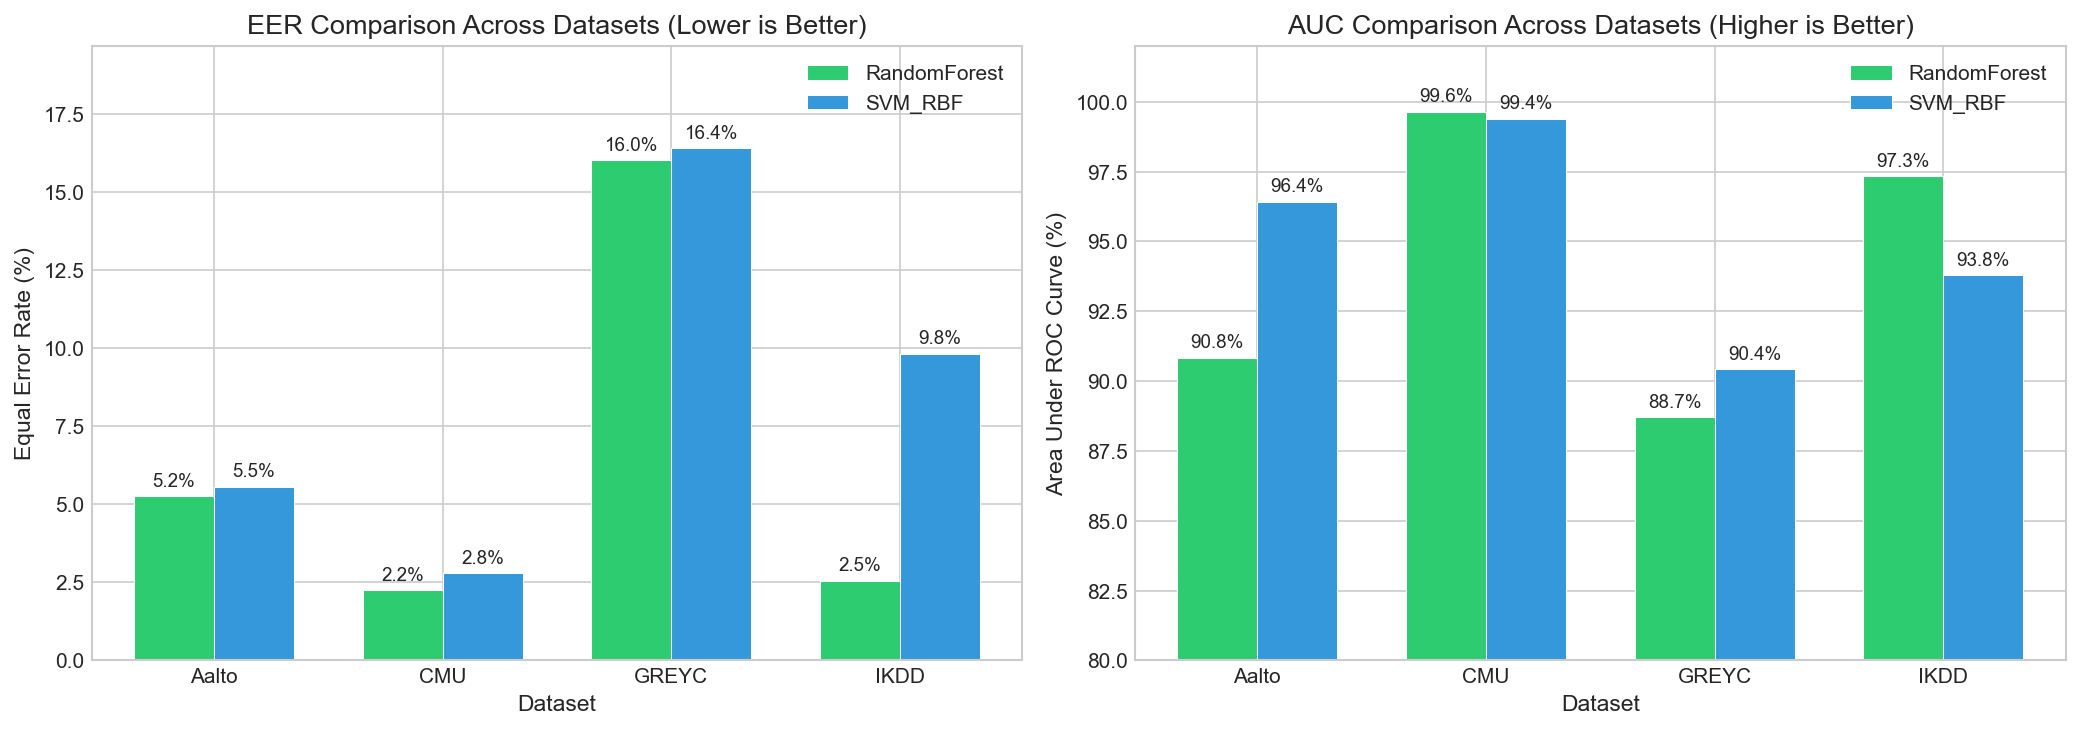

Saved: fig_7_1_cross_dataset_comparison.png


In [295]:
# 7.1 CROSS-DATASET PERFORMANCE COMPARISON
# =============================================================================

print("=" * 60)
print("7.1 CROSS-DATASET PERFORMANCE COMPARISON")
print("=" * 60)

# Data from Section 6.1 and 6.2 results
eer_data = {
    'Dataset': ['Aalto', 'CMU', 'GREYC', 'IKDD'] * 2,
    'Model': ['RandomForest'] * 4 + ['SVM_RBF'] * 4,
    'EER (%)': [5.25, 2.24, 16.02, 2.54, 5.55, 2.79, 16.40, 9.82]
}
eer_df = pd.DataFrame(eer_data)

auc_data = {
    'Dataset': ['Aalto', 'CMU', 'GREYC', 'IKDD'] * 2,
    'Model': ['RandomForest'] * 4 + ['SVM_RBF'] * 4,
    'AUC (%)': [90.82, 99.64, 88.70, 97.33, 96.41, 99.40, 90.42, 93.79]
}
auc_df = pd.DataFrame(auc_data)

# Figure 7.1: EER and AUC Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EER Bar Chart
ax1 = axes[0]
eer_pivot = eer_df.pivot(index='Dataset', columns='Model', values='EER (%)')
eer_pivot = eer_pivot[['RandomForest', 'SVM_RBF']]  # Ensure order
x = np.arange(len(eer_pivot.index))
width = 0.35

bars1 = ax1.bar(x - width/2, eer_pivot['RandomForest'], width, 
                label='RandomForest', color=COLORS['RandomForest'], edgecolor='white', linewidth=0.5)
bars2 = ax1.bar(x + width/2, eer_pivot['SVM_RBF'], width, 
                label='SVM_RBF', color=COLORS['SVM_RBF'], edgecolor='white', linewidth=0.5)

ax1.set_xlabel('Dataset')
ax1.set_ylabel('Equal Error Rate (%)')
ax1.set_title('EER Comparison Across Datasets (Lower is Better)')
ax1.set_xticks(x)
ax1.set_xticklabels(eer_pivot.index)
ax1.legend()
ax1.set_ylim(0, max(eer_df['EER (%)']) * 1.2)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# AUC Bar Chart
ax2 = axes[1]
auc_pivot = auc_df.pivot(index='Dataset', columns='Model', values='AUC (%)')
auc_pivot = auc_pivot[['RandomForest', 'SVM_RBF']]

bars3 = ax2.bar(x - width/2, auc_pivot['RandomForest'], width, 
                label='RandomForest', color=COLORS['RandomForest'], edgecolor='white', linewidth=0.5)
bars4 = ax2.bar(x + width/2, auc_pivot['SVM_RBF'], width, 
                label='SVM_RBF', color=COLORS['SVM_RBF'], edgecolor='white', linewidth=0.5)

ax2.set_xlabel('Dataset')
ax2.set_ylabel('Area Under ROC Curve (%)')
ax2.set_title('AUC Comparison Across Datasets (Higher is Better)')
ax2.set_xticks(x)
ax2.set_xticklabels(auc_pivot.index)
ax2.legend()
ax2.set_ylim(80, 102)

# Adding value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_7_1_cross_dataset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_1_cross_dataset_comparison.png")



7.2 DETAILED METRICS HEATMAP


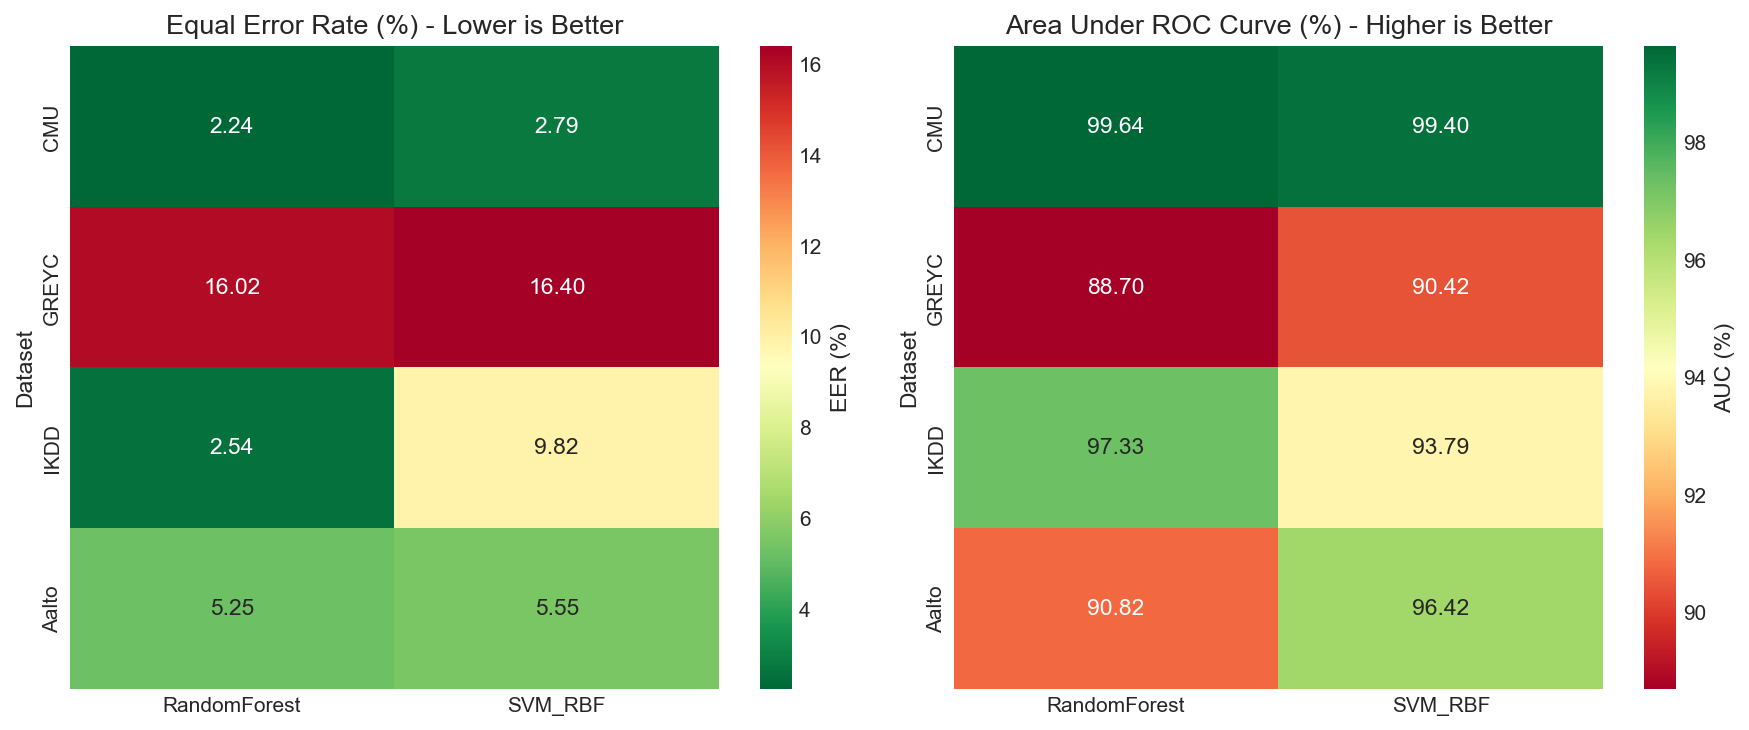

Saved: fig_7_2_metrics_heatmap.png


In [297]:
# 7.2 DETAILED METRICS HEATMAP
# =============================================================================

print("\n" + "=" * 60)
print("7.2 DETAILED METRICS HEATMAP")
print("=" * 60)

# Full metrics from Section 6.1
metrics_data = {
    ('CMU', 'RandomForest'): {'EER': 2.24, 'FAR': 2.24, 'FRR': 2.23, 'AUC': 99.64, 'ACC': 97.76},
    ('CMU', 'SVM_RBF'): {'EER': 2.79, 'FAR': 2.79, 'FRR': 2.95, 'AUC': 99.40, 'ACC': 97.21},
    ('GREYC', 'RandomForest'): {'EER': 16.02, 'FAR': 16.02, 'FRR': 17.93, 'AUC': 88.70, 'ACC': 83.97},
    ('GREYC', 'SVM_RBF'): {'EER': 16.40, 'FAR': 16.40, 'FRR': 16.42, 'AUC': 90.42, 'ACC': 83.60},
    ('IKDD', 'RandomForest'): {'EER': 2.54, 'FAR': 2.54, 'FRR': 0.87, 'AUC': 97.33, 'ACC': 97.48},
    ('IKDD', 'SVM_RBF'): {'EER': 9.82, 'FAR': 9.82, 'FRR': 1.80, 'AUC': 93.79, 'ACC': 90.23},
    ('Aalto', 'RandomForest'): {'EER': 5.25, 'FAR': 5.25, 'FRR': 13.22, 'AUC': 90.82, 'ACC': 94.73},
    ('Aalto', 'SVM_RBF'): {'EER': 5.55, 'FAR': 5.55, 'FRR': 2.92, 'AUC': 96.42, 'ACC': 94.46},
}

# Create heatmap for EER (inverted - lower is better, so higher color intensity)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# EER Heatmap
eer_matrix = np.array([
    [metrics_data[('CMU', 'RandomForest')]['EER'], metrics_data[('CMU', 'SVM_RBF')]['EER']],
    [metrics_data[('GREYC', 'RandomForest')]['EER'], metrics_data[('GREYC', 'SVM_RBF')]['EER']],
    [metrics_data[('IKDD', 'RandomForest')]['EER'], metrics_data[('IKDD', 'SVM_RBF')]['EER']],
    [metrics_data[('Aalto', 'RandomForest')]['EER'], metrics_data[('Aalto', 'SVM_RBF')]['EER']],
])

sns.heatmap(eer_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0],
            xticklabels=['RandomForest', 'SVM_RBF'],
            yticklabels=['CMU', 'GREYC', 'IKDD', 'Aalto'],
            cbar_kws={'label': 'EER (%)'})
axes[0].set_title('Equal Error Rate (%) - Lower is Better')
axes[0].set_ylabel('Dataset')

# AUC Heatmap
auc_matrix = np.array([
    [metrics_data[('CMU', 'RandomForest')]['AUC'], metrics_data[('CMU', 'SVM_RBF')]['AUC']],
    [metrics_data[('GREYC', 'RandomForest')]['AUC'], metrics_data[('GREYC', 'SVM_RBF')]['AUC']],
    [metrics_data[('IKDD', 'RandomForest')]['AUC'], metrics_data[('IKDD', 'SVM_RBF')]['AUC']],
    [metrics_data[('Aalto', 'RandomForest')]['AUC'], metrics_data[('Aalto', 'SVM_RBF')]['AUC']],
])

sns.heatmap(auc_matrix, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
            xticklabels=['RandomForest', 'SVM_RBF'],
            yticklabels=['CMU', 'GREYC', 'IKDD', 'Aalto'],
            cbar_kws={'label': 'AUC (%)'})
axes[1].set_title('Area Under ROC Curve (%) - Higher is Better')
axes[1].set_ylabel('Dataset')

plt.tight_layout()
plt.savefig('fig_7_2_metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_2_metrics_heatmap.png")


7.3 SPLIT SENSITIVITY ANALYSIS


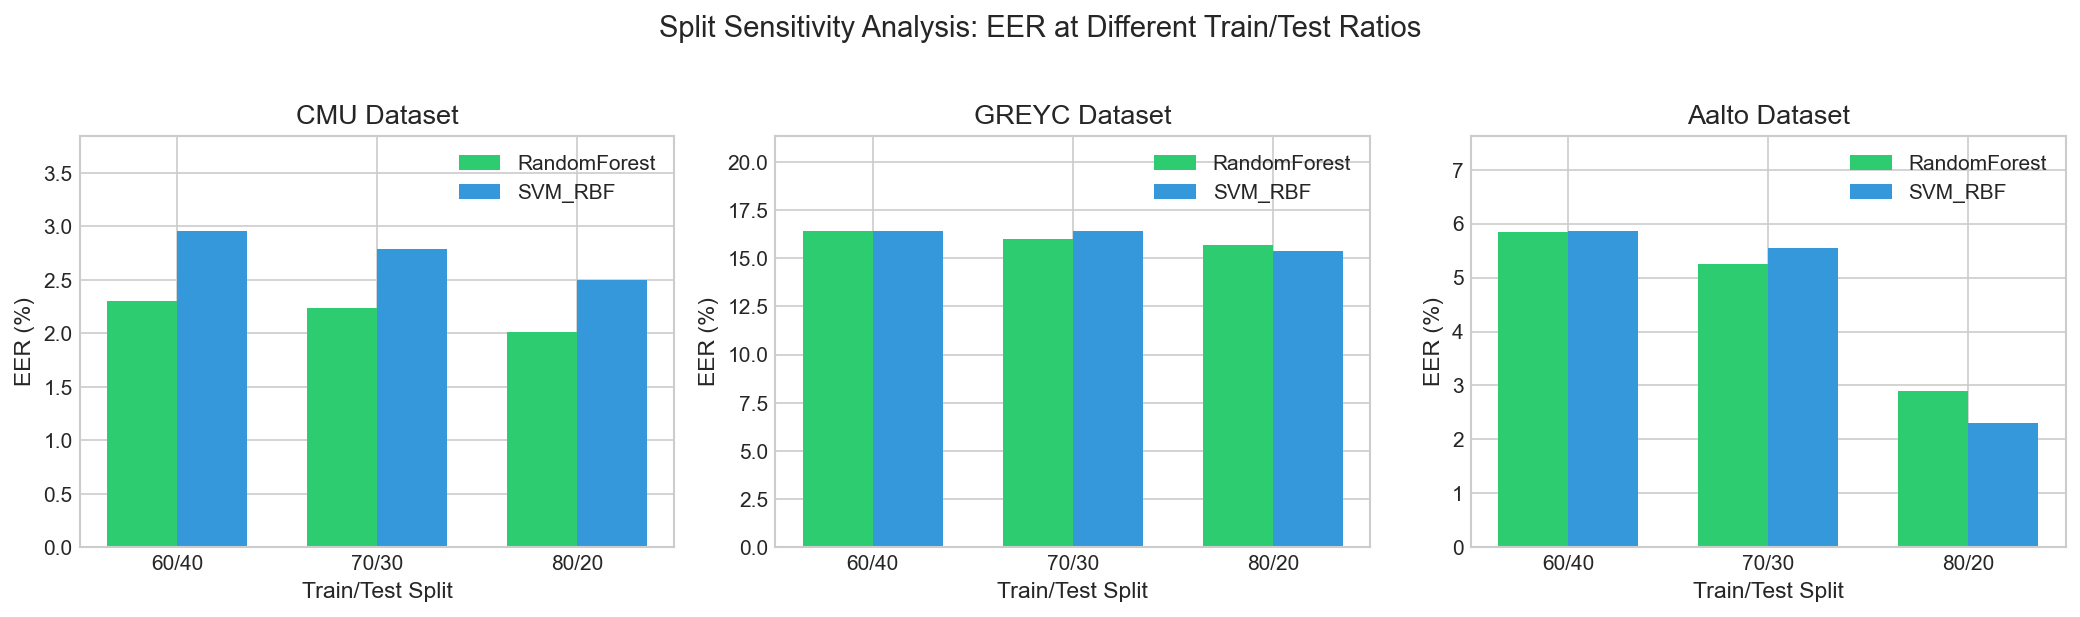

Saved: fig_7_3_split_sensitivity.png


In [299]:
# 7.3 SPLIT SENSITIVITY ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("7.3 SPLIT SENSITIVITY ANALYSIS")
print("=" * 60)

# Data from Section 6.5
split_data = {
    'CMU': {
        'RandomForest': [2.30, 2.24, 2.01],
        'SVM_RBF': [2.96, 2.79, 2.50]
    },
    'GREYC': {
        'RandomForest': [16.41, 16.02, 15.69],
        'SVM_RBF': [16.43, 16.40, 15.40]
    },
    'Aalto': {
        'RandomForest': [5.84, 5.25, 2.9],
        'SVM_RBF': [5.87, 5.55, 2.3]
    }
}
splits = ['60/40', '70/30', '80/20']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, (dataset, data) in enumerate(split_data.items()):
    ax = axes[idx]
    x = np.arange(len(splits))
    width = 0.35
    
    ax.bar(x - width/2, data['RandomForest'], width, 
           label='RandomForest', color=COLORS['RandomForest'])
    ax.bar(x + width/2, data['SVM_RBF'], width, 
           label='SVM_RBF', color=COLORS['SVM_RBF'])
    
    ax.set_xlabel('Train/Test Split')
    ax.set_ylabel('EER (%)')
    ax.set_title(f'{dataset} Dataset')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.legend()
    
    # Set y-limits based on data range
    all_vals = data['RandomForest'] + data['SVM_RBF']
    ax.set_ylim(0, max(all_vals) * 1.3)

plt.suptitle('Split Sensitivity Analysis: EER at Different Train/Test Ratios', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_7_3_split_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_3_split_sensitivity.png")


7.4 PER-USER PERFORMANCE DISTRIBUTION


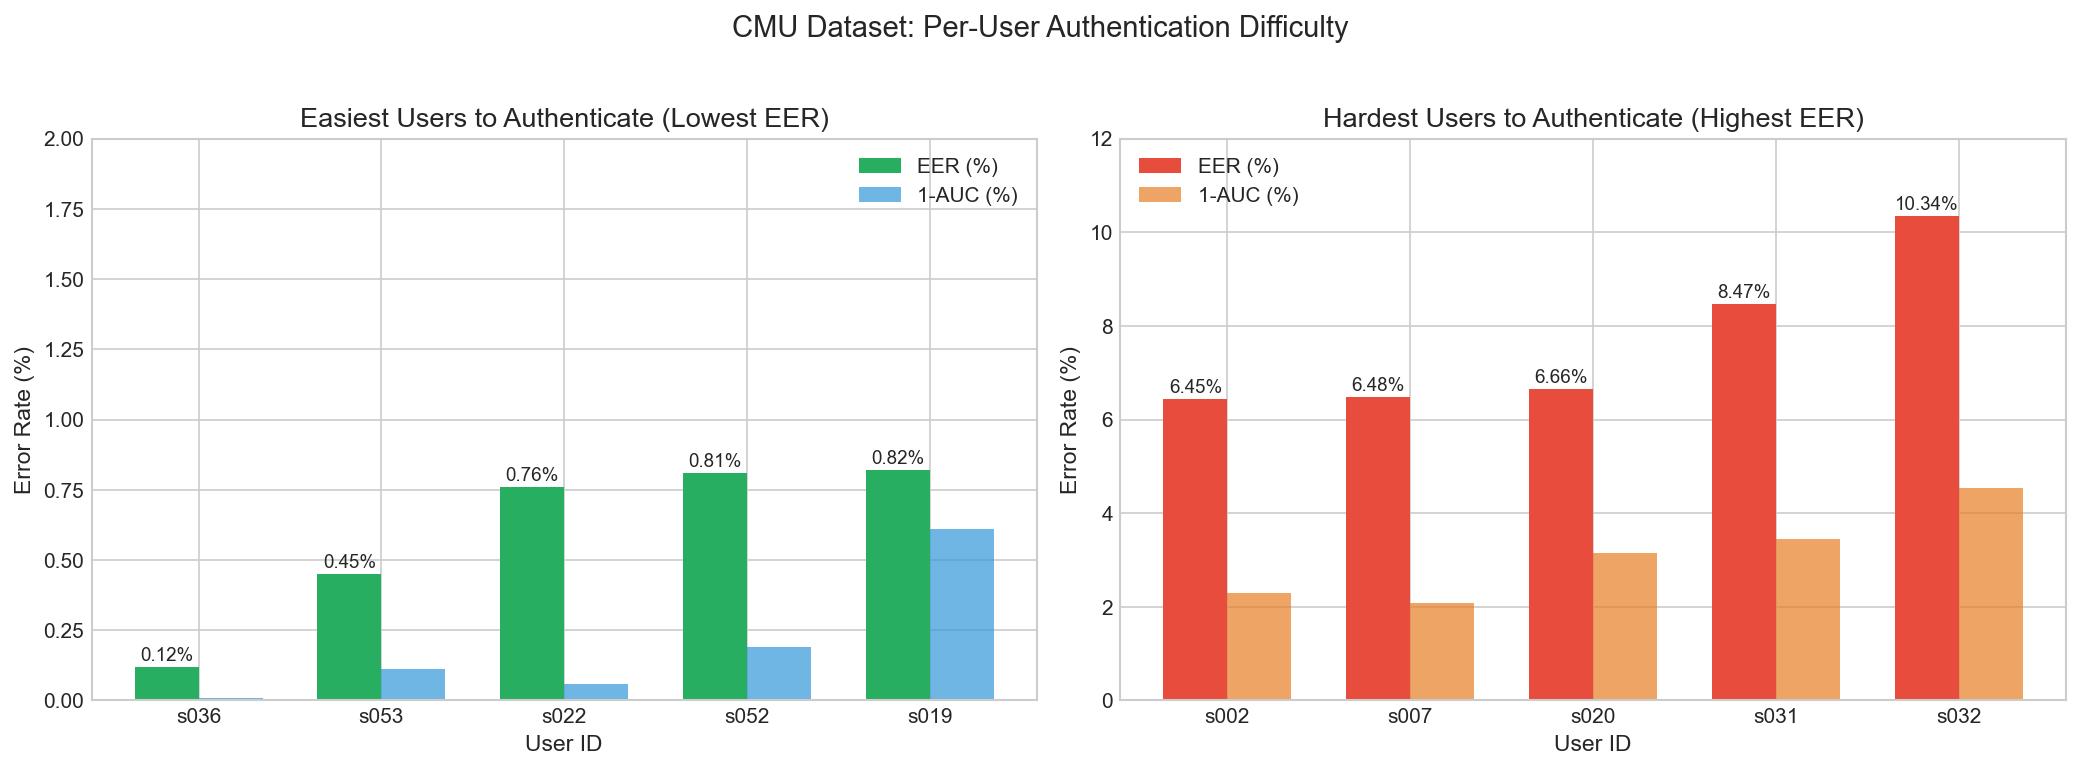

Saved: fig_7_4_per_user_analysis.png


In [301]:
# 7.4 PER-USER PERFORMANCE DISTRIBUTION (CMU)
# =============================================================================

print("\n" + "=" * 60)
print("7.4 PER-USER PERFORMANCE DISTRIBUTION")
print("=" * 60)

# Data from Section 6.3 (Per-User Analysis)
# Statistics: Mean=3.14%, Std=2.15%, Min=0.12%, Max=10.34%, Median=2.64%

# Easiest users (lowest EER)
easiest_users = {
    's036': {'EER': 0.12, 'AUC': 99.99},
    's053': {'EER': 0.45, 'AUC': 99.89},
    's022': {'EER': 0.76, 'AUC': 99.94},
    's052': {'EER': 0.81, 'AUC': 99.81},
    's019': {'EER': 0.82, 'AUC': 99.39},
}

# Hardest users (highest EER)
hardest_users = {
    's002': {'EER': 6.45, 'AUC': 97.70},
    's007': {'EER': 6.48, 'AUC': 97.92},
    's020': {'EER': 6.66, 'AUC': 96.85},
    's031': {'EER': 8.47, 'AUC': 96.55},
    's032': {'EER': 10.34, 'AUC': 95.46},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Easiest Users
ax1 = axes[0]
users = list(easiest_users.keys())
eers = [easiest_users[u]['EER'] for u in users]
aucs = [easiest_users[u]['AUC'] for u in users]

x = np.arange(len(users))
width = 0.35

bars1 = ax1.bar(x - width/2, eers, width, label='EER (%)', color='#27ae60')
bars2 = ax1.bar(x + width/2, [100-a for a in aucs], width, label='1-AUC (%)', color='#3498db', alpha=0.7)

ax1.set_xlabel('User ID')
ax1.set_ylabel('Error Rate (%)')
ax1.set_title('Easiest Users to Authenticate (Lowest EER)')
ax1.set_xticks(x)
ax1.set_xticklabels(users)
ax1.legend()
ax1.set_ylim(0, 2)

# Add value labels
for bar, val in zip(bars1, eers):
    ax1.annotate(f'{val:.2f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

# Hardest Users
ax2 = axes[1]
users = list(hardest_users.keys())
eers = [hardest_users[u]['EER'] for u in users]
aucs = [hardest_users[u]['AUC'] for u in users]

x = np.arange(len(users))

bars3 = ax2.bar(x - width/2, eers, width, label='EER (%)', color='#e74c3c')
bars4 = ax2.bar(x + width/2, [100-a for a in aucs], width, label='1-AUC (%)', color='#e67e22', alpha=0.7)

ax2.set_xlabel('User ID')
ax2.set_ylabel('Error Rate (%)')
ax2.set_title('Hardest Users to Authenticate (Highest EER)')
ax2.set_xticks(x)
ax2.set_xticklabels(users)
ax2.legend()
ax2.set_ylim(0, 12)

# Add value labels
for bar, val in zip(bars3, eers):
    ax2.annotate(f'{val:.2f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.suptitle('CMU Dataset: Per-User Authentication Difficulty', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_7_4_per_user_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_4_per_user_analysis.png")



7.5 FEATURE IMPORTANCE ANALYSIS


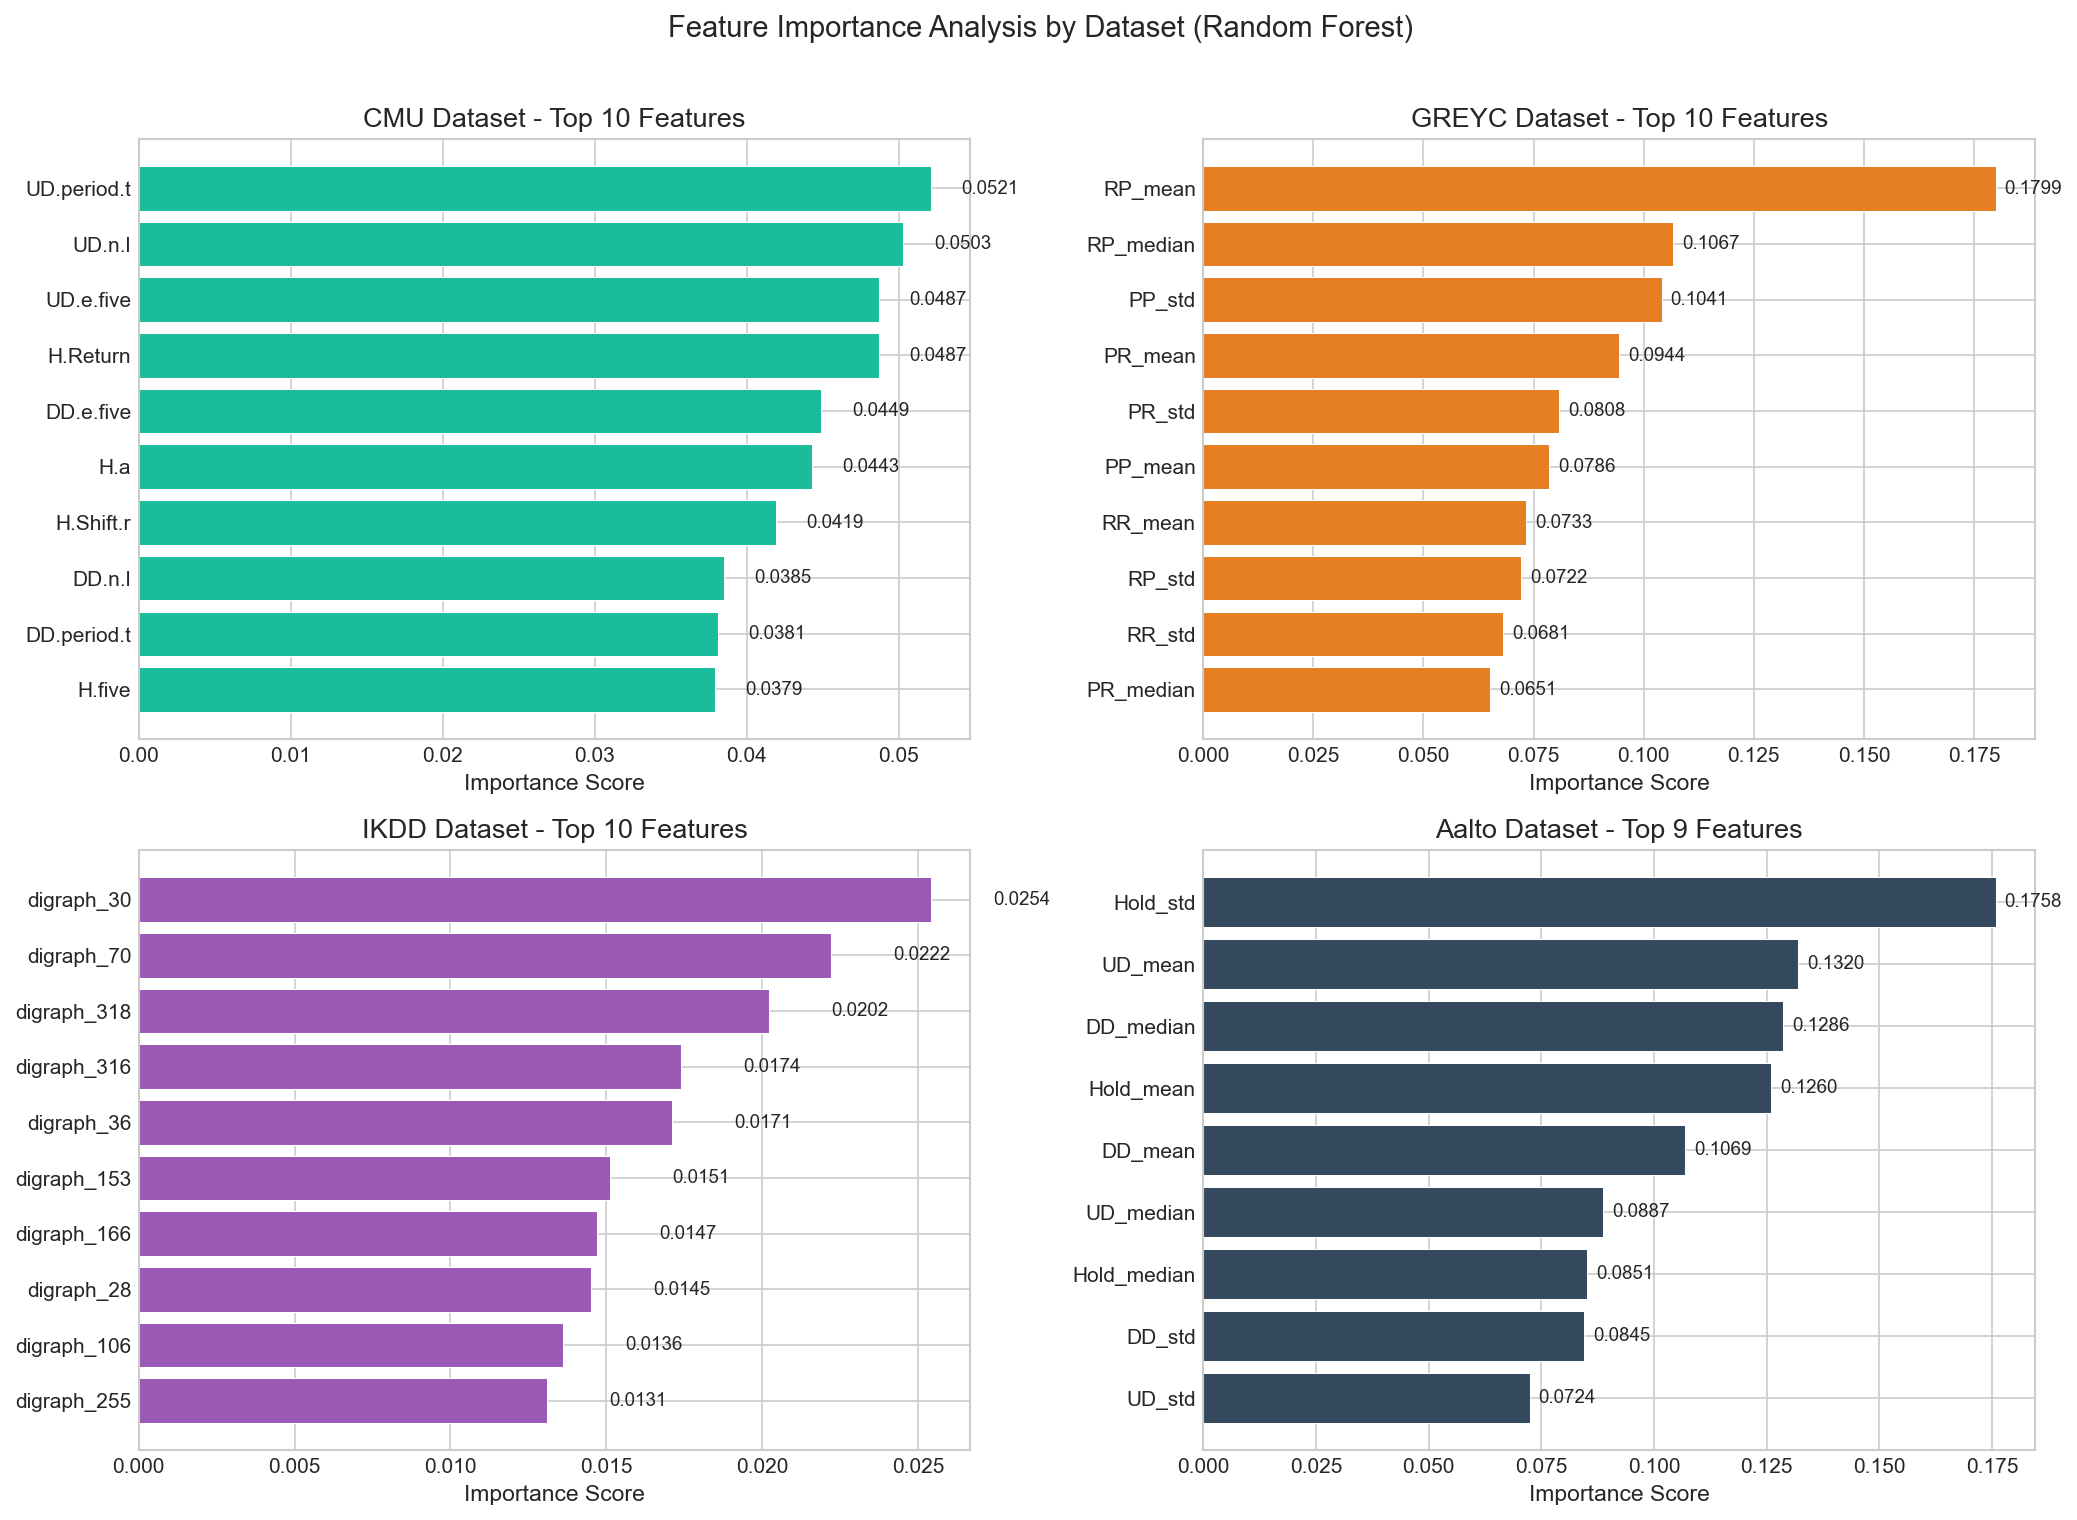

Saved: fig_7_5_feature_importance.png


In [303]:
# 7.5 FEATURE IMPORTANCE ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("7.5 FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Data from Section 6.8
feature_importance = {
    'CMU': {
        'features': ['UD.period.t', 'UD.n.l', 'UD.e.five', 'H.Return', 'DD.e.five', 
                     'H.a', 'H.Shift.r', 'DD.n.l', 'DD.period.t', 'H.five'],
        'importance': [0.0521, 0.0503, 0.0487, 0.0487, 0.0449, 0.0443, 0.0419, 0.0385, 0.0381, 0.0379]
    },
    'GREYC': {
        'features': ['RP_mean', 'RP_median', 'PP_std', 'PR_mean', 'PR_std', 
                     'PP_mean', 'RR_mean', 'RP_std', 'RR_std', 'PR_median'],
        'importance': [0.1799, 0.1067, 0.1041, 0.0944, 0.0808, 0.0786, 0.0733, 0.0722, 0.0681, 0.0651]
    },
    'IKDD': {
        'features': ['digraph_30', 'digraph_70', 'digraph_318', 'digraph_316', 'digraph_36',
                     'digraph_153', 'digraph_166', 'digraph_28', 'digraph_106', 'digraph_255'],
        'importance': [0.0254, 0.0222, 0.0202, 0.0174, 0.0171, 0.0151, 0.0147, 0.0145, 0.0136, 0.0131]
    },
    'Aalto': {
        'features': ['Hold_std', 'UD_mean', 'DD_median', 'Hold_mean', 'DD_mean',
                     'UD_median', 'Hold_median', 'DD_std', 'UD_std'],
        'importance': [0.1758, 0.1320, 0.1286, 0.1260, 0.1069, 0.0887, 0.0851, 0.0845, 0.0724]
    }
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

dataset_colors = ['#1abc9c', '#e67e22', '#9b59b6', '#34495e']

for idx, (dataset, data) in enumerate(feature_importance.items()):
    ax = axes[idx]
    features = data['features'][:10]
    importance = data['importance'][:10]
    
    # Horizontal bar chart (easier to read feature names)
    y_pos = np.arange(len(features))
    ax.barh(y_pos, importance, color=dataset_colors[idx], edgecolor='white', linewidth=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()  # Top feature at top
    ax.set_xlabel('Importance Score')
    ax.set_title(f'{dataset} Dataset - Top {len(features)} Features')
    
    # Add value labels
    for i, (v, f) in enumerate(zip(importance, features)):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Feature Importance Analysis by Dataset (Random Forest)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_7_5_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_5_feature_importance.png")



7.6 LEARNING CURVE ANALYSIS


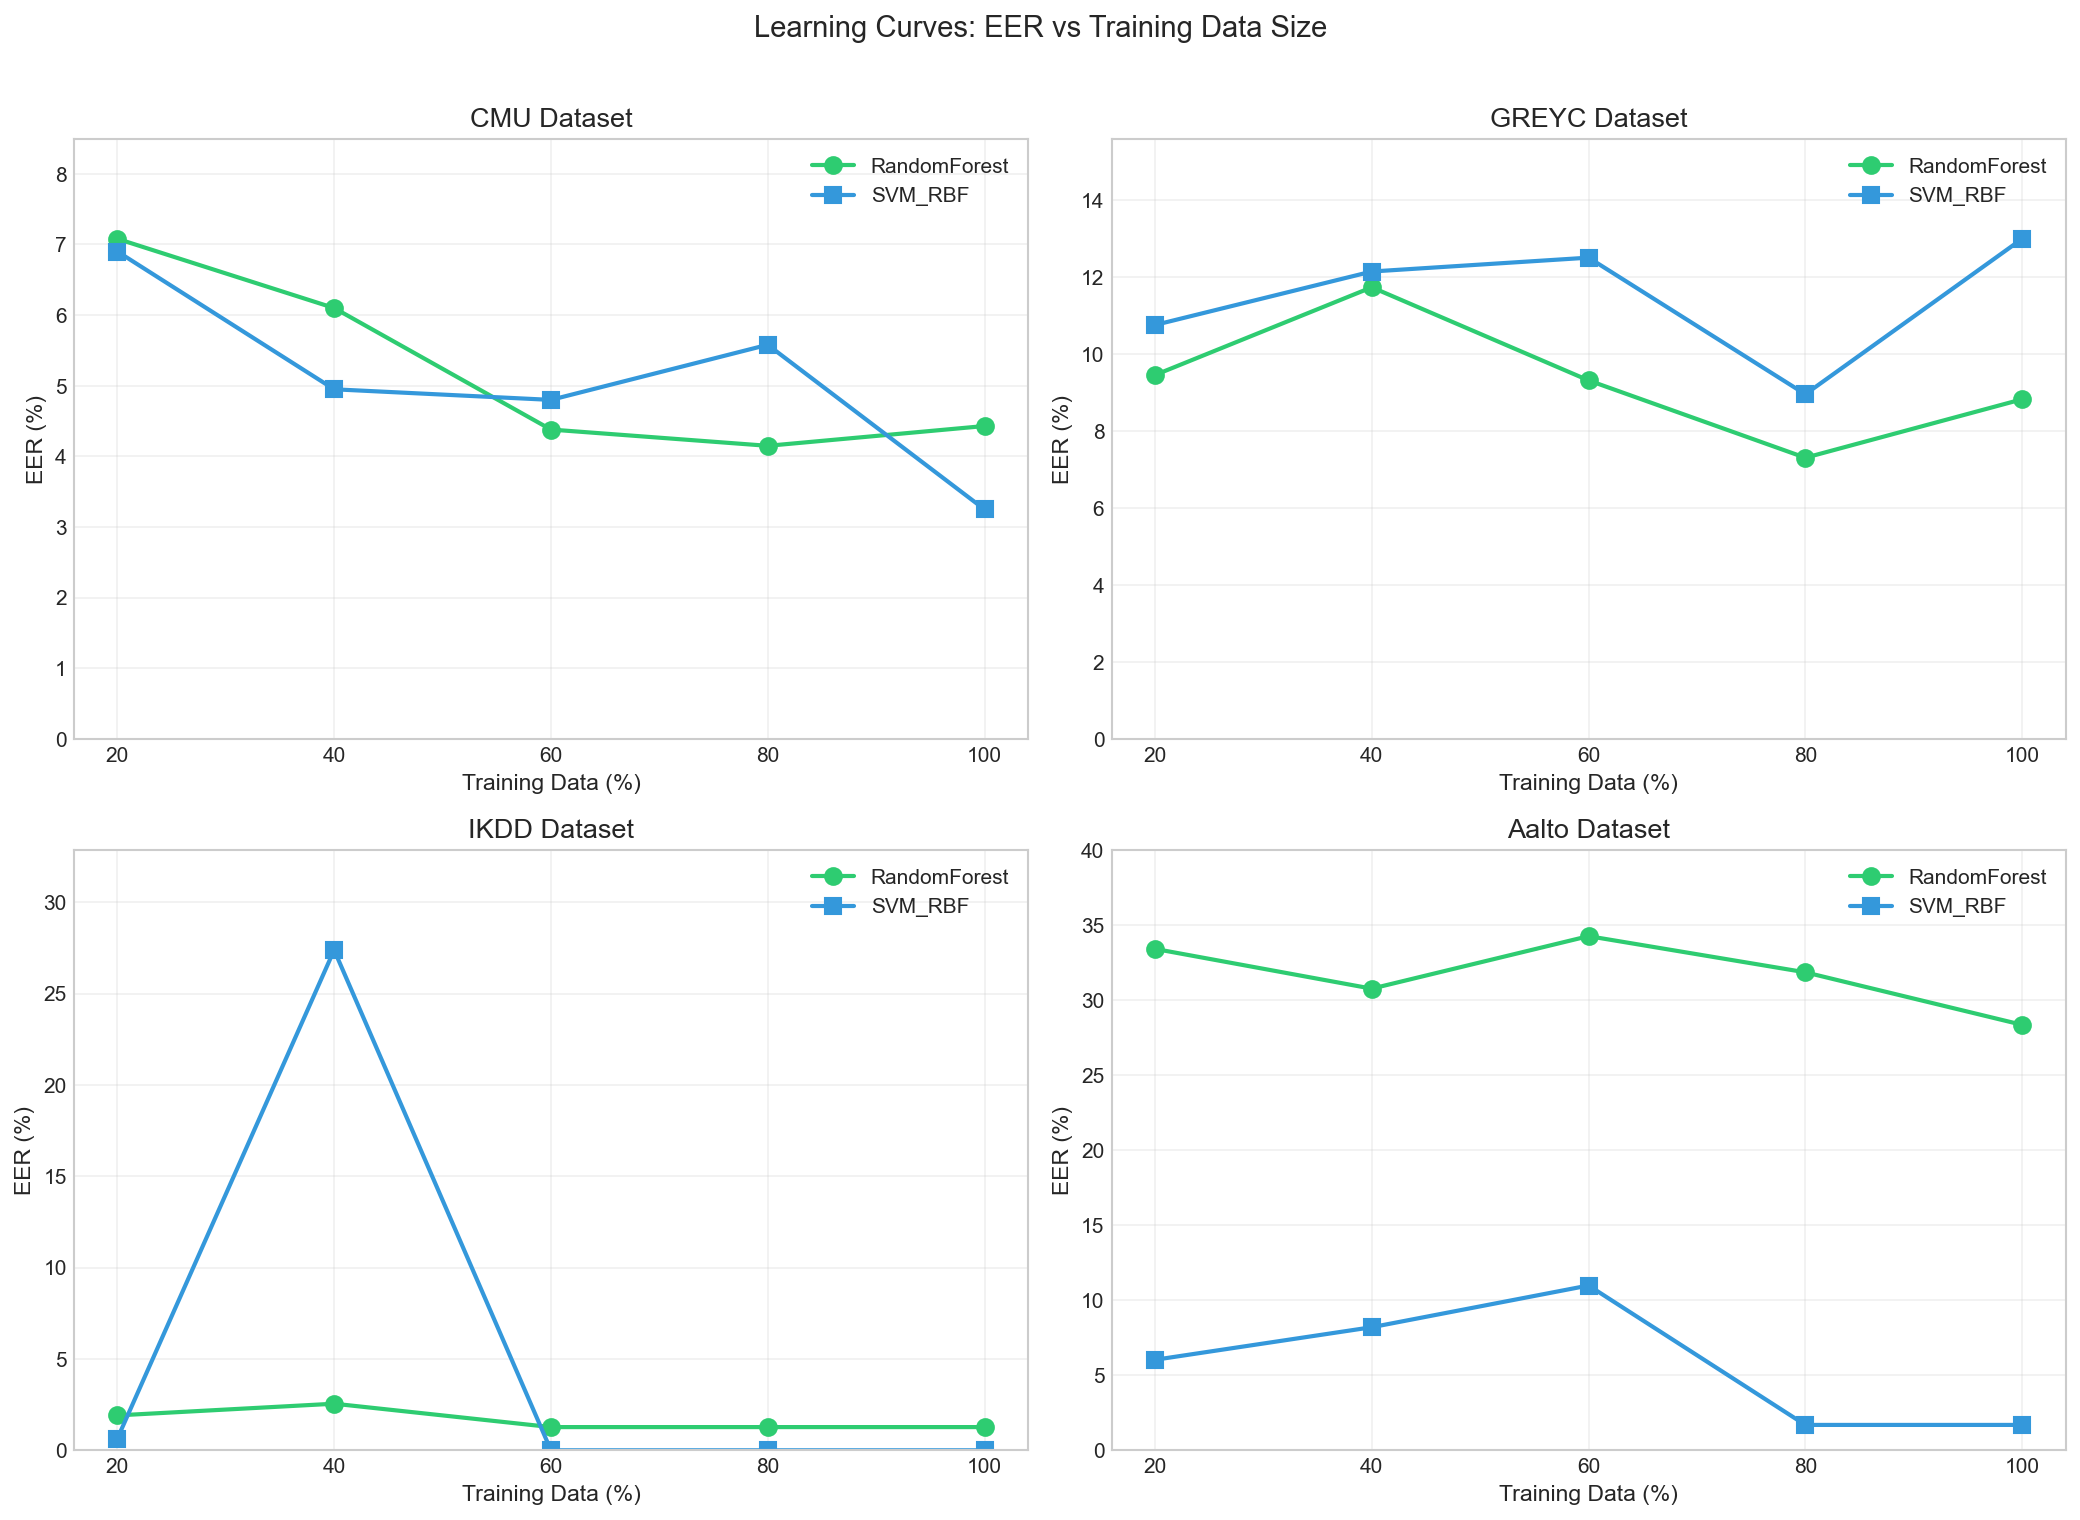

Saved: fig_7_6_learning_curves.png


In [305]:
# 7.6 LEARNING CURVE ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("7.6 LEARNING CURVE ANALYSIS")
print("=" * 60)

# Data from Section 6.9
learning_curves = {
    'CMU': {
        'train_pct': [20, 40, 60, 80, 100],
        'RandomForest': {'EER': [7.08, 6.10, 4.38, 4.15, 4.43], 'AUC': [98.45, 98.77, 99.19, 99.31, 99.31]},
        'SVM_RBF': {'EER': [6.90, 4.95, 4.80, 5.58, 3.25], 'AUC': [98.04, 98.52, 98.69, 99.00, 99.18]}
    },
    'GREYC': {
        'train_pct': [20, 40, 60, 80, 100],
        'RandomForest': {'EER': [9.46, 11.74, 9.32, 7.31, 8.83], 'AUC': [97.81, 97.16, 97.64, 98.28, 97.96]},
        'SVM_RBF': {'EER': [10.76, 12.15, 12.51, 8.96, 13.00], 'AUC': [97.50, 97.64, 97.28, 97.70, 95.83]}
    },
    'IKDD': {
        'train_pct': [20, 40, 60, 80, 100],
        'RandomForest': {'EER': [1.91, 2.55, 1.27, 1.27, 1.27], 'AUC': [98.09, 98.30, 99.58, 99.58, 99.58]},
        'SVM_RBF': {'EER': [0.64, 27.39, 0.00, 0.00, 0.00], 'AUC': [93.21, 95.44, 100.00, 100.00, 100.00]}
    },
    'Aalto': {
        'train_pct': [20, 40, 60, 80, 100],
        'RandomForest': {'EER': [33.41, 30.76, 34.26, 31.85, 28.35], 'AUC': [77.93, 78.45, 73.06, 80.16, 82.37]},
        'SVM_RBF': {'EER': [6.03, 8.20, 10.98, 1.69, 1.69], 'AUC': [96.14, 95.58, 95.46, 98.75, 98.79]}
    }
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (dataset, data) in enumerate(learning_curves.items()):
    ax = axes[idx]
    train_pct = data['train_pct']
    
    # Plot EER curves
    ax.plot(train_pct, data['RandomForest']['EER'], 'o-', 
            color=COLORS['RandomForest'], linewidth=2, markersize=8, label='RandomForest')
    ax.plot(train_pct, data['SVM_RBF']['EER'], 's-', 
            color=COLORS['SVM_RBF'], linewidth=2, markersize=8, label='SVM_RBF')
    
    ax.set_xlabel('Training Data (%)')
    ax.set_ylabel('EER (%)')
    ax.set_title(f'{dataset} Dataset')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(train_pct)
    
    # Set reasonable y-limits
    all_eer = data['RandomForest']['EER'] + data['SVM_RBF']['EER']
    ax.set_ylim(0, min(max(all_eer) * 1.2, 40))

plt.suptitle('Learning Curves: EER vs Training Data Size', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_7_6_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_6_learning_curves.png")



7.7 THRESHOLD ANALYSIS (FAR/FRR TRADE-OFF)


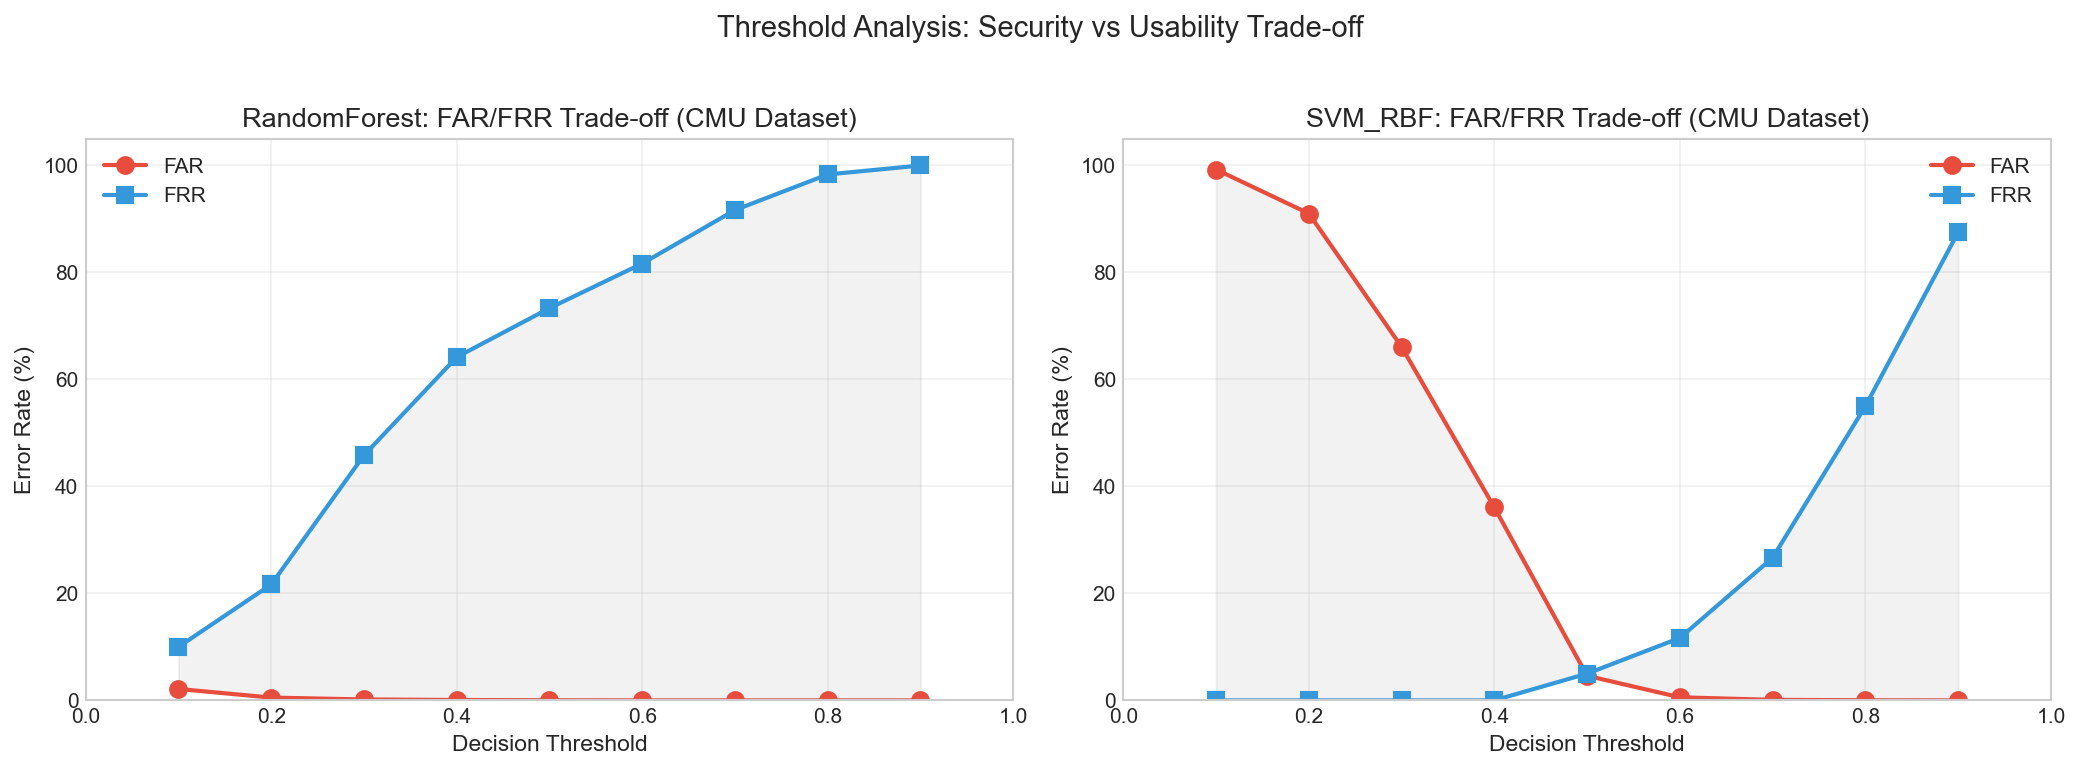

Saved: fig_7_7_threshold_analysis.png


In [307]:
# 7.7 THRESHOLD ANALYSIS (FAR/FRR TRADE-OFF)
# =============================================================================

print("\n" + "=" * 60)
print("7.7 THRESHOLD ANALYSIS (FAR/FRR TRADE-OFF)")
print("=" * 60)

# Data from Section 6.10 (CMU Dataset)
threshold_data = {
    'RandomForest': {
        'threshold': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
        'FAR': [2.13, 0.52, 0.17, 0.07, 0.02, 0.00, 0.00, 0.00, 0.00],
        'FRR': [10.00, 21.67, 45.83, 64.17, 73.33, 81.67, 91.67, 98.33, 100.00]
    },
    'SVM_RBF': {
        'threshold': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
        'FAR': [99.25, 91.02, 66.08, 36.07, 4.60, 0.57, 0.10, 0.02, 0.00],
        'FRR': [0.00, 0.00, 0.00, 0.00, 5.00, 11.67, 26.67, 55.00, 87.50]
    }
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (model, data) in enumerate(threshold_data.items()):
    ax = axes[idx]
    thresholds = data['threshold']
    far = data['FAR']
    frr = data['FRR']
    
    ax.plot(thresholds, far, 'o-', color='#e74c3c', linewidth=2, markersize=8, label='FAR')
    ax.plot(thresholds, frr, 's-', color='#3498db', linewidth=2, markersize=8, label='FRR')
    
    # Find approximate EER point
    ax.fill_between(thresholds, far, frr, alpha=0.1, color='gray')
    
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Error Rate (%)')
    ax.set_title(f'{model}: FAR/FRR Trade-off (CMU Dataset)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 105)

plt.suptitle('Threshold Analysis: Security vs Usability Trade-off', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_7_7_threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_7_threshold_analysis.png")


7.8 AUTHENTICATION SIMULATION RESULTS


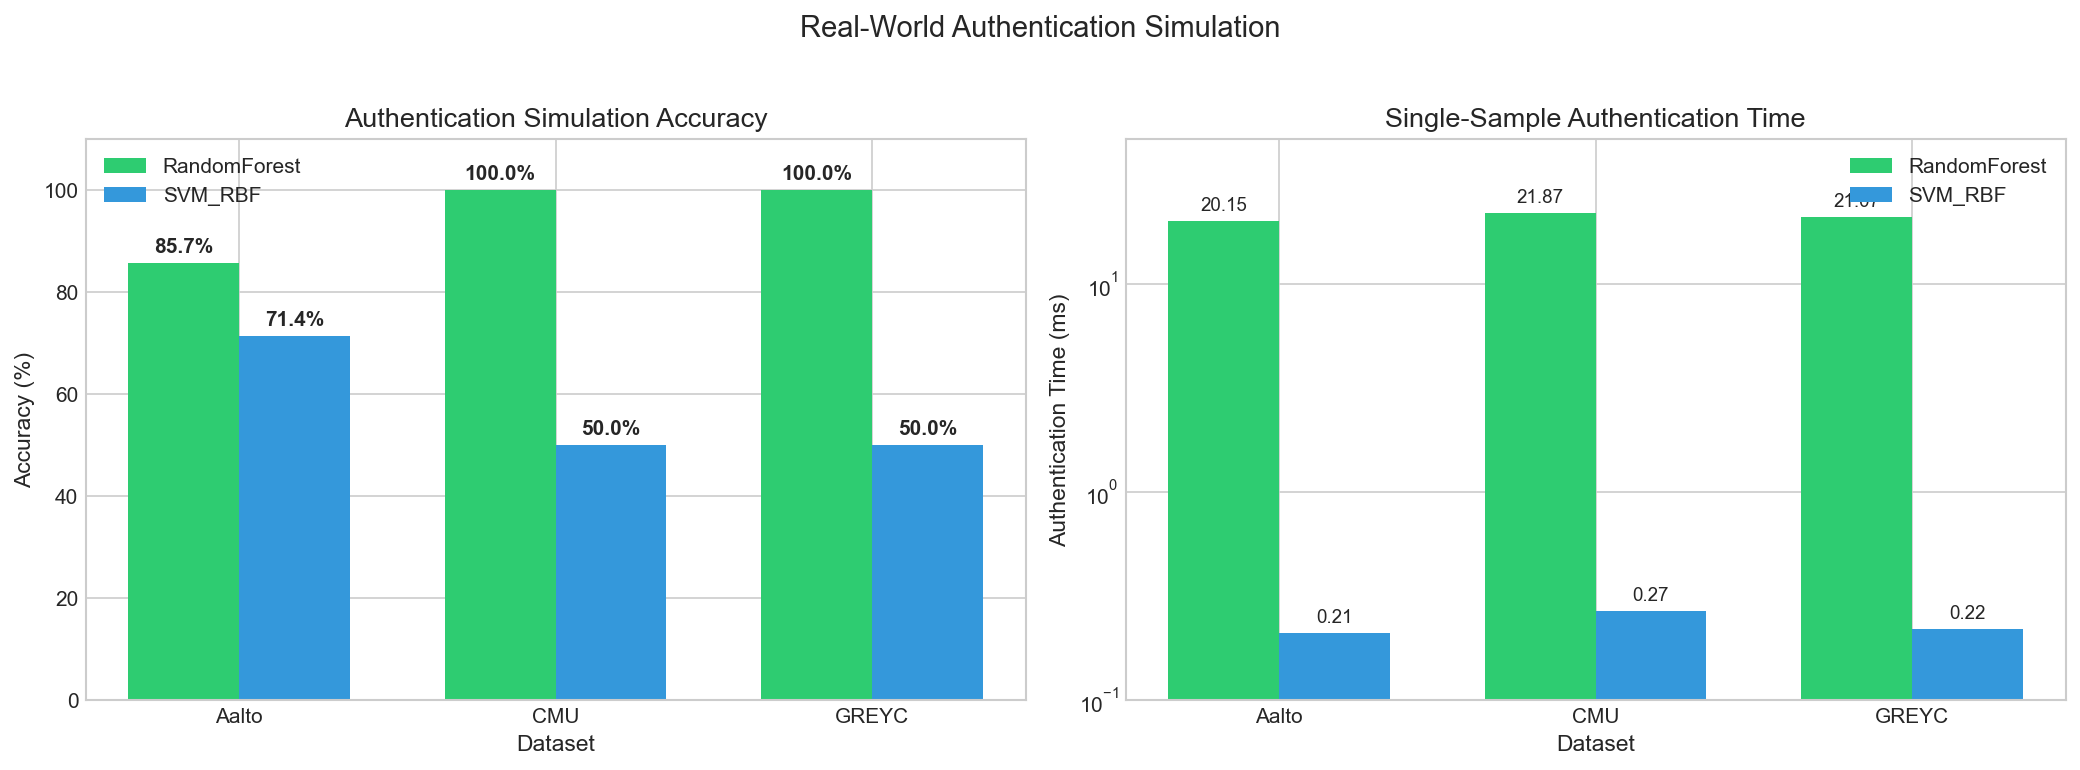

Saved: fig_7_8_auth_simulation.png


In [311]:
# 7.8 AUTHENTICATION SIMULATION RESULTS
# =============================================================================

print("\n" + "=" * 60)
print("7.8 AUTHENTICATION SIMULATION RESULTS")
print("=" * 60)

# Data from Section 6.7
auth_sim = {
    'Dataset': ['CMU', 'GREYC', 'Aalto'] * 2,
    'Model': ['RandomForest'] * 3 + ['SVM_RBF'] * 3,
    'Accuracy (%)': [100.0, 100.0, 85.7, 50.0, 50.0, 71.4],
    'Auth Time (ms)': [21.87, 21.07, 20.15, 0.27, 0.22, 0.21]
}
auth_df = pd.DataFrame(auth_sim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Comparison
ax1 = axes[0]
auth_pivot_acc = auth_df.pivot(index='Dataset', columns='Model', values='Accuracy (%)')
x = np.arange(len(auth_pivot_acc.index))
width = 0.35

bars1 = ax1.bar(x - width/2, auth_pivot_acc['RandomForest'], width, 
                label='RandomForest', color=COLORS['RandomForest'])
bars2 = ax1.bar(x + width/2, auth_pivot_acc['SVM_RBF'], width, 
                label='SVM_RBF', color=COLORS['SVM_RBF'])

ax1.set_xlabel('Dataset')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Authentication Simulation Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(auth_pivot_acc.index)
ax1.legend()
ax1.set_ylim(0, 110)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')



# Auth Time Comparison (log scale due to large difference)
ax2 = axes[1]
auth_pivot_time = auth_df.pivot(index='Dataset', columns='Model', values='Auth Time (ms)')

bars3 = ax2.bar(x - width/2, auth_pivot_time['RandomForest'], width, 
                label='RandomForest', color=COLORS['RandomForest'])
bars4 = ax2.bar(x + width/2, auth_pivot_time['SVM_RBF'], width, 
                label='SVM_RBF', color=COLORS['SVM_RBF'])

ax2.set_xlabel('Dataset')
ax2.set_ylabel('Authentication Time (ms)')
ax2.set_title('Single-Sample Authentication Time')
ax2.set_xticks(x)
ax2.set_xticklabels(auth_pivot_time.index)
ax2.legend()
ax2.set_yscale('log')
ax2.set_ylim(0.1, 50)

# Adding value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Real-World Authentication Simulation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_7_8_auth_simulation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_8_auth_simulation.png")



7.9 STATISTICAL SIGNIFICANCE SUMMARY


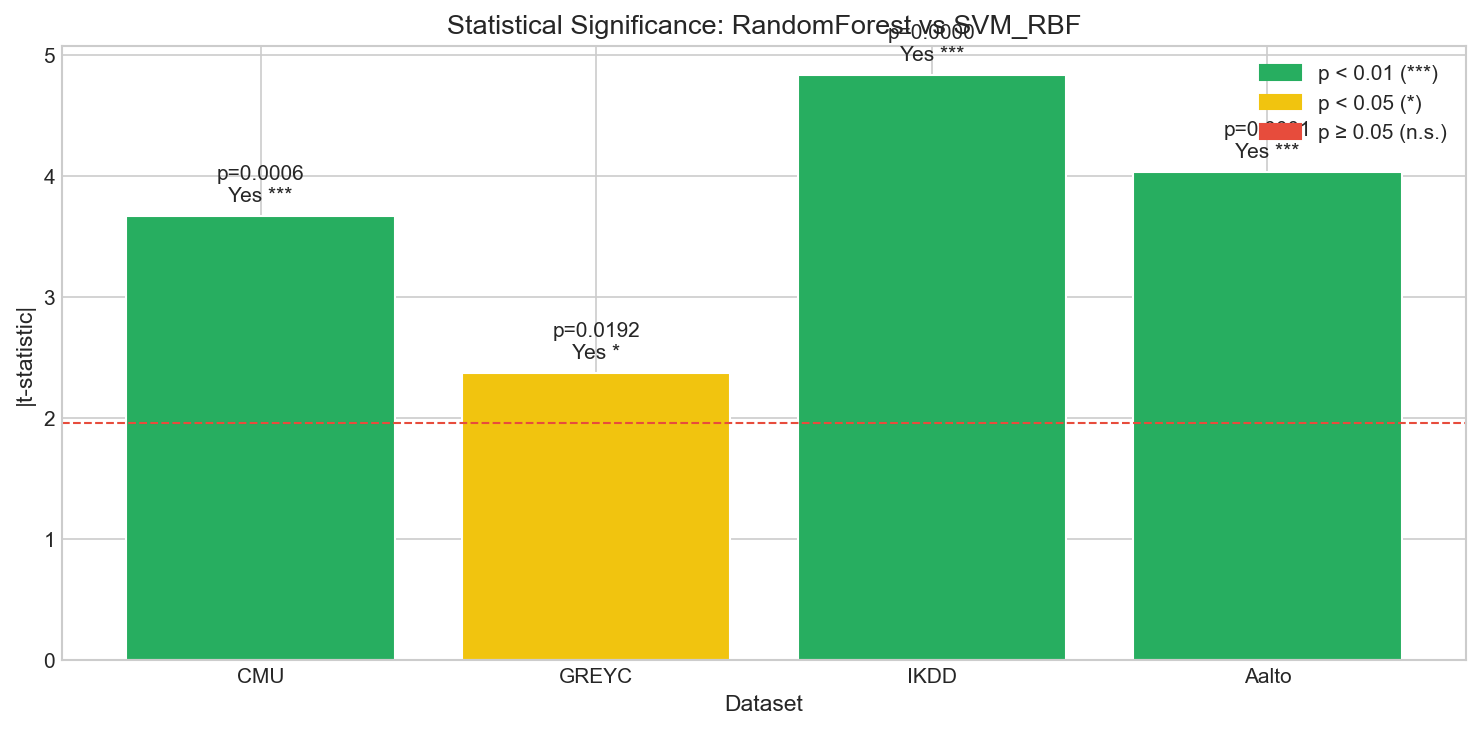

Saved: fig_7_9_statistical_significance.png


In [313]:
# 7.9 STATISTICAL SIGNIFICANCE SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("7.9 STATISTICAL SIGNIFICANCE SUMMARY")
print("=" * 60)

# Data from Section 6.6
stat_sig = {
    'Dataset': ['CMU', 'GREYC', 'IKDD', 'Aalto'],
    't-statistic': [-3.67, 2.37, -4.83, 4.03],
    'p-value': [0.0006, 0.0192, 0.0000, 0.0001],
    'Significant': ['Yes ***', 'Yes *', 'Yes ***', 'Yes ***']
}

fig, ax = plt.subplots(figsize=(10, 5))

datasets = stat_sig['Dataset']
t_stats = stat_sig['t-statistic']
p_values = stat_sig['p-value']

x = np.arange(len(datasets))
colors = ['#27ae60' if p < 0.01 else '#f1c40f' if p < 0.05 else '#e74c3c' 
          for p in p_values]

bars = ax.bar(x, np.abs(t_stats), color=colors, edgecolor='white', linewidth=1)

ax.set_xlabel('Dataset')
ax.set_ylabel('|t-statistic|')
ax.set_title('Statistical Significance: RandomForest vs SVM_RBF')
ax.set_xticks(x)
ax.set_xticklabels(datasets)

# Adding significance levels and p-values
for i, (bar, p, sig) in enumerate(zip(bars, p_values, stat_sig['Significant'])):
    height = bar.get_height()
    ax.annotate(f'p={p:.4f}\n{sig}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Adding significance threshold line
ax.axhline(y=1.96, color='#e74c3c', linestyle='--', linewidth=1, label='p=0.05 threshold')
ax.legend()

# Adding legend for colors
legend_elements = [
    mpatches.Patch(color='#27ae60', label='p < 0.01 (***)'),
    mpatches.Patch(color='#f1c40f', label='p < 0.05 (*)'),
    mpatches.Patch(color='#e74c3c', label='p ≥ 0.05 (n.s.)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('fig_7_9_statistical_significance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_9_statistical_significance.png")



7.10 COMPREHENSIVE SUMMARY FIGURE


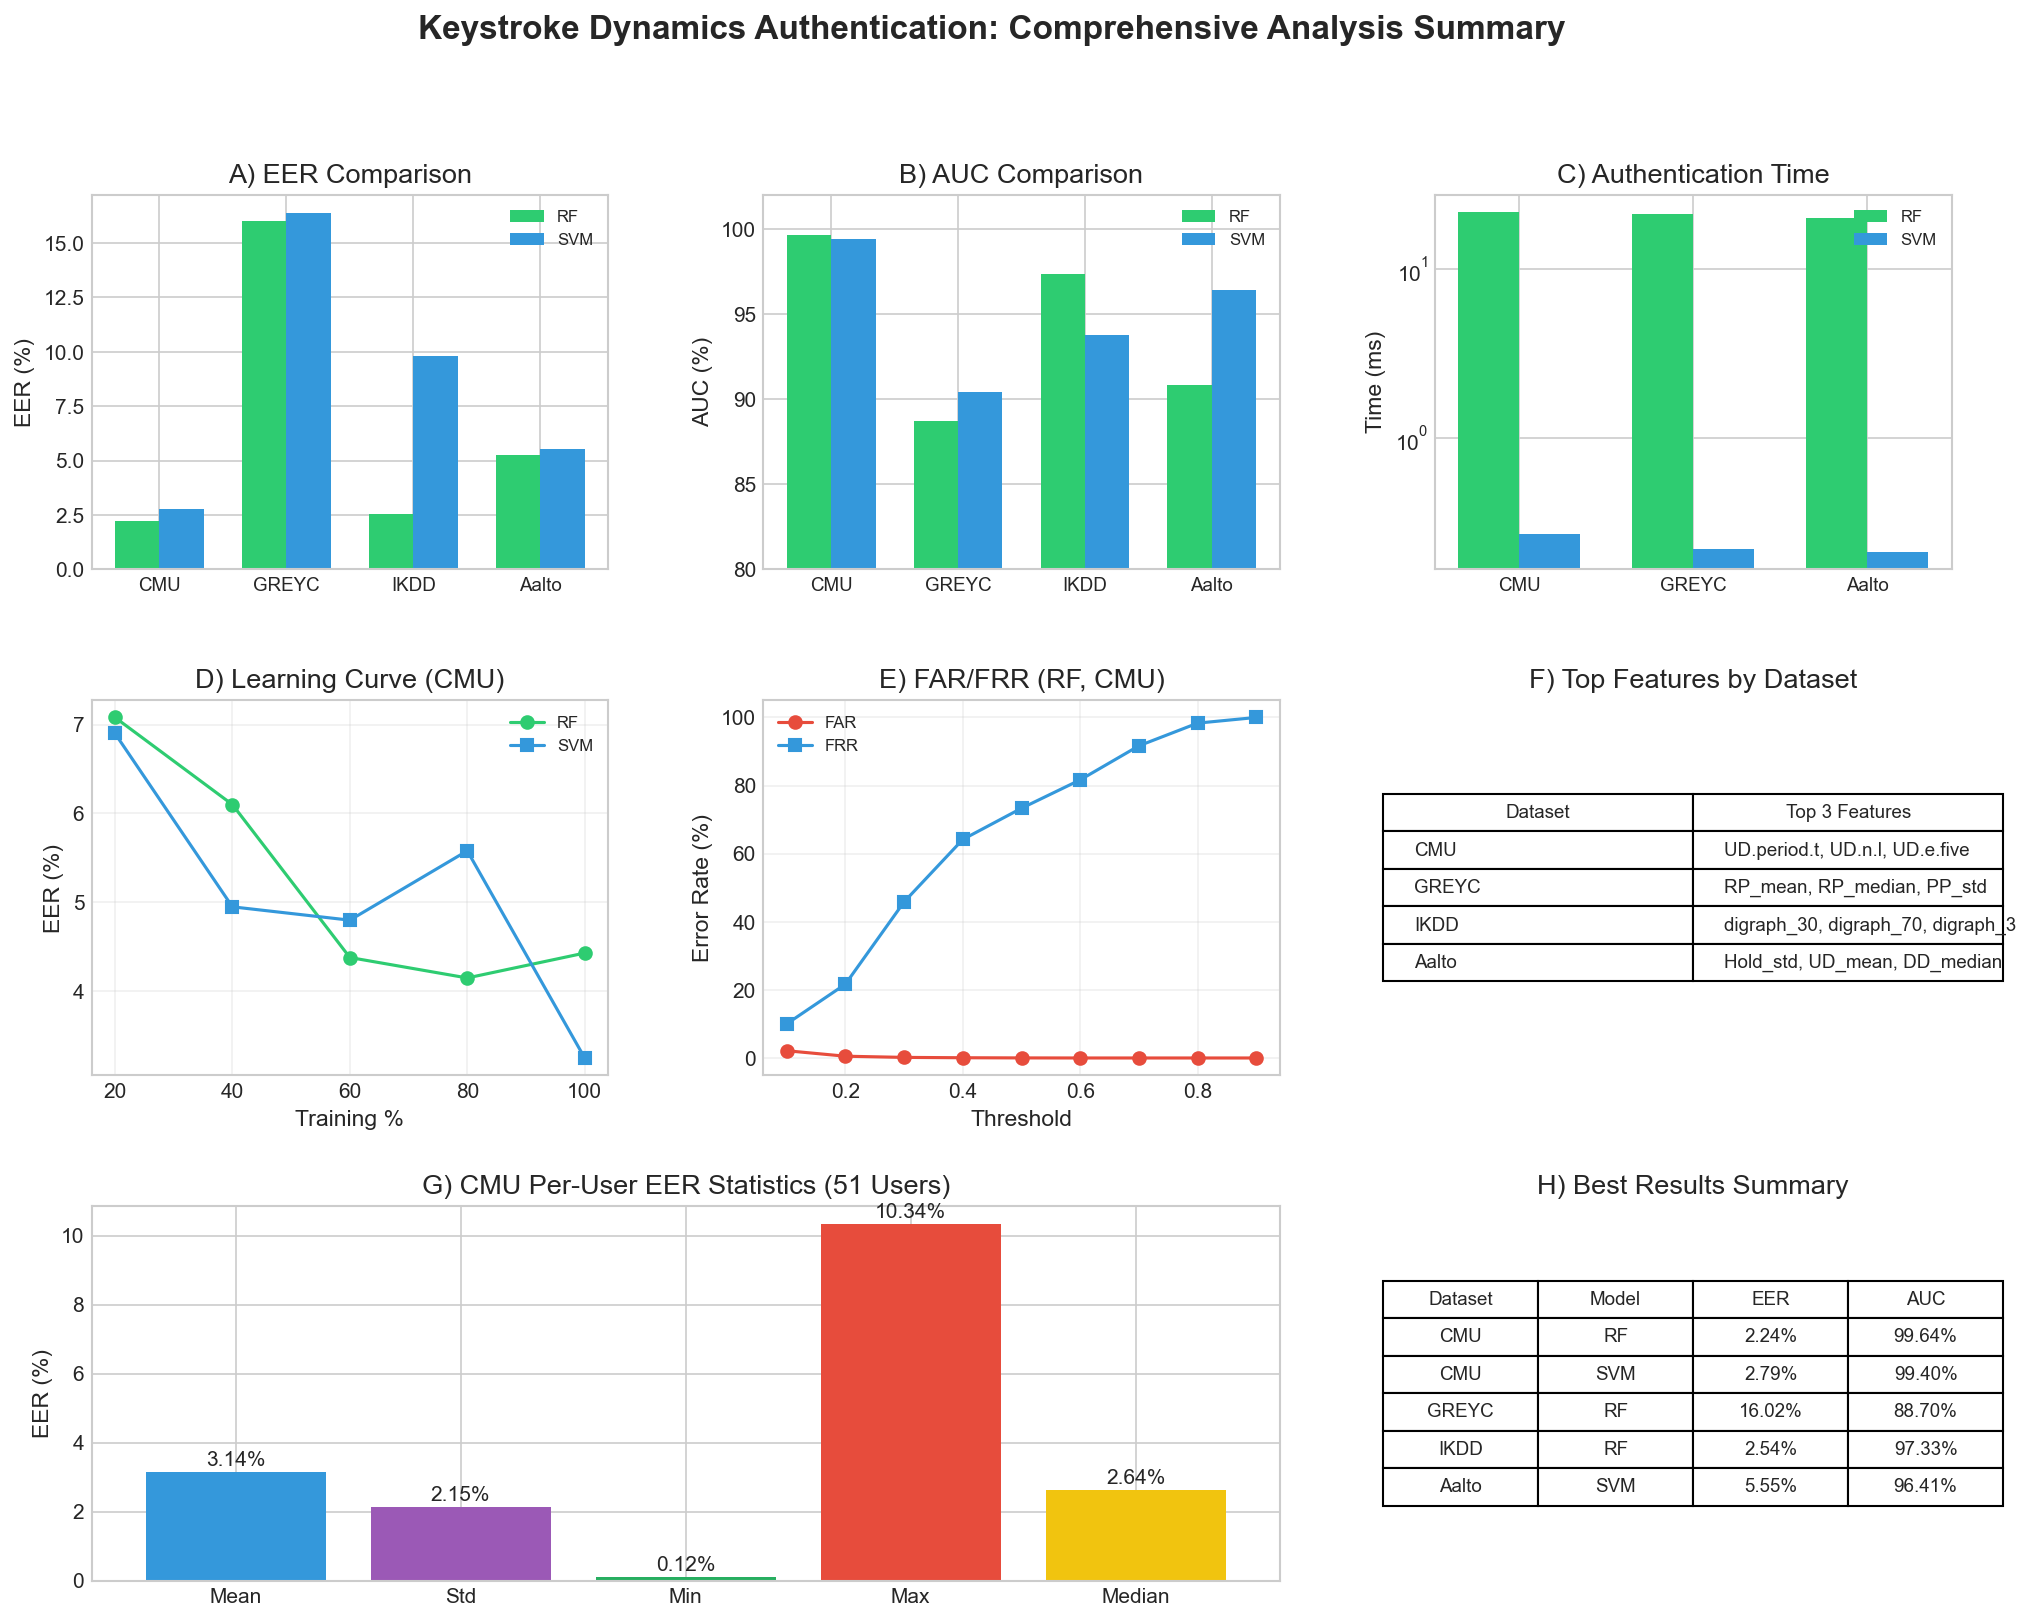

Saved: fig_7_10_comprehensive_summary.png


In [315]:
# 7.10 COMPREHENSIVE SUMMARY FIGURE
# =============================================================================

print("\n" + "=" * 60)
print("7.10 COMPREHENSIVE SUMMARY FIGURE")
print("=" * 60)

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1. EER Comparison (top left)
ax1 = fig.add_subplot(gs[0, 0])
datasets = ['CMU', 'GREYC', 'IKDD', 'Aalto']
rf_eer = [2.24, 16.02, 2.54, 5.25]
svm_eer = [2.79, 16.40, 9.82, 5.55]
x = np.arange(len(datasets))
width = 0.35
ax1.bar(x - width/2, rf_eer, width, label='RF', color=COLORS['RandomForest'])
ax1.bar(x + width/2, svm_eer, width, label='SVM', color=COLORS['SVM_RBF'])
ax1.set_ylabel('EER (%)')
ax1.set_title('A) EER Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets, fontsize=9)
ax1.legend(fontsize=8)

# 2. AUC Comparison (top middle)
ax2 = fig.add_subplot(gs[0, 1])
rf_auc = [99.64, 88.70, 97.33, 90.82]
svm_auc = [99.40, 90.42, 93.79, 96.41]
ax2.bar(x - width/2, rf_auc, width, label='RF', color=COLORS['RandomForest'])
ax2.bar(x + width/2, svm_auc, width, label='SVM', color=COLORS['SVM_RBF'])
ax2.set_ylabel('AUC (%)')
ax2.set_title('B) AUC Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets, fontsize=9)
ax2.set_ylim(80, 102)
ax2.legend(fontsize=8)

# 3. Auth Time (top right)
ax3 = fig.add_subplot(gs[0, 2])
datasets_sim = ['CMU', 'GREYC', 'Aalto']
rf_time = [21.87, 21.07, 20.15]
svm_time = [0.27, 0.22, 0.21]
x3 = np.arange(len(datasets_sim))
ax3.bar(x3 - width/2, rf_time, width, label='RF', color=COLORS['RandomForest'])
ax3.bar(x3 + width/2, svm_time, width, label='SVM', color=COLORS['SVM_RBF'])
ax3.set_ylabel('Time (ms)')
ax3.set_title('C) Authentication Time')
ax3.set_xticks(x3)
ax3.set_xticklabels(datasets_sim, fontsize=9)
ax3.set_yscale('log')
ax3.legend(fontsize=8)

# 4. CMU Learning Curve (middle left)
ax4 = fig.add_subplot(gs[1, 0])
train_pct = [20, 40, 60, 80, 100]
ax4.plot(train_pct, learning_curves['CMU']['RandomForest']['EER'], 'o-', 
         color=COLORS['RandomForest'], label='RF')
ax4.plot(train_pct, learning_curves['CMU']['SVM_RBF']['EER'], 's-', 
         color=COLORS['SVM_RBF'], label='SVM')
ax4.set_xlabel('Training %')
ax4.set_ylabel('EER (%)')
ax4.set_title('D) Learning Curve (CMU)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. FAR/FRR Trade-off - RandomForest (middle center)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(threshold_data['RandomForest']['threshold'], 
         threshold_data['RandomForest']['FAR'], 'o-', color='#e74c3c', label='FAR')
ax5.plot(threshold_data['RandomForest']['threshold'], 
         threshold_data['RandomForest']['FRR'], 's-', color='#3498db', label='FRR')
ax5.set_xlabel('Threshold')
ax5.set_ylabel('Error Rate (%)')
ax5.set_title('E) FAR/FRR (RF, CMU)')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Top 5 Features per Dataset (middle right)
ax6 = fig.add_subplot(gs[1, 2])
top_features = {
    'CMU': 'UD.period.t\nUD.n.l\nUD.e.five',
    'GREYC': 'RP_mean\nRP_median\nPP_std',
    'IKDD': 'digraph_30\ndigraph_70\ndigraph_318',
    'Aalto': 'Hold_std\nUD_mean\nDD_median'
}
ax6.axis('off')
table_data = [[ds, feats.replace('\n', ', ')] for ds, feats in top_features.items()]
table = ax6.table(cellText=table_data, colLabels=['Dataset', 'Top 3 Features'],
                  loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax6.set_title('F) Top Features by Dataset')

# 7. Per-User EER Distribution (bottom left + center)
ax7 = fig.add_subplot(gs[2, 0:2])
user_stats = {
    'Metric': ['Mean', 'Std', 'Min', 'Max', 'Median'],
    'Value (%)': [3.14, 2.15, 0.12, 10.34, 2.64]
}
x7 = np.arange(len(user_stats['Metric']))
colors7 = ['#3498db', '#9b59b6', '#27ae60', '#e74c3c', '#f1c40f']
bars7 = ax7.bar(x7, user_stats['Value (%)'], color=colors7)
ax7.set_ylabel('EER (%)')
ax7.set_title('G) CMU Per-User EER Statistics (51 Users)')
ax7.set_xticks(x7)
ax7.set_xticklabels(user_stats['Metric'])
for bar, val in zip(bars7, user_stats['Value (%)']):
    ax7.annotate(f'{val:.2f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

# 8. Summary Statistics Table (bottom right)
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
summary_data = [
    ['CMU', 'RF', '2.24%', '99.64%'],
    ['CMU', 'SVM', '2.79%', '99.40%'],
    ['GREYC', 'RF', '16.02%', '88.70%'],
    ['IKDD', 'RF', '2.54%', '97.33%'],
    ['Aalto', 'SVM', '5.55%', '96.41%']
]
table8 = ax8.table(cellText=summary_data, 
                   colLabels=['Dataset', 'Model', 'EER', 'AUC'],
                   loc='center', cellLoc='center')
table8.auto_set_font_size(False)
table8.set_fontsize(9)
table8.scale(1.2, 1.5)
ax8.set_title('H) Best Results Summary')

plt.suptitle('Keystroke Dynamics Authentication: Comprehensive Analysis Summary', 
             fontsize=16, y=0.98, fontweight='bold')
plt.savefig('fig_7_10_comprehensive_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_7_10_comprehensive_summary.png")

In [319]:
# SUMMARY

print("\n" + "=" * 60)
print("SECTION 7 COMPLETE!")
print("=" * 60)
print("\nGenerated Figures:")
print("  1. fig_7_1_cross_dataset_comparison.png   - EER/AUC bar charts")
print("  2. fig_7_2_metrics_heatmap.png            - Performance heatmaps")
print("  3. fig_7_3_split_sensitivity.png         - Train/test split analysis")
print("  4. fig_7_4_per_user_analysis.png         - User difficulty distribution")
print("  5. fig_7_5_feature_importance.png        - Top features by dataset")
print("  6. fig_7_6_learning_curves.png           - Learning curves")
print("  7. fig_7_7_threshold_analysis.png        - FAR/FRR trade-off")
print("  8. fig_7_8_auth_simulation.png           - Authentication simulation")
print("  9. fig_7_9_statistical_significance.png  - Statistical tests")
print(" 10. fig_7_10_comprehensive_summary.png    - Full summary figure")
print("\nAll figures saved at 300 DPI for publication quality.")


SECTION 7 COMPLETE!

Generated Figures:
  1. fig_7_1_cross_dataset_comparison.png   - EER/AUC bar charts
  2. fig_7_2_metrics_heatmap.png            - Performance heatmaps
  3. fig_7_3_split_sensitivity.png         - Train/test split analysis
  4. fig_7_4_per_user_analysis.png         - User difficulty distribution
  5. fig_7_5_feature_importance.png        - Top features by dataset
  6. fig_7_6_learning_curves.png           - Learning curves
  7. fig_7_7_threshold_analysis.png        - FAR/FRR trade-off
  8. fig_7_8_auth_simulation.png           - Authentication simulation
  9. fig_7_9_statistical_significance.png  - Statistical tests
 10. fig_7_10_comprehensive_summary.png    - Full summary figure

All figures saved at 300 DPI for publication quality.
